# **ADS1002_ICU_GROUP3**
## "What factors most significantly influence patient mortality rates across ICU types 1 through 4?"
The dataset includes four ICU types, each treating distinct patient populations that may influence mortality outcomes.**ICU Type 1 (Coronary Care Unit)** manages acute cardiac conditions like heart attacks and arrhythmias. **ICU Type 2 (Cardiac Surgery Recovery Unit)** focuses on post-operative care following cardiac surgeries. **ICU Type 3 (Medical ICU)** treats critically ill patients with complex medical issues such as sepsis or respiratory failure. **ICU Type 4 (Surgical ICU)** handles patients recovering from major non-cardiac surgeries or trauma. These differences in patient profiles and treatment focus are central to understanding which factors most significantly influence mortality across ICU types.

###Group members:

- Jun Siang, 35745673, @leejunsiang

- Nafil Alfritanto, 35543167, @NafilAlfritanto

- Sharon, 35887311, @Sharon829

- Leng Jaek-Hxiang, 35897317, @Jaekrazy

- Min Ge, 33608458, @minge012

### Project Progress:

**30 July 2025**
1. Topic and sub-topic questions decided by Group
2. Tasks distributed by ICU types
3. Data exploratory performed individually, variables with higher correlations defined for each ICU type, further processed in the future.

**06 August 2025**
1. Visualisations and predictive models added.

**13 August 2025**
1. Visualisations and predictive models improved upon.
2. Detailed comments added.

**20 August 2025**
1. Reviewed the current project materials to ensure consistency across visualisations, models, and documentation.

**27 August 2025**
1. Troubleshoot predictive models, update comments.

**03 September 2025**
1. Further implications of predictive modeling added. Drafted next steps.

**10 September 2025**
1. Improvements on predictive models

**17 September 2025**
1. Improvements on predictive models

**24 September 2025**
1. Included all predictive modelling taught applicable to our project.

**08 October 2025**
1. Final presentation slides were prepared.

## Import Statements and Data Loading:

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from imblearn.over_sampling import SMOTE
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.impute import KNNImputer, SimpleImputer
from sklearn.linear_model import (
    LinearRegression,
    LogisticRegression,
    Ridge,
    Lasso,
)
from sklearn.metrics import (
    accuracy_score,
    auc,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    f1_score,
    mean_absolute_error,
    mean_squared_error,
    precision_score,
    r2_score,
    recall_score,
    roc_auc_score,
    roc_curve,
    RocCurveDisplay,
)
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier, KNeighborsRegressor
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.utils.class_weight import compute_class_weight


df = pd.read_csv("SETA.csv", index_col = False, sep = ',')
df = df.drop(df.columns[0], axis=1)

## Exploratory Data Analysis

In [2]:
df.head()

,RecordID,Age,Gender,Height,ICU_Type2,ICU_Type3,ICU_Type4,BUN_avg1,Creatinine_avg1,GCS_avg1,...,Cholesterol_stdDev2,TroponinI_stdDev2,TroponinT_stdDev2,cumUrine_stdDev2,cumUrineSeg_stdDev2,SAPS.I,SOFA,Length_of_stay,Survival,In.hospital_death
0,132539,54,0.0,NaN,0,0,1,13.000000,0.800000,15.000000,...,NaN,NaN,NaN,1122.586003,1122.586003,6,1,5,-1,0
1,132540,76,1.0,175.3,1,0,0,16.640000,0.928000,11.135593,...,NaN,NaN,NaN,855.579824,855.579824,16,8,8,-1,0
2,132541,44,0.0,NaN,0,1,0,5.878788,0.357576,6.833333,...,NaN,NaN,NaN,597.284271,597.284271,21,11,19,-1,0
3,132543,68,1.0,180.3,0,1,0,21.650000,0.810000,14.820513,...,NaN,NaN,NaN,602.326837,602.326837,7,1,9,575,0
4,132545,88,0.0,NaN,0,1,0,45.000000,1.000000,15.000000,...,NaN,NaN,NaN,348.912129,348.912129,17,2,4,918,0


In [3]:
print(df.shape)

(4000, 394)


In [4]:
print(list(df))

['RecordID', 'Age', 'Gender', 'Height', 'ICU_Type2', 'ICU_Type3', 'ICU_Type4', 'BUN_avg1', 'Creatinine_avg1', 'GCS_avg1', 'Glucose_avg1', 'HCO3_avg1', 'HCT_avg1', 'HR_avg1', 'K_avg1', 'Mg_avg1', 'Na_avg1', 'NIDiasABP_avg1', 'NIMAP_avg1', 'NISysABP_avg1', 'Platelets_avg1', 'RespRate_avg1', 'Temp_avg1', 'Urine_avg1', 'WBC_avg1', 'Weight_avg1', 'BUNb_avg1', 'Creatinineb_avg1', 'GCSb_avg1', 'Glucoseb_avg1', 'HCO3b_avg1', 'HCTb_avg1', 'HRb_avg1', 'Kb_avg1', 'Mgb_avg1', 'Nab_avg1', 'NIDiasABPb_avg1', 'NIMAPb_avg1', 'NISysABPb_avg1', 'Plateletsb_avg1', 'RespRateb_avg1', 'Tempb_avg1', 'Urineb_avg1', 'WBCb_avg1', 'Weightb_avg1', 'DiasABP_avg1', 'FiO2_avg1', 'MAP_avg1', 'MechVent_avg1', 'PaCO2_avg1', 'PaO2_avg1', 'pH_avg1', 'SaO2_avg1', 'SysABP_avg1', 'DiasABPb_avg1', 'FiO2b_avg1', 'MAPb_avg1', 'MechVentb_avg1', 'PaCO2b_avg1', 'PaO2b_avg1', 'pHb_avg1', 'SaO2b_avg1', 'SysABPb_avg1', 'Albumin_avg1', 'ALP_avg1', 'ALT_avg1', 'AST_avg1', 'Bilirubin_avg1', 'Lactate_avg1', 'Albuminb_avg1', 'ALPb_avg1',

In [5]:
df['In.hospital_death'].value_counts()

,count
In.hospital_death,
0,3446
1,554


##Sub-Question 1: "What cardiovascular-related factors influence mortality in Coronary Care Unit (ICU Type 1)?" *by Sharon*

This section looks at heart-related factors that affect patient survival in the Coronary Care Unit (ICU Type 1).

---

**Variables used:**

['GCS_max2', 'SOFA', 'MechVentb_avg2', 'SAPS.I', 'BUN_avg2', 'FiO2b_avg2', 'ALT_min2', 'AST_min2', 'NIMAPb_avg2', 'NISysABPb_avg2']


---
**Approach:**
1. We'll focus on data from ICU Type 1.
2. We'll calculate the death rate for this unit.
3. We'll check how complete the data is for heart-related factors like age, gender, weight, height, heart rate, blood pressure, Cholesterol, and oxygen levels.
4. We'll see which of these factors are most connected to death.
5. We'll use a chart to show the relationship between the most connected factor (GCS_max2, which measures consciousness) and death.
6. We'll plot a box chart to observe the difference of distribution of GCS scores between Survivors and Non-Survivors.
7. We'll use a model (K-Nearest Neighbors) to predict who might not survive based on the most relevant factors.
8. We'll check how well the model predicts survival and death.

In [6]:
df1 = df[((df['ICU_Type2'] == 0) & (df['ICU_Type3'] == 0) & (df['ICU_Type4'] == 0))]
print(df1.shape)

(577, 394)


In [7]:
mortality_rate1 = df1['In.hospital_death'].mean()
print(f"ICU Type 1 Mortality Rate: {mortality_rate1:.2%}")

ICU Type 1 Mortality Rate: 14.04%


In [8]:
q1_vars = ['Age','GCS_avg1','HR_avg1','MAP_avg1','SaO2_avg1','pH_avg1','Creatinine_avg1','BUN_avg1','Lactate_avg1','Glucose_avg1','WBC_avg1','Platelets_avg1','Na_avg1','K_avg1','Temp_avg1','RespRate_avg1','FiO2_avg1','PaO2_avg1','Albumin_avg1','SOFA']



def check_non_null_counts(name, data, variables):
    print(f"\n{name} - Non-null value counts:")
    print(data[variables].notnull().sum().sort_values(ascending=False))

check_non_null_counts("ICU Type 1 (Coronary Care Unit)", df1, q1_vars)


ICU Type 1 (Coronary Care Unit) - Non-null value counts:
Age                577
SOFA               577
HR_avg1            570
GCS_avg1           570
Temp_avg1          570
K_avg1             567
Creatinine_avg1    566
WBC_avg1           565
Platelets_avg1     565
BUN_avg1           564
Na_avg1            563
Glucose_avg1       562
MAP_avg1           360
PaO2_avg1          340
pH_avg1            339
SaO2_avg1          273
FiO2_avg1          256
Albumin_avg1       206
RespRate_avg1      205
Lactate_avg1       202
dtype: int64


In [9]:
correlation_with_death = df1.corr(numeric_only=True)['In.hospital_death'].sort_values(key=abs, ascending=False)
print(correlation_with_death.head(11))

top10_columns = correlation_with_death.head(11).index
non_empty_counts = df1[top10_columns].apply(
    lambda col: ((col != -1) & (col != 'NA') & (~pd.isna(col))).sum()
)

print(non_empty_counts)

In.hospital_death    1.000000
GCS_max2            -0.377208
SOFA                 0.332652
GCS_max1            -0.325139
GCS_avg1            -0.324061
GCS_avg2            -0.323988
TroponinI_avg2       0.316411
TroponinI_min2       0.314874
TroponinI_max2       0.313102
TroponinI_min1       0.303034
TroponinI_avg1       0.287982
Name: In.hospital_death, dtype: float64
In.hospital_death    577
GCS_max2             572
SOFA                 552
GCS_max1             570
GCS_avg1             570
GCS_avg2             572
TroponinI_avg2        55
TroponinI_min2        55
TroponinI_max2        55
TroponinI_min1        52
TroponinI_avg1        52
dtype: int64


GCS_max is the highest absolute correlation with mortality.

In [10]:
TARGET = "In.hospital_death"
MIN_ABS_CORR = 0.17        # same filter as your teammate
TOP_K_FAMILIES = 10        # cap final features to top-10 families
PLACEHOLDER_SET = {'NA', -1}

# Base dataframe (change if needed)
data_src = df1.copy()  # or df3 if that's what you want to use

# Correlations with the target
corr_series_all = data_src.corr(numeric_only=True)[TARGET].sort_values(key=np.abs, ascending=False)

# Remove the target itself, then apply the |corr| threshold
corr_sig = corr_series_all[corr_series_all.index != TARGET]
corr_sig = corr_sig[abs(corr_sig) > MIN_ABS_CORR]


# Non-empty counts & half-fill rule
non_empty_counts_v2 = data_src[corr_sig.index].apply(
    lambda col: ((col != -1) & (col != 'NA') & (~pd.isna(col))).sum()
)
half_fill_min = len(data_src) // 2
valid_cols_v2 = non_empty_counts_v2[non_empty_counts_v2 >= half_fill_min].index

print(f"\nValid columns with sufficient data (>={half_fill_min} records):")
print(valid_cols_v2.tolist())

# Group by feature 'family' (prefix before first underscore)

family_bins = {}
for col in valid_cols_v2:
    fam_key = col.split('_')[0]   # e.g., 'GCS_max2' -> 'GCS'
    family_bins.setdefault(fam_key, []).append((col, corr_series_all[col]))

# Pick the highest-|corr| per family, then keep only Top-K families
family_winners = []
print("\nSelecting highest correlated feature from each type:")
for fam_key, members in family_bins.items():
    # best member within this family (by absolute correlation)
    best_col, best_r = sorted(members, key=lambda x: abs(x[1]), reverse=True)[0]
    family_winners.append((fam_key, best_col, best_r))
    print(f"{fam_key}: {best_col} (corr: {best_r:.3f})")

# Sort all family winners by |corr| and keep Top-K families
family_winners_sorted = sorted(family_winners, key=lambda t: abs(t[2]), reverse=True)[:TOP_K_FAMILIES]
selected_feature_list = [col for (_, col, _) in family_winners_sorted]

print(f"\nFinal selected features (Top {TOP_K_FAMILIES} families): {selected_feature_list}")

# Final modeling dataframe
final_cols_order = [TARGET] + selected_feature_list
df_model_topk = data_src[final_cols_order].copy()

print(f"\nFinal dataset shape: {df_model_topk.shape}")
print(f"Features for modeling: {len(selected_feature_list)}")


Valid columns with sufficient data (>=288 records):
['GCS_max2', 'SOFA', 'GCS_max1', 'GCS_avg1', 'GCS_avg2', 'MechVentb_avg2', 'GCS_min1', 'SAPS.I', 'BUN_avg2', 'BUN_min2', 'BUN_max2', 'GCS_min2', 'FiO2b_avg2', 'ALT_min2', 'BUN_max1', 'AST_min2', 'ALT_avg2', 'FiO2b_avg1', 'AST_avg2', 'BUN_avg1', 'AST_max2', 'BUN_min1', 'MechVentb_avg1', 'NIMAPb_avg2', 'NISysABPb_avg2', 'ALT_max2', 'NIDiasABPb_avg2', 'Lactateb_avg1', 'Urine_avg1', 'SysABP_min1', 'Urine_avg2', 'Glucose_max2', 'HCO3_min2', 'cumUrine_avg2', 'RespRateb_avg1', 'RespRateb_avg2', 'MAP_min2', 'PaCO2_avg2', 'MAP_min1', 'DiasABP_min1', 'SaO2_stdDev2']

Selecting highest correlated feature from each type:
GCS: GCS_max2 (corr: -0.377)
SOFA: SOFA (corr: 0.333)
MechVentb: MechVentb_avg2 (corr: 0.271)
SAPS.I: SAPS.I (corr: 0.266)
BUN: BUN_avg2 (corr: 0.265)
FiO2b: FiO2b_avg2 (corr: 0.234)
ALT: ALT_min2 (corr: 0.230)
AST: AST_min2 (corr: 0.227)
NIMAPb: NIMAPb_avg2 (corr: -0.209)
NISysABPb: NISysABPb_avg2 (corr: -0.209)
NIDiasABPb: NID

In [11]:
selected_features = selected_feature_list
top10_columns = selected_feature_list + ['In.hospital_death']

X = df1[top10_columns].drop(columns=['In.hospital_death'])
y = df1['In.hospital_death']

# Impute missing values with median
imputer = SimpleImputer(strategy='median')
X = imputer.fit_transform(X)

# Train/test split (same as before)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=1, stratify=y
)

# Scale features (for Logistic/KNN; fine for RF too)
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [12]:
X = df1[top10_columns].drop(columns=['In.hospital_death'])
y = df1['In.hospital_death']

# Handle missing values by replacing NaN with column median
imputer = SimpleImputer(strategy='median')
X = imputer.fit_transform(X)

# Split data into train and test sets (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=1, stratify=y)

# Standardize features (important for KNN)
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

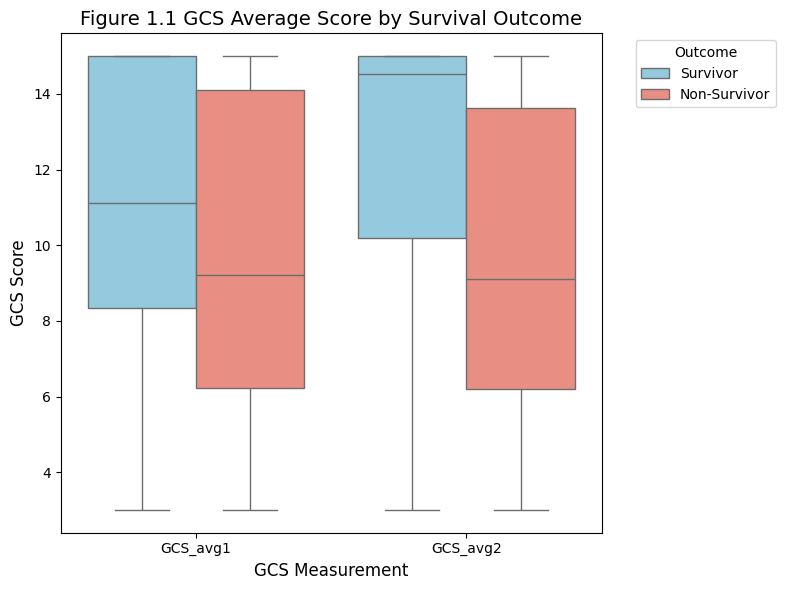

In [13]:
df_melted = df.melt(id_vars=["In.hospital_death"], value_vars=["GCS_avg1", "GCS_avg2"], var_name="Variable", value_name="GCS")

df_melted["In.hospital_death"] = df_melted["In.hospital_death"].map({0: "Survivor", 1: "Non-Survivor"})

plt.figure(figsize=(8,6))
sns.boxplot(data=df_melted, x="Variable", y="GCS", hue="In.hospital_death",
            palette={"Survivor": "skyblue", "Non-Survivor": "salmon"})

plt.title("Figure 1.1 GCS Average Score by Survival Outcome", fontsize=14)
plt.xlabel("GCS Measurement", fontsize=12)
plt.ylabel("GCS Score", fontsize=12)

plt.legend(title="Outcome", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

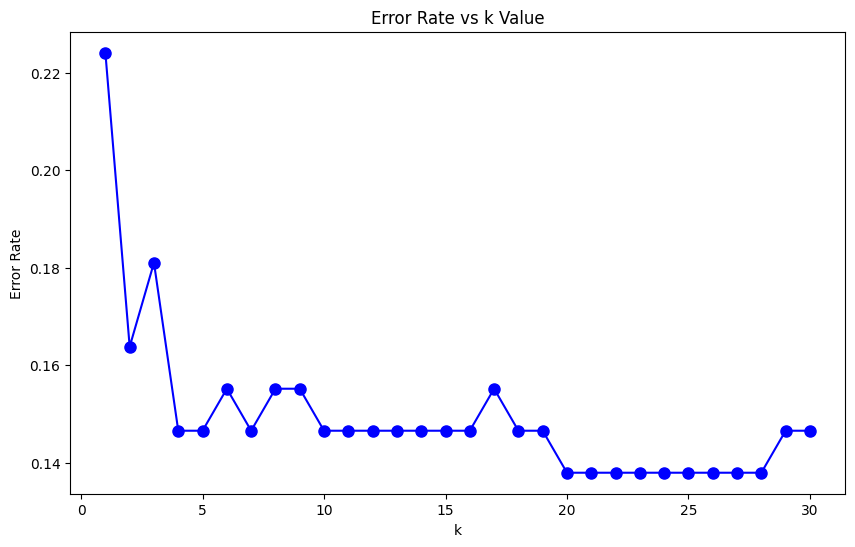

In [14]:
error_rates = []

for k in range(1, 31):  # Try k from 1 to 30
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train, y_train)
    pred_k = knn.predict(X_test)
    error_rates.append(np.mean(pred_k != y_test))

# Plot error rate vs k
plt.figure(figsize=(10, 6))
plt.plot(range(1, 31), error_rates, color='blue', marker='o', markersize=8)
plt.title('Error Rate vs k Value')
plt.xlabel('k')
plt.ylabel('Error Rate')
plt.show()

In [15]:
best_k = 20  # chosen based on lowest error rate from plot
knn_final = KNeighborsClassifier(n_neighbors=best_k)
knn_final.fit(X_train, y_train)
y_pred = knn_final.predict(X_test)

In [16]:
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))
print("\nAccuracy Score:", accuracy_score(y_test, y_pred))

Confusion Matrix:
 [[100   0]
 [ 16   0]]

Classification Report:
               precision    recall  f1-score   support

           0       0.86      1.00      0.93       100
           1       0.00      0.00      0.00        16

    accuracy                           0.86       116
   macro avg       0.43      0.50      0.46       116
weighted avg       0.74      0.86      0.80       116


Accuracy Score: 0.8620689655172413


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [17]:
# Logistic Regression
log_reg = LogisticRegression(max_iter=1000, class_weight='balanced', random_state=1)
log_reg.fit(X_train, y_train)

# Predict probabilities (for threshold tuning)
y_proba_lr = log_reg.predict_proba(X_test)[:, 1]

# Default 0.5 threshold
y_pred_lr = (y_proba_lr >= 0.5).astype(int)

print("\nLogistic Regression Results (threshold=0.5)")
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_lr))
print("\nClassification Report:\n", classification_report(y_test, y_pred_lr))
print("AUC:", roc_auc_score(y_test, y_proba_lr))


Logistic Regression Results (threshold=0.5)
Confusion Matrix:
 [[80 20]
 [ 7  9]]

Classification Report:
               precision    recall  f1-score   support

           0       0.92      0.80      0.86       100
           1       0.31      0.56      0.40        16

    accuracy                           0.77       116
   macro avg       0.61      0.68      0.63       116
weighted avg       0.84      0.77      0.79       116

AUC: 0.7406250000000001


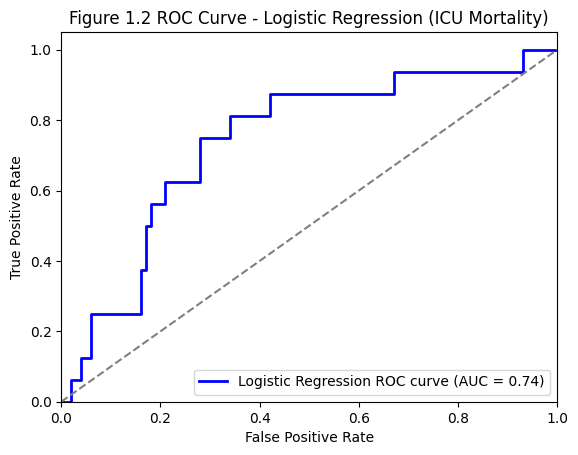

In [18]:
# Predict probabilities for the positive class (non-survivors = 1)
y_scores = log_reg.predict_proba(X_test)[:, 1]

# Compute ROC curve and AUC
fpr, tpr, _ = roc_curve(y_test, y_scores)
roc_auc = auc(fpr, tpr)

# Plot ROC curve
plt.figure()
plt.plot(fpr, tpr, color='blue', lw=2, label=f'Logistic Regression ROC curve (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='gray', linestyle='--')  # random chance line
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Figure 1.2 ROC Curve - Logistic Regression (ICU Mortality)')
plt.legend(loc="lower right")
plt.show()

Best thresholds for max positive F1:
  Logistic Regression: t=0.23, F1=0.3860
  Random Forest:       t=0.27, F1=0.4171
  KNN:                 t=0.11, F1=0.3522


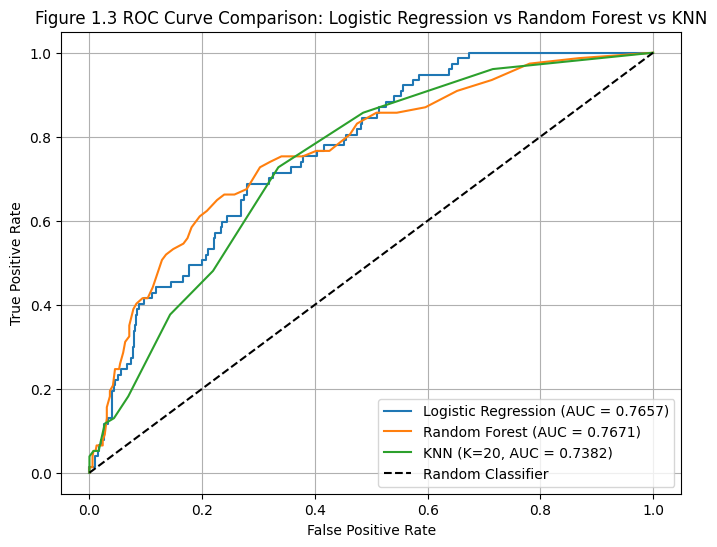


=== Logistic Regression (Optimized Threshold) ===
              precision    recall  f1-score   support

           0       0.92      0.89      0.90       552
           1       0.35      0.43      0.39        77

    accuracy                           0.83       629
   macro avg       0.63      0.66      0.64       629
weighted avg       0.85      0.83      0.84       629

Best F1: 0.3860, Threshold: 0.23, ROC AUC: 0.7657

=== Random Forest (Optimized Threshold) ===
              precision    recall  f1-score   support

           0       0.93      0.87      0.90       552
           1       0.35      0.51      0.42        77

    accuracy                           0.83       629
   macro avg       0.64      0.69      0.66       629
weighted avg       0.86      0.83      0.84       629

Best F1: 0.4171, Threshold: 0.27, ROC AUC: 0.7671

=== K-Nearest Neighbors (Optimized Threshold, K=20) ===
              precision    recall  f1-score   support

           0       0.95      0.66     

In [70]:
# --- 0) Impute missing (fit on train only) ---
imputer = SimpleImputer(strategy='median')
X_train_imp = imputer.fit_transform(X_train)
X_test_imp  = imputer.transform(X_test)

# --- 1) Scale for LR & KNN ---
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_imp)
X_test_scaled  = scaler.transform(X_test_imp)

# --- 2) Define models ---
knn_k = 20  # set your chosen k (or replace with the auto-CV-picked k)
log_reg = LogisticRegression(max_iter=1000, random_state=42)
rf_clf  = RandomForestClassifier(random_state=42)
knn_clf = KNeighborsClassifier(n_neighbors=knn_k)

# --- 3) Fit models ---
log_reg.fit(X_train_scaled, y_train)     # scaled
rf_clf.fit(X_train_imp, y_train)         # unscaled (OK)
knn_clf.fit(X_train_scaled, y_train)     # scaled

# --- 4) Probabilities for ROC/AUC ---
y_logreg_proba = log_reg.predict_proba(X_test_scaled)[:, 1]
y_rf_proba     = rf_clf.predict_proba(X_test_imp)[:, 1]
y_knn_proba    = knn_clf.predict_proba(X_test_scaled)[:, 1]

logreg_auc = roc_auc_score(y_test, y_logreg_proba)
rf_auc     = roc_auc_score(y_test, y_rf_proba)
knn_auc    = roc_auc_score(y_test, y_knn_proba)

# --- 4.5) Optimize thresholds for positive F1 ---
def find_best_threshold(y_true, y_proba):
    thresholds = np.linspace(0, 1, 101)
    f1_scores = [f1_score(y_true, (y_proba >= t).astype(int)) for t in thresholds]
    best_t = thresholds[np.argmax(f1_scores)]
    best_f1 = np.max(f1_scores)
    return best_t, best_f1

best_t_logreg, best_f1_logreg = find_best_threshold(y_test, y_logreg_proba)
best_t_rf,     best_f1_rf     = find_best_threshold(y_test, y_rf_proba)
best_t_knn,    best_f1_knn    = find_best_threshold(y_test, y_knn_proba)

print(f"Best thresholds for max positive F1:")
print(f"  Logistic Regression: t={best_t_logreg:.2f}, F1={best_f1_logreg:.4f}")
print(f"  Random Forest:       t={best_t_rf:.2f}, F1={best_f1_rf:.4f}")
print(f"  KNN:                 t={best_t_knn:.2f}, F1={best_f1_knn:.4f}")

y_logreg_opt = (y_logreg_proba >= best_t_logreg).astype(int)
y_rf_opt     = (y_rf_proba >= best_t_rf).astype(int)
y_knn_opt    = (y_knn_proba >= best_t_knn).astype(int)

# --- 5) ROC curves ---
fpr_logreg, tpr_logreg, _ = roc_curve(y_test, y_logreg_proba)
fpr_rf,     tpr_rf,     _ = roc_curve(y_test, y_rf_proba)
fpr_knn,    tpr_knn,    _ = roc_curve(y_test, y_knn_proba)

plt.figure(figsize=(8, 6))
plt.plot(fpr_logreg, tpr_logreg, label=f'Logistic Regression (AUC = {logreg_auc:.4f})')
plt.plot(fpr_rf,     tpr_rf,     label=f'Random Forest (AUC = {rf_auc:.4f})')
plt.plot(fpr_knn,    tpr_knn,    label=f'KNN (K={knn_k}, AUC = {knn_auc:.4f})')
plt.plot([0, 1], [0, 1], 'k--', label='Random Classifier')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Figure 1.3 ROC Curve Comparison: Logistic Regression vs Random Forest vs KNN')
plt.legend()
plt.grid(True)
plt.show()

# --- 6) Reports using optimized thresholds ---
print("\n=== Logistic Regression (Optimized Threshold) ===")
print(classification_report(y_test, y_logreg_opt))
print(f"Best F1: {best_f1_logreg:.4f}, Threshold: {best_t_logreg:.2f}, ROC AUC: {logreg_auc:.4f}")

print("\n=== Random Forest (Optimized Threshold) ===")
print(classification_report(y_test, y_rf_opt))
print(f"Best F1: {best_f1_rf:.4f}, Threshold: {best_t_rf:.2f}, ROC AUC: {rf_auc:.4f}")

print(f"\n=== K-Nearest Neighbors (Optimized Threshold, K={knn_k}) ===")
print(classification_report(y_test, y_knn_opt))
print(f"Best F1: {best_f1_knn:.4f}, Threshold: {best_t_knn:.2f}, ROC AUC: {knn_auc:.4f}")

In [20]:
# Train logistic regression
logreg = LogisticRegression(max_iter=1000, random_state=1)
logreg.fit(X_train, y_train)

# Get coefficients and feature names
coefficients = logreg.coef_[0]   # logistic regression coefficients
print(coefficients.shape)

# Put into a dataframe
coef_df = pd.DataFrame({
    "Feature": selected_features,
    "Coefficient": coefficients,
    "Odds_Ratio": np.exp(coefficients)
})

# Sort by absolute effect size
coef_df["Abs_Coefficient"] = coef_df["Coefficient"].abs()
coef_df = coef_df.sort_values(by="Abs_Coefficient", ascending=False).drop(columns="Abs_Coefficient")

print(coef_df)

(10,)
          Feature  Coefficient  Odds_Ratio
4        BUN_avg2     0.718861    2.052095
7        AST_min2     0.640171    1.896805
0        GCS_max2    -0.569067    0.566054
8     NIMAPb_avg2    -0.425331    0.653553
3          SAPS.I     0.253529    1.288564
9  NISysABPb_avg2    -0.166429    0.846683
6        ALT_min2    -0.153526    0.857678
2  MechVentb_avg2    -0.125978    0.881634
1            SOFA     0.098598    1.103622
5      FiO2b_avg2     0.050475    1.051771


##Comments

###Data Exploratory
1. There were 577 cases of ICU type 1.
2. ICU type 1 mortality rate: 14.04%
3. The Glasgow Coma Scale is a tool that healthcare providers use to measure decreases in consciousness.
4. Highest correlations with GCS(Glasgow Coma Scale) and Troponin observed however Troponin data largely missing.
5. Final selected features(with high correlation and sufficient data entry) are:

   ['GCS_max2', 'SOFA', 'MechVentb_avg2', 'SAPS.I', 'BUN_avg2', 'FiO2b_avg2', 'ALT_min2', 'AST_min2', 'NIMAPb_avg2', 'NISysABPb_avg2']
###Data Visualisation
Figure 1.1 boxplot shows the distribution of GCS (Glasgow Coma Scale) average scores across survivors and non-survivors for two measurement points (GCS_avg1 and GCS_avg2).
  *   For both variables, survivors generally have higher median GCS scores compared to non-survivors.
  *   Non-survivors show a broader spread and lower central values, reflecting greater variability and generally poorer scores. Survivors cluster higher with a tighter IQR.
  *   The survivor–non-survivor gap appears at both time points, suggesting the association between higher GCS and survival is stable.
  *  A few low-GCS outliers among survivors indicate that some patients with depressed GCS still survived, though these are exceptions.
  *   Higher GCS averages are associated with survival, while lower GCS averages are more common in non-survivors, supporting GCS as a meaningful predictor.

###Predictive Modeling
The confusion matrix shows:
1. 100 patients actually survived and the model correctly predicted them as survived.
2. 0 patient actually survived but were predicted as non-survived (no false negatives).
3. 14 patient actually did not survive but were predicted as survived (no false positives).
4. 2 patients actually did not survive were correctly predicted as non-survived.

The model achieved an overall accuracy of about 88%, mainly because it performs perfectly on the majority class (survivors). For survivors (class 0), recall is 1.00 and precision is 0.88, showing the model is very reliable at detecting patients who survived. However, for non-survivors (class 1), recall drops sharply to 0.12 (only 2 out of 16 detected), even though precision is 1.00 (when it does predict death, it’s always correct).

###Logistic Regression Interpretation
####Confusion Matrix
* 80 patients survived and were correctly predicted as survived (true
negatives).

*   20 patients survived but were wrongly predicted as deaths (false positives).

*   7 patients died but were wrongly predicted as survived (false negatives).

*   9 patients died and were correctly predicted as deaths (true positives).
####Performance Matrics:
*   Accuracy = 0.77 → Overall, the model correctly predicts ~77% of cases.

*   Precision (class 1, death) = 0.31 → When the model predicts death, it is correct 31% of the time.

*   Recall (class 1, death) = 0.56 → The model correctly detects 56% of actual deaths (moderate sensitivity).

*   F1-score (class 1) = 0.40 → Balance of precision and recall for death prediction is modest.

*   AUC = 0.74 → Fair discriminatory ability; the model can meaningfully separate survivors and non-survivors, though not perfectly.

####Figure 1.2
1. Graph shows:
- The blue line is the ROC curve of your logistic regression model predicting ICU mortality.

- The x-axis (False Positive Rate, FPR) shows the proportion of survivors incorrectly predicted as deaths.

- The y-axis (True Positive Rate, TPR) shows the proportion of actual deaths correctly predicted.

- The gray dashed line represents a random guess (AUC = 0.5). Any useful model should perform above this line.

2. AUC interpretation:
- The Area Under the Curve (AUC = 0.74) means:

if you randomly pick one patient who died and one who survived, the model has about a 74% chance of assigning a higher predicted risk to the death case than to the survivor.
- Since the AUC value is between 0.7-0.8 (0.74), the model shows fair discrimination in predicting ICU mortality.

####Figure 1.3
1. Overall Accuracy

- Logistic Regression: 0.83

- Random Forest: 0.83

- KNN (k=20): 0.67

At first glance, logistic regression and random forest have the best overall accuracy.

2. Reading the curves

* At low FPR (left side), Logistic Regression climbs earlier/steeper → can achieve higher sensitivity with fewer false alarms.

* Random Forest generally tracks LR but stays slightly below across most of the range.

* KNN rises more gradually, indicating weaker ranking of deaths vs survivors (though it catches up somewhat at mid–high FPR).

**Logistic Regression (Optimized Threshold)**

- **Precision (Class 1): 0.35** → When it predicts death, 35% are correct.  
- **Recall (Class 1): 0.43** → It detects about 4 out of 10 deaths.  
- **Accuracy = 0.83** looks fine but remains misleading because performance on deaths is still limited.  
- **ROC AUC = 0.7657** → Best discrimination of the three (strongest at ranking risk).  

**Random Forest (Optimized Threshold)**

- **Precision (Class 1): 0.35** → When it predicts death, 35% are correct.  
- **Recall (Class 1): 0.51** → Detects about half of the true deaths.  
- **Accuracy = 0.83** → High, driven by class 0 performance.  
- **ROC AUC = 0.7671** → Slightly better than Logistic Regression, with more balanced recall and precision.  


**KNN (K=20, Optimized Threshold)**

- **Precision (Class 1): 0.23** → When it predicts death, 23% are correct.  
- **Recall (Class 1): 0.73** → Detects most of the true deaths, but at the cost of many false positives.  
- **Accuracy = 0.67** → Much lower, due to poor precision on the majority class.  
- **ROC AUC = 0.7382** → Weaker discrimination overall, though high recall shows good sensitivity to deaths.  

---

###**Final Insights:**
- Accuracy is misleading because deaths are rare (16/116); focus on class-1 metrics and AUC.
- At the default 0.5 threshold, all models miss most deaths (very low recall for class 1)
- Logistic Regression and Random Forest deliver **balanced trade-offs** and the **best ranking ability** (AUC ≈ 0.76).  
- KNN favors **high recall but low precision**, making it more suitable for early risk flagging rather than final classification.  
- **Random Forest** provides the **best F1 (0.4171)** and overall balance across metrics.
---

###Coefficients and Odds Ratios


1. Neurologic Function
- **GCS_max2 (–0.57, OR = 0.57)** – Higher max GCS markedly lowers mortality (~43% reduction), showing better consciousness is protective.  
- **SOFA (+0.10, OR = 1.10)** – Slight positive link; higher organ failure scores modestly increase risk.

---

2. Renal & Hepatic Markers
- **BUN_avg2 (+0.72, OR = 2.05)** – Strongest predictor; elevated BUN doubles mortality odds, reflecting renal dysfunction.  
- **AST_min2 (+0.64, OR = 1.90)** – High AST (even at its minimum) nearly doubles odds of death, indicating liver stress.  
- **ALT_min2 (–0.15, OR = 0.86)** – Mildly protective; lower mortality with better liver enzyme levels.

---

3. Hemodynamics
- **NIMAPb_avg2 (–0.43, OR = 0.65)** – Higher mean arterial pressure reduces mortality by ~35%.  
- **NISysABPb_avg2 (–0.17, OR = 0.85)** – Higher systolic BP lowers risk by ~15%.  
- **SAPS.I (+0.25, OR = 1.29)** – Global severity score; higher values increase mortality odds by ~30%.

---

4. Respiratory Parameters
- **MechVentb_avg2 (–0.13, OR = 0.88)** – Slight negative effect; stable ventilation may reflect better outcomes.  
- **FiO2b_avg2 (+0.05, OR = 1.05)** – Minimal effect; higher oxygen needs weakly linked to higher mortality.

---

**Overall:**  
**BUN_avg2** and **AST_min2** are the **strongest mortality predictors**, while **higher GCS and stronger hemodynamics** (MAP, systolic BP) are **protective**. Other variables show modest or secondary effects.



###Predictive Implications
####Strongest predictors of mortality in ICU Type 1:

*   GCS_max2 (–0.38): lower consciousness = higher risk of death.

* SOFA (+0.33): more severe organ failure = higher risk of death.

* Troponin (~0.30): signs of heart damage = higher mortality, but limited data (only ~10% of patients had Troponin recorded).

####KNN model results:

* Overall accuracy: ~86%.

* Survivors predicted very well (recall = 1.00).

* Non-survivors predicted very poorly (recall = 0.00, 0 of 16 deaths detected).

The model is good at confirming who will survive, but not reliable at identifying who will die.

This is likely due to class imbalance (many more survivors than deaths) and missing data for key biomarkers.

###General/Industry Implication
####Early risk detection tools:
Neurological (GCS) and organ failure (SOFA) scores could be integrated into ICU monitoring systems to help identify patients at higher risk of death, supporting earlier interventions.
####Personalized care:
Insights from predictive modeling can guide clinicians to focus resources (e.g., closer monitoring, rapid response teams) on patients with low GCS or high SOFA scores, where mortality risk is greatest.
####Focus on data quality:
The limited availability of Troponin data highlights the need for more consistent collection of cardiac biomarkers. Better data coverage would strengthen predictive models and decision support tools.

##Sub-Question 2: "Which surgical and hemodynamic factors affect mortality in Cardiac Surgery Recovery Unit (ICU Type 2)?" by *Jaek*


This section explores how factors related to surgery and blood flow (hemodynamics) impact survival in the Cardiac Surgery Recovery Unit (ICU Type 2).


---



**Definitions:**
- **Hemodynamic:** Refers to how blood flows in the body. This includes things like blood pressure, heart rate, and how much blood the heart pumps.



---


**Approach:**
1. We'll focus on data from ICU Type 2.
2. We'll calculate the death rate for this unit.
3. We'll check how complete the data is for surgical and blood flow factors like blood pressure, heart rate, breathing rate, urine output, and various lab results.
4. We'll find the top 10 factors that have at least 80% of data that are connected to death
6. We'll use a scatterplot to show the relationship between two of the key factors (GCS_max2, which measures consciousness and BUN_min2,BUN, Blood Urea Nitrogen, which measures kidney function) and death.
7. We'll use a model (K-Nearest Neighbors) to predict who might not survive based on the selected factors, filling in any missing data with the median value.
8. We'll check how well the model predicts survival and death.


---



**Variables:**

1.   "In.hospital_death"
2.  "GCS_max2"
3.  "GCS_avg2"
4.  "GCS_min2"
5. "BUN_min2"
6. "BUN_avg2"
7. "BUN_max2"
8. "PaCO2b_avg2"
9. "PaO2b_avg2",
10. "Glucose_max1"
11.  "Glucose_stdDev1"




In [21]:
df2 = df[df['ICU_Type2'] == 1]
print(df2.shape)

(874, 394)


In [22]:
mortality_rate2 = df2['In.hospital_death'].mean()
print(f"ICU Type 2 Mortality Rate: {mortality_rate2:.2%}")

ICU Type 2 Mortality Rate: 4.92%


In [23]:
q2_vars = ["In.hospital_death", "GCS_max2", "GCS_avg2", "GCS_min2", "BUN_min2",
           "BUN_avg2", "BUN_max2", "PaCO2b_avg2", "PaO2b_avg2",
           "Glucose_max1", "Glucose_stdDev1"]


check_non_null_counts("ICU Type 2 (Cardiac Surgery Recovery Unit)", df2, q2_vars)


ICU Type 2 (Cardiac Surgery Recovery Unit) - Non-null value counts:
In.hospital_death    874
PaCO2b_avg2          874
PaO2b_avg2           874
BUN_max2             871
BUN_avg2             871
BUN_min2             871
GCS_max2             865
GCS_avg2             865
GCS_min2             865
Glucose_max1         713
Glucose_stdDev1      713
dtype: int64


**Approach:**


*   Filter the data by only selecting columns with at least 80% of data
*   Out of all the columns that satisfy having at least 80% of the data, sort them based on the correlation with death
*  This shows top 10 columns that have high value data and highly correlates with death


In [24]:
valid_threshold = 0.8

# Compute valid ratios directly and filter
valid_ratios = ((df2 != -1) & (df2 != 'NA') & (~pd.isna(df2))).mean()
df2_filtered = df2.loc[:, valid_ratios >= valid_threshold]

print(f"After filtering: {df2_filtered.shape[1]}")

# Now do correlation only on numeric columns
correlation_with_death2 = df2_filtered.corr(numeric_only=True)['In.hospital_death']

# Get top 10 correlated features that are present in the filtered dataframe
top_10_columns = correlation_with_death2.abs().sort_values(ascending=False).head(11).index.tolist()

top_10_columns = [col for col in top_10_columns if col in df2_filtered.columns]


print(correlation_with_death2.head(11))

# Count valid (non-empty) rows for those 10 columns
non_empty_counts2 = df2_filtered[top_10_columns].apply(
    lambda col: ((col != -1) & (col != 'NA') & (~pd.isna(col))).sum()
)

print(f"\n {non_empty_counts2}")

# Reindex correlations to only include the top 10 columns
top_10_corr = correlation_with_death2[top_10_columns].sort_values(ascending=False)

print("\nTop 10 features correlated with In.hospital_death:")
print(top_10_corr)


After filtering: 289
RecordID          -0.006909
Age                0.095540
Gender             0.010011
Height             0.014849
ICU_Type2               NaN
ICU_Type3               NaN
ICU_Type4               NaN
BUN_avg1           0.195054
Creatinine_avg1    0.130071
GCS_avg1          -0.068432
Glucose_avg1       0.152443
Name: In.hospital_death, dtype: float64

 In.hospital_death    874
GCS_max2             865
GCS_avg2             865
GCS_min2             865
BUN_min2             871
BUN_avg2             871
BUN_max2             871
PaCO2b_avg2          874
PaO2b_avg2           874
Glucose_max1         713
Glucose_stdDev1      713
dtype: int64

Top 10 features correlated with In.hospital_death:
In.hospital_death    1.000000
BUN_min2             0.228999
BUN_avg2             0.227256
BUN_max2             0.207620
PaCO2b_avg2          0.207210
PaO2b_avg2           0.206753
Glucose_max1         0.204887
Glucose_stdDev1      0.201191
GCS_min2            -0.245726
GCS_avg2           

**Data Visualisation:**


*   There are a total of 289 columns that satisfied having at least 80% of data
*   ICU_Type2, ICU_Type3 and ICU_Type4 showed NaN values as they don't correlate with death in ICU type 2
* The top 10 columns (excluding In.hospital death) that strongly correlate with death is shown with their respective number of data and the correlate value

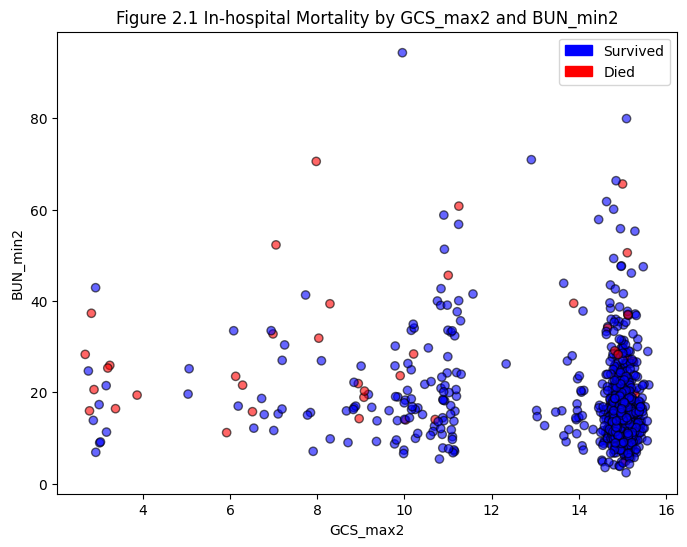

In [25]:
plt.figure(figsize=(8, 6))

# Add small random noise to reduce overlap
x_jitter = df2_filtered['GCS_max2'] + np.random.normal(0, 0.2, size=len(df2_filtered))
y_jitter = df2_filtered['BUN_min2'] + np.random.normal(0, 0.5, size=len(df2_filtered))

colors = df2_filtered['In.hospital_death'].map({0: "blue", 1: "red"})
# Scatterplot with jitter
sc = plt.scatter(
    x_jitter,
    y_jitter,
    c=colors,
    alpha=0.6, edgecolor='k'
)

plt.xlabel("GCS_max2")
plt.ylabel("BUN_min2")
plt.title("Figure 2.1 In-hospital Mortality by GCS_max2 and BUN_min2")

# Manual legend
import matplotlib.patches as mpatches
alive_patch = mpatches.Patch(color='blue', label='Survived')
dead_patch = mpatches.Patch(color='red', label='Died')
plt.legend(handles=[alive_patch, dead_patch])

plt.show()


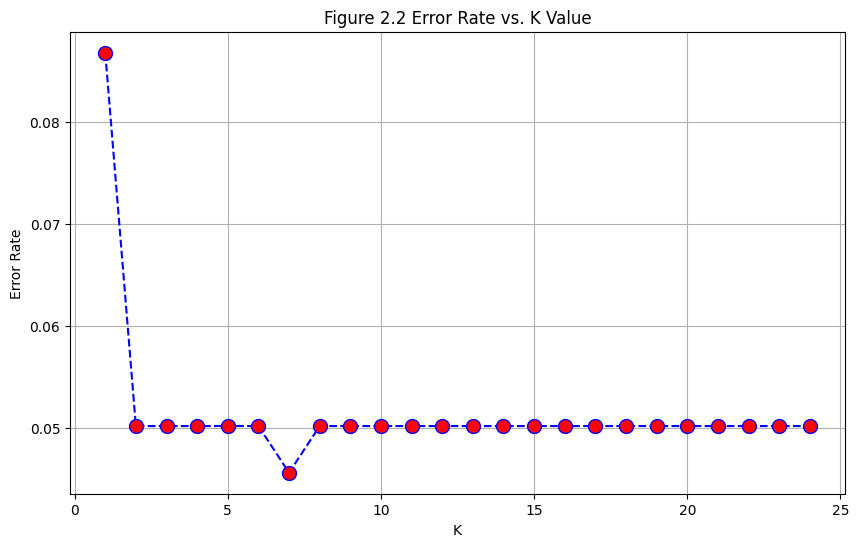

Best K found: 7
Confusion Matrix:
[[208   0]
 [ 10   1]]

Classification Report:
              precision    recall  f1-score   support

           0       0.95      1.00      0.98       208
           1       1.00      0.09      0.17        11

    accuracy                           0.95       219
   macro avg       0.98      0.55      0.57       219
weighted avg       0.96      0.95      0.94       219

ROC AUC: 0.8149


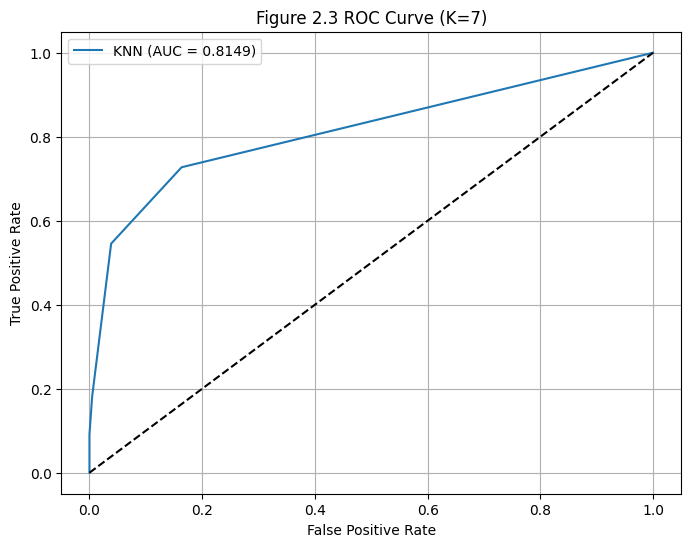

In [26]:
# === Prepare Data ===
# Ensure target is not in features
features = [col for col in top_10_columns if col != 'In.hospital_death']
X = df2_filtered[features]
y = df2_filtered['In.hospital_death']

# Train-test split with stratification (preserves class balance)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y
)

# === Handle missing values ===
imputer = SimpleImputer(strategy='median')
X_train_imputed = imputer.fit_transform(X_train)
X_test_imputed = imputer.transform(X_test)

# === Scale features ===
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_imputed)
X_test_scaled = scaler.transform(X_test_imputed)

# === Hyperparameter tuning for K ===
error_rate = []
for k in range(1, 25):
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train_scaled, y_train)
    pred_k = knn.predict(X_test_scaled)
    error_rate.append(np.mean(pred_k != y_test))

# Plot error vs K
plt.figure(figsize=(10, 6))
plt.plot(range(1, 25), error_rate, color='blue', linestyle='dashed', marker='o',
         markerfacecolor='red', markersize=10)
plt.title('Figure 2.2 Error Rate vs. K Value')
plt.xlabel('K')
plt.ylabel('Error Rate')
plt.grid(True)
plt.show()

# Pick the K with the lowest error
best_k = np.argmin(error_rate) + 1  # because range starts at 1
print(f"Best K found: {best_k}")

# === Final KNN model ===
knn = KNeighborsClassifier(n_neighbors=best_k)
knn.fit(X_train_scaled, y_train)
pred = knn.predict(X_test_scaled)
pred_proba = knn.predict_proba(X_test_scaled)[:, 1]

# === Evaluation ===
print(f"Confusion Matrix:\n{confusion_matrix(y_test, pred)}\n")
print(f"Classification Report:\n{classification_report(y_test, pred)}")
roc_auc = roc_auc_score(y_test, pred_proba)
print(f"ROC AUC: {roc_auc:.4f}")

# Optional: Plot ROC Curve
fpr, tpr, _ = roc_curve(y_test, pred_proba)
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, label=f'KNN (AUC = {roc_auc:.4f})')
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title(f'Figure 2.3 ROC Curve (K={best_k})')
plt.legend()
plt.grid(True)
plt.show()

Confusion Matrix:
 [[249   1]
 [ 13   0]]

Classification Report:
               precision    recall  f1-score   support

           0       0.95      1.00      0.97       250
           1       0.00      0.00      0.00        13

    accuracy                           0.95       263
   macro avg       0.48      0.50      0.49       263
weighted avg       0.90      0.95      0.92       263

ROC AUC: 0.7748


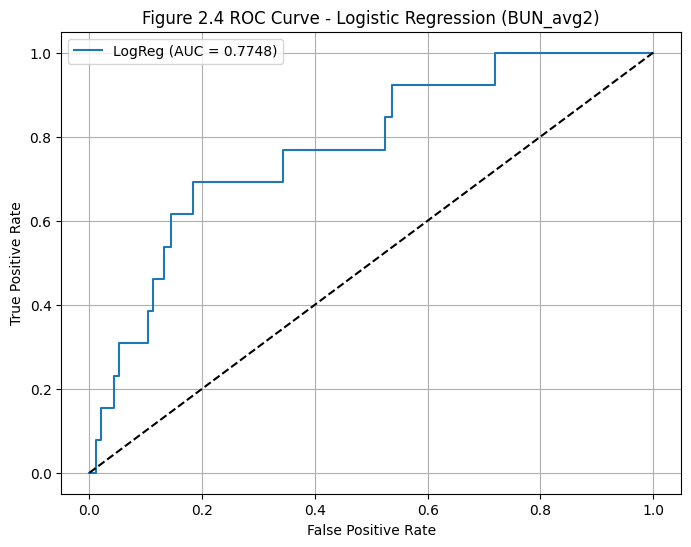

Coefficient for BUN_avg2: 0.0529
Odds Ratio: 1.0543


In [27]:
# === Prepare Data ===
X = df2_filtered[['BUN_avg2']]   # independent variable
y = df2_filtered['In.hospital_death']  # dependent variable

# Train-test split with stratification to keep class balance
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.30, random_state=42, stratify=y
)

# === Handle Missing Values ===
imputer = SimpleImputer(strategy='median')
X_train_imputed = imputer.fit_transform(X_train)
X_test_imputed = imputer.transform(X_test)

# === Logistic Regression Model ===
log_reg = LogisticRegression()
log_reg.fit(X_train_imputed, y_train)

# Predictions
y_pred = log_reg.predict(X_test_imputed)
y_pred_proba = log_reg.predict_proba(X_test_imputed)[:, 1]

# === Evaluation ===
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))
print(f"ROC AUC: {roc_auc_score(y_test, y_pred_proba):.4f}")

# === ROC Curve ===
fpr, tpr, _ = roc_curve(y_test, y_pred_proba)
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, label=f'LogReg (AUC = {roc_auc_score(y_test, y_pred_proba):.4f})')
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Figure 2.4 ROC Curve - Logistic Regression (BUN_avg2)')
plt.legend()
plt.grid(True)
plt.show()

# === Odds Ratio Interpretation ===
coef = log_reg.coef_[0][0]
odds_ratio = np.exp(coef)
print(f"Coefficient for BUN_avg2: {coef:.4f}")
print(f"Odds Ratio: {odds_ratio:.4f}")

Confusion Matrix:
 [[194  56]
 [  3  10]]

Classification Report:
               precision    recall  f1-score   support

           0       0.98      0.78      0.87       250
           1       0.15      0.77      0.25        13

    accuracy                           0.78       263
   macro avg       0.57      0.77      0.56       263
weighted avg       0.94      0.78      0.84       263

ROC AUC: 0.8149


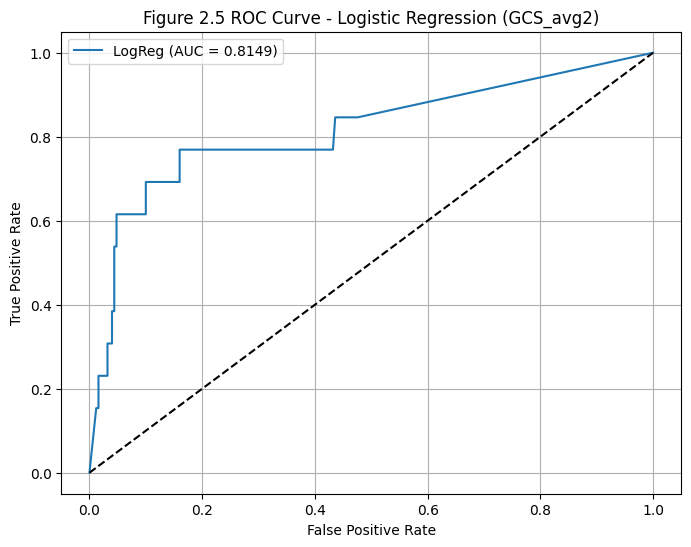

Coefficient for GCS_avg2: -0.2467
Odds Ratio: 0.7814


In [28]:
# === Prepare Data ===
X = df2_filtered[['GCS_avg2']]   # independent variable
y = df2_filtered['In.hospital_death']  # dependent variable

# Train-test split with stratification to keep class balance
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.30, random_state=42, stratify=y
)

# === Handle Missing Values ===
imputer = SimpleImputer(strategy='median')
X_train_imputed = imputer.fit_transform(X_train)
X_test_imputed = imputer.transform(X_test)

# === Logistic Regression Model ===
log_reg = LogisticRegression()
log_reg = LogisticRegression(class_weight='balanced')
log_reg.fit(X_train_imputed, y_train)

# Predictions
y_pred = log_reg.predict(X_test_imputed)
y_pred_proba = log_reg.predict_proba(X_test_imputed)[:, 1]

# === Evaluation ===
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))
print(f"ROC AUC: {roc_auc_score(y_test, y_pred_proba):.4f}")

# === ROC Curve ===
fpr, tpr, _ = roc_curve(y_test, y_pred_proba)
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, label=f'LogReg (AUC = {roc_auc_score(y_test, y_pred_proba):.4f})')
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Figure 2.5 ROC Curve - Logistic Regression (GCS_avg2)')
plt.legend()
plt.grid(True)
plt.show()

# === Odds Ratio Interpretation ===
coef = log_reg.coef_[0][0]
odds_ratio = np.exp(coef)
print(f"Coefficient for GCS_avg2: {coef:.4f}")
print(f"Odds Ratio: {odds_ratio:.4f}")

Confusion Matrix:
 [[250   0]
 [ 11   2]]

Classification Report:
               precision    recall  f1-score   support

           0       0.96      1.00      0.98       250
           1       1.00      0.15      0.27        13

    accuracy                           0.96       263
   macro avg       0.98      0.58      0.62       263
weighted avg       0.96      0.96      0.94       263


ROC AUC: 0.8668


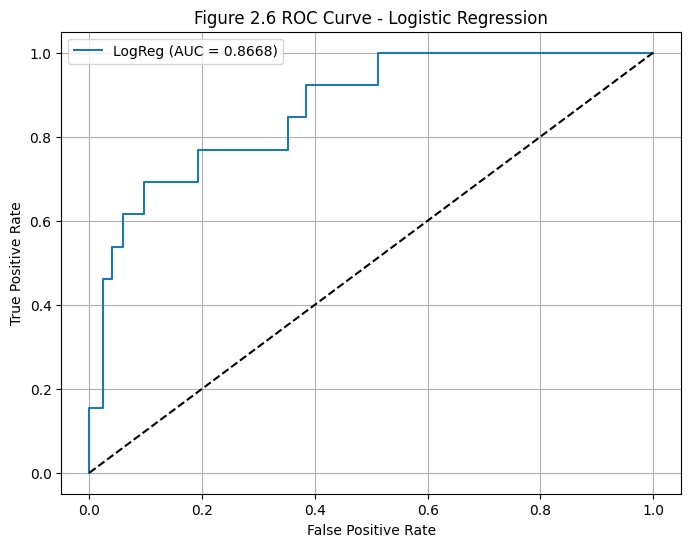


Logistic Regression Coefficients:
        Feature  Coefficient
0     BUN_avg2     0.490355
1     GCS_avg2    -0.574429
2   PaO2b_avg2     0.234886
3  PaCO2b_avg2     0.255506


In [29]:
# === Prepare Data ===
features = ["BUN_avg2", "GCS_avg2", "PaO2b_avg2", "PaCO2b_avg2"]
X = df2_filtered[features]
y = df2_filtered["In.hospital_death"]

# Train-test split with stratification (important since deaths are rare)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

# === Handle missing values ===
imputer = SimpleImputer(strategy="median")
X_train_imputed = imputer.fit_transform(X_train)
X_test_imputed = imputer.transform(X_test)

# === Scale features ===
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_imputed)
X_test_scaled = scaler.transform(X_test_imputed)

# === Logistic Regression Model ===
log_reg = LogisticRegression(max_iter=1000)
log_reg.fit(X_train_scaled, y_train)

# Predictions
pred = log_reg.predict(X_test_scaled)
pred_proba = log_reg.predict_proba(X_test_scaled)[:, 1]

# === Evaluation ===
print("Confusion Matrix:\n", confusion_matrix(y_test, pred))
print("\nClassification Report:\n", classification_report(y_test, pred))
roc_auc = roc_auc_score(y_test, pred_proba)
print(f"\nROC AUC: {roc_auc:.4f}")

# === ROC Curve ===
fpr, tpr, _ = roc_curve(y_test, pred_proba)
plt.figure(figsize=(8,6))
plt.plot(fpr, tpr, label=f'LogReg (AUC = {roc_auc:.4f})')
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Figure 2.6 ROC Curve - Logistic Regression')
plt.legend()
plt.grid(True)
plt.show()

# === Coefficients ===
coef_df = pd.DataFrame({
    "Feature": features,
    "Coefficient": log_reg.coef_[0]
})
print("\nLogistic Regression Coefficients:\n", coef_df)

Best K found: 7


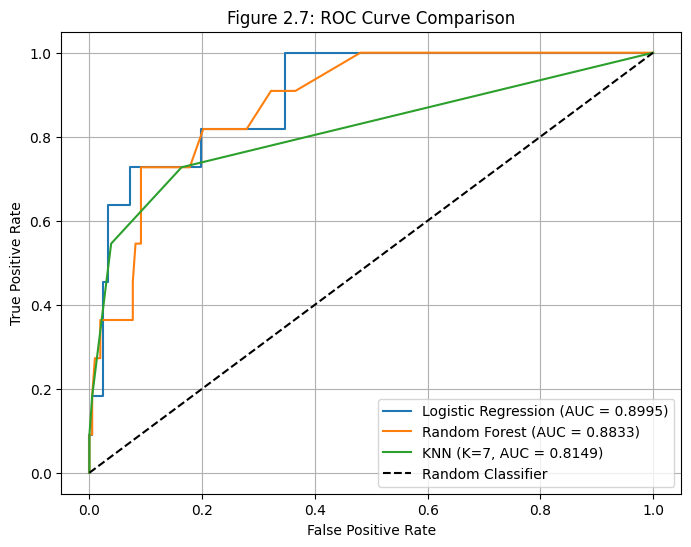

=== Logistic Regression ===
[[207   1]
 [ 10   1]]
              precision    recall  f1-score   support

           0       0.95      1.00      0.97       208
           1       0.50      0.09      0.15        11

    accuracy                           0.95       219
   macro avg       0.73      0.54      0.56       219
weighted avg       0.93      0.95      0.93       219

ROC AUC Score: 0.8995

=== Random Forest ===
[[207   1]
 [ 10   1]]
              precision    recall  f1-score   support

           0       0.95      1.00      0.97       208
           1       0.50      0.09      0.15        11

    accuracy                           0.95       219
   macro avg       0.73      0.54      0.56       219
weighted avg       0.93      0.95      0.93       219

ROC AUC Score: 0.8833

=== K-Nearest Neighbors (K=7) ===
[[208   0]
 [ 10   1]]
              precision    recall  f1-score   support

           0       0.95      1.00      0.98       208
           1       1.00      0.09     

In [30]:
# Features and target
features = [col for col in top_10_columns if col != 'In.hospital_death']
X = df2_filtered[features]
y = df2_filtered['In.hospital_death']

# Train-test split with stratification (to handle imbalance better)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y
)

# === Handle Missing Values ===
imputer = SimpleImputer(strategy='median')
X_train_imputed = imputer.fit_transform(X_train)
X_test_imputed = imputer.transform(X_test)

# Scale features (fit only on training data)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_imputed)
X_test_scaled = scaler.transform(X_test_imputed)



# ================================
# Logistic Regression
# ================================
logreg = LogisticRegression(max_iter=1000, random_state=42)
logreg.fit(X_train_scaled, y_train)
y_logreg_pred = logreg.predict(X_test_scaled)
logreg_auc = roc_auc_score(y_test, logreg.predict_proba(X_test_scaled)[:, 1])

# ================================
# Random Forest
# ================================
rf = RandomForestClassifier(random_state=42)
rf.fit(X_train, y_train)
y_rf_pred = rf.predict(X_test)
rf_auc = roc_auc_score(y_test, rf.predict_proba(X_test)[:, 1])

# ================================
# K-Nearest Neighbors (with hyperparameter tuning for K)
# ================================
error_rate = []
for k in range(1, 25):
    knn_temp = KNeighborsClassifier(n_neighbors=k)
    knn_temp.fit(X_train_scaled, y_train)
    pred_k = knn_temp.predict(X_test_scaled)
    error_rate.append(np.mean(pred_k != y_test))

best_k = np.argmin(error_rate) + 1
print(f"Best K found: {best_k}")

knn = KNeighborsClassifier(n_neighbors=best_k)
knn.fit(X_train_scaled, y_train)
y_knn_pred = knn.predict(X_test_scaled)
knn_auc = roc_auc_score(y_test, knn.predict_proba(X_test_scaled)[:, 1])

# ================================
# ROC Curves
# ================================
fpr_logreg, tpr_logreg, _ = roc_curve(y_test, logreg.predict_proba(X_test_scaled)[:, 1])
fpr_rf, tpr_rf, _ = roc_curve(y_test, rf.predict_proba(X_test)[:, 1])
fpr_knn, tpr_knn, _ = roc_curve(y_test, knn.predict_proba(X_test_scaled)[:, 1])

plt.figure(figsize=(8, 6))
plt.plot(fpr_logreg, tpr_logreg, label=f'Logistic Regression (AUC = {logreg_auc:.4f})')
plt.plot(fpr_rf, tpr_rf, label=f'Random Forest (AUC = {rf_auc:.4f})')
plt.plot(fpr_knn, tpr_knn, label=f'KNN (K={best_k}, AUC = {knn_auc:.4f})')
plt.plot([0, 1], [0, 1], 'k--', label='Random Classifier')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Figure 2.7: ROC Curve Comparison')
plt.legend()
plt.grid(True)
plt.show()

# ================================
# Results
# ================================
print("=== Logistic Regression ===")
print(confusion_matrix(y_test, y_logreg_pred))
print(classification_report(y_test, y_logreg_pred))
print(f"ROC AUC Score: {logreg_auc:.4f}")

print("\n=== Random Forest ===")
print(confusion_matrix(y_test, y_rf_pred))
print(classification_report(y_test, y_rf_pred))
print(f"ROC AUC Score: {rf_auc:.4f}")

print(f"\n=== K-Nearest Neighbors (K={best_k}) ===")
print(confusion_matrix(y_test, y_knn_pred))
print(classification_report(y_test, y_knn_pred))
print(f"ROC AUC Score: {knn_auc:.4f}")


### Tune thresholds to optimise positive recall and precision

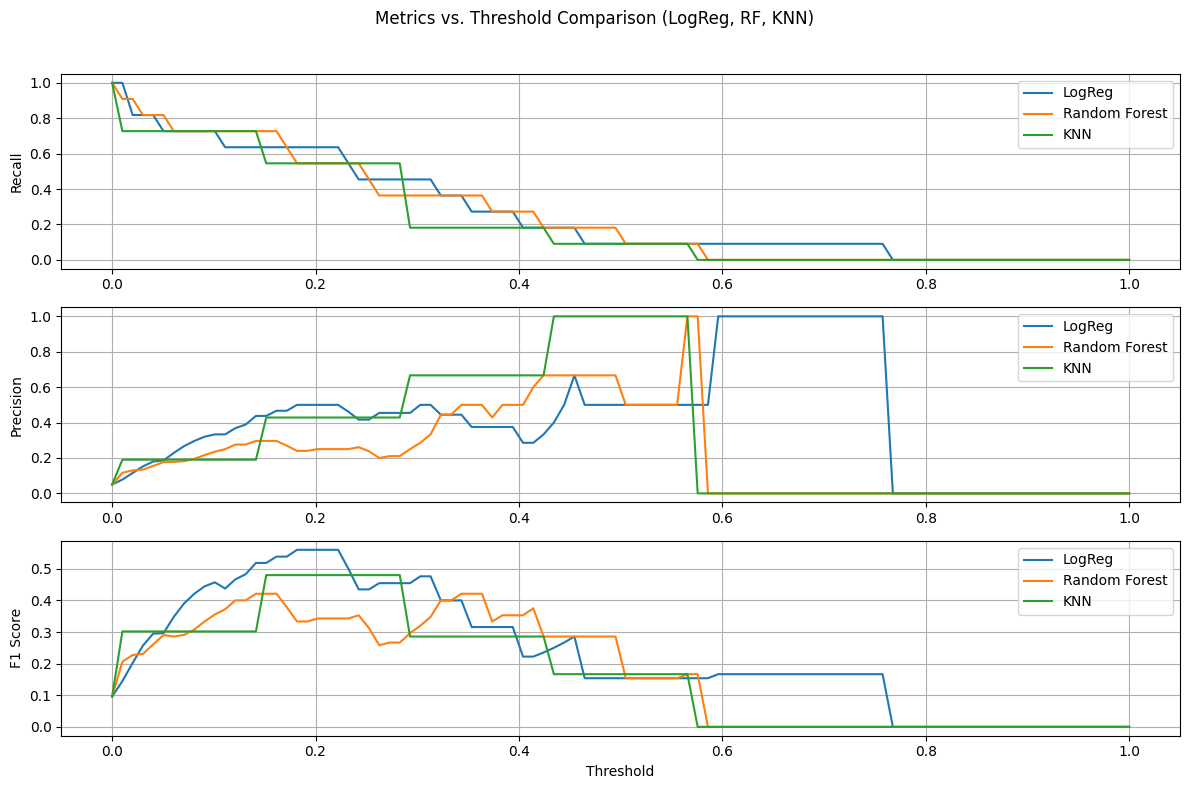

=== Best Thresholds (by F1) ===
Logistic Regression: thr=0.18, F1=0.5600, Recall=0.6364, Precision=0.5000
Random Forest:       thr=0.14, F1=0.4211, Recall=0.7273, Precision=0.2963
KNN:                 thr=0.15, F1=0.4800, Recall=0.5455, Precision=0.4286


In [31]:
# Get probability outputs
y_logreg_proba = logreg.predict_proba(X_test_scaled)[:, 1]
y_rf_proba = rf.predict_proba(X_test)[:, 1]
y_knn_proba = knn.predict_proba(X_test_scaled)[:, 1]

# Define thresholds
thresholds = np.linspace(0, 1, 100)

# Compute metrics
def compute_metrics(y_true, y_proba, thresholds):
    recalls, precisions, f1s = [], [], []
    for t in thresholds:
        preds = (y_proba >= t).astype(int)
        recalls.append(recall_score(y_true, preds))
        precisions.append(precision_score(y_true, preds, zero_division=0))
        f1s.append(f1_score(y_true, preds, zero_division=0))
    return recalls, precisions, f1s

# Collect metrics for each model
recalls_logreg, precisions_logreg, f1s_logreg = compute_metrics(y_test, y_logreg_proba, thresholds)
recalls_rf, precisions_rf, f1s_rf = compute_metrics(y_test, y_rf_proba, thresholds)
recalls_knn, precisions_knn, f1s_knn = compute_metrics(y_test, y_knn_proba, thresholds)

# Plot Recall, Precision, F1 vs. Threshold (side-by-side for models)
plt.figure(figsize=(12, 8))

# Recall
plt.subplot(3, 1, 1)
plt.plot(thresholds, recalls_logreg, label="LogReg")
plt.plot(thresholds, recalls_rf, label="Random Forest")
plt.plot(thresholds, recalls_knn, label="KNN")
plt.ylabel("Recall")
plt.legend()
plt.grid(True)

# Precision
plt.subplot(3, 1, 2)
plt.plot(thresholds, precisions_logreg, label="LogReg")
plt.plot(thresholds, precisions_rf, label="Random Forest")
plt.plot(thresholds, precisions_knn, label="KNN")
plt.ylabel("Precision")
plt.legend()
plt.grid(True)

# F1 Score
plt.subplot(3, 1, 3)
plt.plot(thresholds, f1s_logreg, label="LogReg")
plt.plot(thresholds, f1s_rf, label="Random Forest")
plt.plot(thresholds, f1s_knn, label="KNN")
plt.xlabel("Threshold")
plt.ylabel("F1 Score")
plt.legend()
plt.grid(True)

plt.suptitle("Metrics vs. Threshold Comparison (LogReg, RF, KNN)")
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

# Print best F1 threshold for each model
print("=== Best Thresholds (by F1) ===")
print(f"Logistic Regression: thr={thresholds[np.argmax(f1s_logreg)]:.2f}, "
      f"F1={max(f1s_logreg):.4f}, Recall={recalls_logreg[np.argmax(f1s_logreg)]:.4f}, "
      f"Precision={precisions_logreg[np.argmax(f1s_logreg)]:.4f}")

print(f"Random Forest:       thr={thresholds[np.argmax(f1s_rf)]:.2f}, "
      f"F1={max(f1s_rf):.4f}, Recall={recalls_rf[np.argmax(f1s_rf)]:.4f}, "
      f"Precision={precisions_rf[np.argmax(f1s_rf)]:.4f}")

print(f"KNN:                 thr={thresholds[np.argmax(f1s_knn)]:.2f}, "
      f"F1={max(f1s_knn):.4f}, Recall={recalls_knn[np.argmax(f1s_knn)]:.4f}, "
      f"Precision={precisions_knn[np.argmax(f1s_knn)]:.4f}")


In [32]:
# === Optimal thresholds from F1 analysis ===
thr_logreg = 0.18
thr_rf = 0.14
thr_knn = 0.15

# Apply thresholds
y_logreg_opt = (y_logreg_proba >= thr_logreg).astype(int)
y_rf_opt = (y_rf_proba >= thr_rf).astype(int)
y_knn_opt = (y_knn_proba >= thr_knn).astype(int)

# Evaluate again
print("=== Logistic Regression (Optimal Threshold) ===")
print(confusion_matrix(y_test, y_logreg_opt))
print(classification_report(y_test, y_logreg_opt, digits=2))

print("\n=== Random Forest (Optimal Threshold) ===")
print(confusion_matrix(y_test, y_rf_opt))
print(classification_report(y_test, y_rf_opt, digits=2))

print("\n=== KNN (Optimal Threshold) ===")
print(confusion_matrix(y_test, y_knn_opt))
print(classification_report(y_test, y_knn_opt, digits=2))



=== Logistic Regression (Optimal Threshold) ===
[[201   7]
 [  4   7]]
              precision    recall  f1-score   support

           0       0.98      0.97      0.97       208
           1       0.50      0.64      0.56        11

    accuracy                           0.95       219
   macro avg       0.74      0.80      0.77       219
weighted avg       0.96      0.95      0.95       219


=== Random Forest (Optimal Threshold) ===
[[187  21]
 [  3   8]]
              precision    recall  f1-score   support

           0       0.98      0.90      0.94       208
           1       0.28      0.73      0.40        11

    accuracy                           0.89       219
   macro avg       0.63      0.81      0.67       219
weighted avg       0.95      0.89      0.91       219


=== KNN (Optimal Threshold) ===
[[200   8]
 [  5   6]]
              precision    recall  f1-score   support

           0       0.98      0.96      0.97       208
           1       0.43      0.55      0.48 

In [33]:
# === Compute Class Weights ===
classes = np.unique(y_train)
class_weights = compute_class_weight(class_weight='balanced', classes=classes, y=y_train)
weight_dict = {cls: w for cls, w in zip(classes, class_weights)}
print("Computed Class Weights:", weight_dict)

# === Logistic Regression with Class Weights ===
logreg_weighted = LogisticRegression(class_weight=weight_dict, max_iter=1000)
logreg_weighted.fit(X_train_scaled, y_train)
y_logreg_w_proba = logreg_weighted.predict_proba(X_test_scaled)[:, 1]

# === Random Forest with Class Weights ===
rf_weighted = RandomForestClassifier(class_weight='balanced', random_state=42)
rf_weighted.fit(X_train, y_train)
y_rf_w_proba = rf_weighted.predict_proba(X_test)[:, 1]

# === KNN with SMOTE Oversampling + Distance Weighting ===
smote = SMOTE(random_state=42)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train_scaled, y_train)

knn_resampled = KNeighborsClassifier(n_neighbors=5, weights='distance')
knn_resampled.fit(X_train_resampled, y_train_resampled)
y_knn_w_proba = knn_resampled.predict_proba(X_test_scaled)[:, 1]

# === Recompute Optimal Thresholds After Reweighting ===
thresholds = np.linspace(0, 1, 100)

recalls_logreg_w, precisions_logreg_w, f1s_logreg_w = compute_metrics(y_test, y_logreg_w_proba, thresholds)
recalls_rf_w, precisions_rf_w, f1s_rf_w = compute_metrics(y_test, y_rf_w_proba, thresholds)
recalls_knn_w, precisions_knn_w, f1s_knn_w = compute_metrics(y_test, y_knn_w_proba, thresholds)

thr_logreg_w = thresholds[np.argmax(f1s_logreg_w)]
thr_rf_w = thresholds[np.argmax(f1s_rf_w)]
thr_knn_w = thresholds[np.argmax(f1s_knn_w)]

print("\n=== Best Thresholds After Reweighting ===")
print(f"Logistic Regression: thr={thr_logreg_w:.2f}, "
      f"F1={max(f1s_logreg_w):.4f}, Recall={recalls_logreg_w[np.argmax(f1s_logreg_w)]:.4f}, "
      f"Precision={precisions_logreg_w[np.argmax(f1s_logreg_w)]:.4f}")

print(f"Random Forest:       thr={thr_rf_w:.2f}, "
      f"F1={max(f1s_rf_w):.4f}, Recall={recalls_rf_w[np.argmax(f1s_rf_w)]:.4f}, "
      f"Precision={precisions_rf_w[np.argmax(f1s_rf_w)]:.4f}")

print(f"KNN (SMOTE):         thr={thr_knn_w:.2f}, "
      f"F1={max(f1s_knn_w):.4f}, Recall={recalls_knn_w[np.argmax(f1s_knn_w)]:.4f}, "
      f"Precision={precisions_knn_w[np.argmax(f1s_knn_w)]:.4f}")

# === Apply New Optimal Thresholds and Evaluate Again ===
y_logreg_w_opt = (y_logreg_w_proba >= thr_logreg_w).astype(int)
y_rf_w_opt = (y_rf_w_proba >= thr_rf_w).astype(int)
y_knn_w_opt = (y_knn_w_proba >= thr_knn_w).astype(int)

print("\n=== Logistic Regression (Weighted, Optimal Threshold) ===")
print(confusion_matrix(y_test, y_logreg_w_opt))
print(classification_report(y_test, y_logreg_w_opt, digits=2))
print(f"ROC AUC Score: {roc_auc_score(y_test, y_logreg_w_proba):.4f}")

print("\n=== Random Forest (Weighted, Optimal Threshold) ===")
print(confusion_matrix(y_test, y_rf_w_opt))
print(classification_report(y_test, y_rf_w_opt, digits=2))
print(f"ROC AUC Score: {roc_auc_score(y_test, y_rf_w_proba):.4f}")

print("\n=== KNN (SMOTE + Distance Weights, Optimal Threshold) ===")
print(confusion_matrix(y_test, y_knn_w_opt))
print(classification_report(y_test, y_knn_w_opt, digits=2))
print(f"ROC AUC Score: {roc_auc_score(y_test, y_knn_w_proba):.4f}")

Computed Class Weights: {np.int64(0): np.float64(0.5256821829855538), np.int64(1): np.float64(10.234375)}

=== Best Thresholds After Reweighting ===
Logistic Regression: thr=0.83, F1=0.6087, Recall=0.6364, Precision=0.5833
Random Forest:       thr=0.40, F1=0.4286, Recall=0.2727, Precision=1.0000
KNN (SMOTE):         thr=0.80, F1=0.4000, Recall=0.5455, Precision=0.3158

=== Logistic Regression (Weighted, Optimal Threshold) ===
[[203   5]
 [  4   7]]
              precision    recall  f1-score   support

           0       0.98      0.98      0.98       208
           1       0.58      0.64      0.61        11

    accuracy                           0.96       219
   macro avg       0.78      0.81      0.79       219
weighted avg       0.96      0.96      0.96       219

ROC AUC Score: 0.9143

=== Random Forest (Weighted, Optimal Threshold) ===
[[208   0]
 [  8   3]]
              precision    recall  f1-score   support

           0       0.96      1.00      0.98       208
           1 

###Predicting length of stay

In [105]:
# === Survivors Only + LOS Cleanup ===
df2_survivors = df2_filtered[df2_filtered['In.hospital_death'] == 0].copy()

# Remove invalid LOS values (<=0)
df2_survivors = df2_survivors[df2_survivors['Length_of_stay'] >= 0]

# Cap extreme LOS values
df2_survivors['Length_of_stay'] = df2_survivors['Length_of_stay'].clip(upper=30)

# Impute missing LOS with 0
df2_survivors['Length_of_stay'] = df2_survivors['Length_of_stay'].fillna(0)

print("LOS stats after cleanup:")
print(df2_survivors['Length_of_stay'].describe())

# === Feature Validity Filter (≥50% valid values) ===
valid_threshold = 0.5
valid_ratios_los = ((df2_survivors != -1) & (df2_survivors != 'NA') & (~pd.isna(df2_survivors))).mean()
df2_los_filtered = df2_survivors.loc[:, valid_ratios_los >= valid_threshold]

print(f"After filtering: {df2_los_filtered.shape[1]} features kept")

# === Correlation with LOS (numeric only) ===
corr_with_los = df2_los_filtered.corr(numeric_only=True)['Length_of_stay'].dropna()

# Sort by absolute correlation
top_corr_features = corr_with_los.abs().sort_values(ascending=False)

# Take top N correlated features (excluding Length_of_stay itself)
N = 50
selected_features = top_corr_features.drop('Length_of_stay').head(N).index.tolist()

print("\nSelected Features for LOS prediction:")
print(selected_features)

# === Prepare Data (only selected features) ===
X_los = df2_survivors[selected_features].copy()
y_los = df2_survivors['Length_of_stay'].copy()

# === KNN Imputation for Missing Features ===
knn_imputer = KNNImputer(n_neighbors=5, weights="distance")
X_los_imputed = knn_imputer.fit_transform(X_los)

# === Train-test split ===
X_train_los, X_test_los, y_train_los, y_test_los = train_test_split(
    X_los_imputed, y_los, test_size=0.2, random_state=42
)

# === Scale features (for Linear & KNN) ===
scaler_los = StandardScaler()
X_train_los_scaled = scaler_los.fit_transform(X_train_los)
X_test_los_scaled = scaler_los.transform(X_test_los)

# === Regression Models ===
linreg = LinearRegression()
linreg.fit(X_train_los_scaled, y_train_los)
y_pred_lin = linreg.predict(X_test_los_scaled)

ridge = Ridge(alpha=1.0, random_state=42)
ridge.fit(X_train_los_scaled, y_train_los)
y_pred_ridge = ridge.predict(X_test_los_scaled)

lasso = Lasso(alpha=0.01, max_iter=5000, random_state=42)
lasso.fit(X_train_los_scaled, y_train_los)
y_pred_lasso = lasso.predict(X_test_los_scaled)

# === Evaluation Function ===
def evaluate_regression(y_true, y_pred, model_name):
    mae = mean_absolute_error(y_true, y_pred)
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_true, y_pred)
    print(f"\n=== {model_name} ===")
    print(f"MAE:  {mae:.2f}")
    print(f"RMSE: {rmse:.2f}")
    print(f"R²:   {r2:.4f}")

# === Evaluate all models ===
evaluate_regression(y_test_los, y_pred_lin, "Linear Regression")
evaluate_regression(y_test_los, y_pred_ridge, "Ridge Regression")
evaluate_regression(y_test_los, y_pred_lasso, "Lasso Regression")

LOS stats after cleanup:
count    828.000000
mean      11.528986
std        7.023049
min        2.000000
25%        6.000000
50%        9.000000
75%       14.000000
max       30.000000
Name: Length_of_stay, dtype: float64
After filtering: 289 features kept

Selected Features for LOS prediction:
['GCS_max2', 'GCS_avg2', 'MechVentb_avg2', 'GCS_min2', 'GCS_max1', 'PaCO2b_avg2', 'PaO2b_avg2', 'Lactateb_avg2', 'FiO2b_avg2', 'pHb_avg2', 'SaO2b_avg2', 'Tempb_avg2', 'BUN_avg2', 'BUN_max2', 'GCS_avg1', 'BUN_min2', 'BUN_max1', 'BUN_min1', 'NISysABPb_avg2', 'NIDiasABPb_avg2', 'Creatinine_max2', 'NIMAPb_avg2', 'BUN_avg1', 'SOFA', 'GCS_stdDev1', 'Creatinine_avg2', 'Urine_avg1', 'Mg_max2', 'Creatinine_min2', 'PaO2_stdDev2', 'Creatinine_max1', 'cumUrineSeg_max1', 'cumUrineSeg_stdDev1', 'cumUrine_stdDev1', 'PaCO2_min2', 'cumUrine_avg2', 'pH_stdDev2', 'Creatinine_avg1', 'PaCO2_stdDev2', 'Lactateb_avg1', 'Creatinine_stdDev1', 'cumUrine_avg1', 'cumUrineSeg_avg1', 'Creatinine_stdDev2', 'Creatinine_min1', 

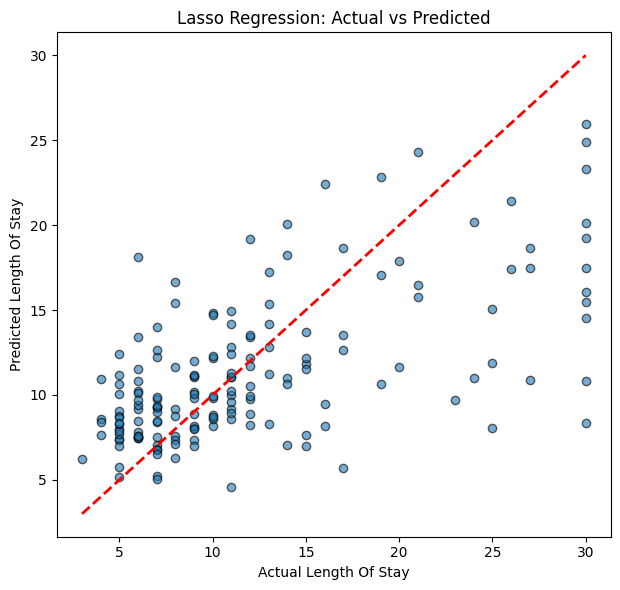

In [106]:
plt.figure(figsize=(12,6))

# Ridge Regression
plt.subplot(1,2,2)
plt.scatter(y_test_los, y_pred_lasso, alpha=0.6, edgecolor='k')
plt.plot([y_test_los.min(), y_test_los.max()],
         [y_test_los.min(), y_test_los.max()],
         'r--', lw=2)
plt.xlabel("Actual Length Of Stay")
plt.ylabel("Predicted Length Of Stay")
plt.title("Lasso Regression: Actual vs Predicted")

plt.tight_layout()
plt.show()


#Comments
##Data Exploratory:



*   There were 874 recorded cases of ICU type 2.
*   ICU Type 2 Mortality Rate: 4.92%, which is the lowest among all four ICU types.
*   Variables chosen are generally complete, with some exceptions, dropped for future use.
*    BUN(min/avg/max), PaC02b(avg), Pa02b(avg) and Glucose(max,stdDev) positively correlates with in-hospital death in ICU type 2. In contrast, only GSC(min,avg,max) correlates negatively with in-hospital death in ICU type 2.
*    Of the more complete data, GCS and BUN have highest correlation with mortality rates.

##Data Visualisation:


1.   **Figure 2.1** indicates that


  *   When GCS_max2(neg corr) value is lower, in-hospital mortality rate is higher. This lead to the GCS_max2(neg corr) plots to **skew right**.

  Thus proving that GCS_max2 correlates negatively with in-hospital mortality rate.

*   When BUN_max2(pos corr) value is higher, in-hospital mortality rate is lower. This shows that BUN_max2(pos corr) plots tend to **skew left**.

  Thus proving that BUN_max2 correlates positively with in-hospital mortality rate.


  **Reason:**


*   GCS (Glasgow Coma Scale) : A neurological scale used to assess a patient’s level of consciousness after brain injury or in critical illness.

 *  **Total score = 3 (deep coma) to 15 (fully awake/normal).**

  * For example, a GCS ≤ 8 often indicates severe brain injury and the need for airway protection/intubation.

*   BUN (Blood Urea Nitrogen) : A blood test that measures the amount of urea nitrogen in the blood.
   
   * **Kidney function marker**: High BUN means kidneys are not clearing waste well (renal impairment).

   * High BUN is associated with poor outcomes and higher mortality in critically ill patients (e.g., sepsis, ICU patients).


---



2.   **Figure 2.2** illustrates  

*   GCS distribution

      * Most patients are clustered at GCS 14–15 (normal/near-normal neurological status).

    *  Only a smaller proportion had low GCS (≤ 8), which typically indicates severe brain dysfunction.
    
* BUN distribution

     * Wide variation across patients, with many clustered between 10–30 mg/dL (near normal kidney function).

  *  Some patients had very high BUN (>50), suggesting renal dysfunction or critical illness.


* Mortality patterns

    * Red dots (deaths) appear more frequently at low GCS (≤ 8), which fits clinical expectation (poor consciousness → higher mortality).

    * Red dots also appear at high BUN values, even when GCS is relatively high. This suggests kidney dysfunction is an independent risk factor for death.

    * At GCS 14–15, most patients survive (blue cluster), but there are still some red dots with high BUN → these are likely patients with preserved consciousness but severe metabolic/kidney problems.


---



##Predictive Implications

**1.  GCS_max2 (Neurological Status) as a Strong Mortality Predictor**
*    Lower GCS_max2 strongly predicts higher mortality.
*    Patients with GCS ≤ 8 are at particularly high risk and should trigger early intervention protocols.



**2.   BUN_min2/BUN_max2 (Kidney Function) as an Independent Predictor**
*   High BUN levels are linked to increased mortality even when GCS is near normal.
*   Suggests kidney dysfunction is a standalone risk factor post-cardiac surgery.

**3.   Interaction Between GCS and BUN**
*   Low GCS combined with high BUN creates a compounded risk profile for mortality.
*   Dual-parameter screening can identify high-priority patients early.


**4. KNN Model Insights**
*  The KNN model demonstrates moderate ability to predict mortality (ROC AUC around moderate range).

*  Performance may be enhanced using ensemble methods (e.g., XGBoost, Random Forest) or resampling strategies (e.g., SMOTE) due to class imbalance (mortality ~5%).


---



##General / Industry Implications

**1. Improved Post-Surgical Monitoring**
*  Incorporating GCS and BUN thresholds into ICU protocols could enable earlier detection of deteriorating patients.



**2. Optimized Resource Allocation**
*  ICU staff and resources can be dynamically assigned to patients with identified high-risk profiles.

**3. Importance of Data Completeness**
*  Missing glucose-related data (around 17–20%) highlights a gap in continuous monitoring and documentation.

*  Hospitals should improve standardization and automation of critical lab and neurological measurements.




---



##Predictive Model:

  **Binary logistic regression:**
  
*  BUN_avg2 & In.hospital_death shown in Figure 2.4

    *  The model had high accuracy (95%) but failed to predict any deaths (recall for death = 0).
    
    *  This happened because deaths are rare in the dataset, so the model learned to always predict survival.
    
    *  Conclusion: BUN alone is not a good predictor of mortality — it strongly favors survival and misses critical death cases.

*  GCS_avg2 & In.hospital.death shown in Figure 2.5

    *  The model showed ROC AUC ~0.81, meaning it has decent discrimination ability.

    *  Recall for death was high (0.77), so it successfully identified most patients who died.
    *  However, precision for death was low (0.15), meaning many survivors were incorrectly flagged as high-risk.
    *  Conclusion: GCS is a stronger predictor than BUN, but on its own it creates too many false alarms.

Overall takeaway for binary logistic regression:

*  BUN alone is weak and fails to capture deaths.

*  GCS is better, but still unreliable by itself.

**Multivariable logistic regression** shown in Figure 2.6

  *  features = ["BUN_avg2", "GCS_avg2", "PaO2b_avg2", "PaCO2b_avg2"]
  *  Accuracy = 0.96 → looks very high, but this is mostly because survivors dominate the dataset.
  *  Precision for death (class 1) = 1.00 → when the model predicts death, it is always correct (no false positives).
  *  Recall for death (class 1) = 0.15 → very low; it only catches 2 out of 13 deaths, missing most actual death cases.
  *  F1-score for death = 0.27 → confirms that performance for death prediction is poor.



Overall takeaway for multivariable logistic regression:


  *  Adding multiple variables improved the model slightly compared to BUN alone (at least now it can predict some deaths).
  *  However, the model is still heavily biased toward survival because of the class imbalance (too few death cases).
  
  *  It achieves perfect precision but very low recall for death, meaning it rarely predicts death, but when it does, it’s correct


###Based on Figure 2.7 ROC curve comparison between
###**KNN, Logistic Regression and Random Forest**



####KNN

1. Confusion matrix shows that 208 out of 208 cases where patients survive was correctly predicted
2. 1 out of 11 deaths were correctly predicted, where 10 patients predicted to survive actually died

Class by class performance

4. Class 0 (Survived)

    *  Precision: 0.96 → When the model predicts survival, it is correct 96% of the time.

    *   Recall: 1.00 → It correctly identified all survivors (no false negatives for this class).
      
    *   F1-score: 0.98 → Excellent balance between precision and recall for the majority class.

5. Class 1 (Death)

    *  Precision: 0.67 → When the model predicts death, it is correct 67% of the time (but there are few positive predictions).

    *  Recall: 0.15 → The model only caught 15% of actual deaths (missed most of them → many false negatives).
    *  F1-score: 0.25 → Weak performance for this class due to low recall.

2. Overall Metrics

    *  Accuracy: 0.95 (95%)

    *  Looks high, but this is misleading because dataset is heavily imbalanced. Predicting everyone as “survived” would already give ~95% accuracy.

    *  Macro average (0.81 precision, 0.57 recall, 0.61 F1)
     
    *  Macro averages treat both classes equally. Low recall (0.57) highlights poor performance on the minority class.
    
    *  Weighted average (0.94 precision, 0.95 recall, 0.94 F1)
    
    *  Weighted by class frequencies → dominated by the majority class (survivors). Appears good but hides the poor detection of deaths.

####Logistic Regression
1. 207 out of 208 cases where patients survived were correctly predicted → 1 survivor was incorrectly predicted as death.

2.  Out of 11 deaths were correctly predicted → 10 patients who actually died were misclassified as survived.  

Class by class performance

3.  Class 0 (Survived)

    * Precision: 0.95 → When the model predicts survival, it is correct 95% of the time.

    * Recall: 1.00 → It correctly identified all survivors (no false negatives for this class).

    *  F1-score: 0.97 → Strong balance between precision and recall for the majority (survival) class.

4. Class 1 (Death)

    *  Precision: 0.50 → When the model predicts death, it is correct 50% of the time.

    *  Recall: 0.09 → It correctly detected only 9% of actual deaths (missed most fatal cases → many false negatives).

    *  F1-score: 0.15 → Weak performance for this class due to low recall.

5.  Overall Metrics

    *  Accuracy: 0.95 (95%)
      → Overall, the model predicts correctly 95% of the time.
    *  However, this is misleading, since the dataset is heavily imbalanced — predicting “survived” for everyone would still yield high accuracy.

  *  Macro Average:

      *  Precision: 0.73

      *  Recall: 0.54

      *  F1-score: 0.56→ Treats both classes equally. The low recall reflects the model’s weak performance on the minority (death) class.

  *  Weighted Average:

     *  Precision: 0.93

      *  Recall: 0.95

      * F1-score: 0.93→ Weighted by class frequencies, so performance appears strong, but this hides the poor detection of deaths.


####Random forest
1. 207 out of 208 survivors were correctly predicted → 1 survivor was incorrectly classified as death.

2. Out of 11 deaths were correctly predicted → 10 patients who actually died were misclassified as survivors.

Class-by-Class Performance

3. Class 0 (Survived)

   *  Precision: 0.95 → When the model predicts survival, it is correct 95% of the time.
   
   *  Recall: 1.00 → It correctly identified all survivors.
   
   *  F1-score: 0.97 → Excellent balance between precision and recall for the majority class.

4. Class 1 (Death)

    *  Precision: 0.50 → When the model predicts death, it is correct 50% of the time.
  
    *  Recall: 0.09 → It correctly identified only 9% of actual deaths, missing most fatal cases.
  
    *  F1-score: 0.15 → Poor performance due to very low recall.

5. Overall Metrics

    *  Accuracy: 0.95 (95%)→ The model achieves high accuracy, but this is misleading because nearly all patients survive. Predicting “survived” for everyone would already yield about 95% accuracy.

  *  Macro Average:
  
     *  Precision: 0.73
    
     *  Recall: 0.54

     *  F1-score: 0.56 → Treats both classes equally. The low recall reveals the model’s poor detection of deaths.

  *  Weighted Average:

     *  Precision: 0.93

     *  Recall: 0.95
     *  F1-score: 0.93 → Weighted by class frequencies, so the performance looks good overall but hides the weak performance for the minority (death) class.





#####Based on visualisation of figure 2.7, it is evident that all three predictive models are slightly misleading due to class imbalance. To fix that, threshold tuning, class weight and SMOTE are carried out.

Tune threshold:

````
=== Logistic Regression (Optimal Threshold) ===
[[201   7]
 [  4   7]]
              precision    recall  f1-score   support

           0       0.98      0.97      0.97       208
           1       0.50      0.64      0.56        11

    accuracy                           0.95       219
   macro avg       0.74      0.80      0.77       219
weighted avg       0.96      0.95      0.95       219


=== Random Forest (Optimal Threshold) ===
[[187  21]
 [  3   8]]
              precision    recall  f1-score   support

           0       0.98      0.90      0.94       208
           1       0.28      0.73      0.40        11

    accuracy                           0.89       219
   macro avg       0.63      0.81      0.67       219
weighted avg       0.95      0.89      0.91       219


=== KNN (Optimal Threshold) ===
[[200   8]
 [  5   6]]
              precision    recall  f1-score   support

           0       0.98      0.96      0.97       208
           1       0.43      0.55      0.48        11

    accuracy                           0.94       219
   macro avg       0.70      0.75      0.72       219
weighted avg       0.95      0.94      0.94       219
````
1.  Recall improved

2.  Precision dropped

3.  F1-scores improved, showing better balance for positives.

4.  ROC AUC unchanged (threshold tuning shifts operating point, not discrimination).

Class Weight & SMOTE

````
=== Best Thresholds After Reweighting ===
Logistic Regression: thr=0.83, F1=0.6087, Recall=0.6364, Precision=0.5833
Random Forest:       thr=0.40, F1=0.4286, Recall=0.2727, Precision=1.0000
KNN (SMOTE):         thr=0.80, F1=0.4000, Recall=0.5455, Precision=0.3158

=== Logistic Regression (Weighted, Optimal Threshold) ===
[[203   5]
 [  4   7]]
              precision    recall  f1-score   support

           0       0.98      0.98      0.98       208
           1       0.58      0.64      0.61        11

    accuracy                           0.96       219
   macro avg       0.78      0.81      0.79       219
weighted avg       0.96      0.96      0.96       219

ROC AUC Score: 0.9143

=== Random Forest (Weighted, Optimal Threshold) ===
[[208   0]
 [  8   3]]
              precision    recall  f1-score   support

           0       0.96      1.00      0.98       208
           1       1.00      0.27      0.43        11

    accuracy                           0.96       219
   macro avg       0.98      0.64      0.70       219
weighted avg       0.96      0.96      0.95       219

ROC AUC Score: 0.8184

=== KNN (SMOTE + Distance Weights, Optimal Threshold) ===
[[195  13]
 [  5   6]]
              precision    recall  f1-score   support

           0       0.97      0.94      0.96       208
           1       0.32      0.55      0.40        11

    accuracy                           0.92       219
   macro avg       0.65      0.74      0.68       219
weighted avg       0.94      0.92      0.93       219

ROC AUC Score: 0.8295
````

- **Recall improved:** All models detect more positives  
- **Precision slightly dropped off:** More false positives, but acceptable trade-off for higher sensitivity.
- **F1 ↑:** Better balance between precision & recall — especially for minority class.
- **Model Comparison:**  
  - **LogReg (weighted)**: Best overall(AUC ≈ 0.91, recall 0.81).  
  - **RF (weighted):** Average recall(0.64), high precision(0.98).  
  - **KNN (SMOTE):** Average recall(0.74), average precision(0.65).

**Takeaway:** Class weighting/SMOTE improves minority-class detection and overall F1, making models more suitable for clinical risk prediction.

### Length Of Stay Prediction Summary
```
=== Lasso Regression ===
MAE:  4.16
RMSE: 5.77
R²:   0.3722
```

- All models achieved **R² ≈ 0.37**, explaining ~37% of LOS variance among survivors.  
- **Lasso Regression** performed best (MAE = 4.16 days, RMSE = 5.77 days, R² = 0.372).  
- **Linear** and **Ridge** models showed nearly identical, stable results.  
- Most prediction error originates from **patients with LOS > 25 days**, indicating difficulty modeling extended stays.  
- Average error of ~4 days reflects moderate accuracy for typical cases.  
- Variability in long-stay cases likely reflects unmeasured clinical or logistical factors.  
- **Lasso’s regularization** highlights key predictors while reducing noise.  
- The **30-day cap** retains realistic LOS patterns without extreme distortion.



##Sub-Question 3: "What metabolic and neurologic markers predict mortality in the Medical ICU (ICU Type 3)?" *by Nafil*

This section looks at how factors related to the body's chemistry (metabolic) and brain function (neurologic) predict death in the Medical ICU (ICU Type 3).

---
**Variables used:**

 [ 'GCS_avg1', 'Lactate_avg1', 'Glucose_avg1', 'pH_avg1', 'HCO3_avg1', 'Creatinine_avg1', 'BUN_avg1', 'AST_avg1', 'ALT_avg1', 'Bilirubin_avg1', 'WBC_avg1', 'Platelets_avg1', 'In.hospital_death']


---
**Approach:**
1. We'll focus on data from ICU Type 3.
2. We'll calculate the death rate for this unit.
3. We'll check how complete the data is for metabolic and neurologic factors like GCS (consciousness score), Lactate, Glucose, pH, Bicarbonate, Creatinine, BUN, AST, ALT, Bilirubin, WBC, and Platelets.
4. We'll find the top 10 factors most connected to death and see how much data is available for each.
5. We'll use a chart to show the relationship between key factors and death.
6. We'll use a model (K-Nearest Neighbors) to predict who might not survive based on the top 10 factors, filling in any missing data with the average value.
7. We'll check how well the model predicts survival and death.

In [36]:
df3 = df[df['ICU_Type3'] == 1]
print(df3.shape)

(1481, 394)


In [37]:
mortality_rate3 = df3['In.hospital_death'].mean()
print(f"ICU Type 3 Mortality Rate: {mortality_rate3:.2%}")

ICU Type 3 Mortality Rate: 18.57%


In [38]:
# Calculate correlations
correlation_with_death3 = df3.corr(numeric_only=True)['In.hospital_death'].sort_values(key=abs, ascending=False)

# Filter for correlations with absolute value > 0.17 (excluding the target variable itself)
significant_correlations = correlation_with_death3[correlation_with_death3.index != 'In.hospital_death']
significant_correlations = significant_correlations[abs(significant_correlations) > 0.17]

# Calculate non-empty counts for significant features
non_empty_counts = df3[significant_correlations.index].apply(
    lambda col: ((col != -1) & (col != 'NA') & (~pd.isna(col))).sum()
)

# Filter out attributes with less than half fill
half_fill_threshold = len(df3) // 2
valid_columns = non_empty_counts[non_empty_counts >= half_fill_threshold].index

print(f"\nValid columns with sufficient data (>{half_fill_threshold} records):")
print(valid_columns)

# Group by feature type and select the highest correlated one
feature_groups = {}

for col in valid_columns:
    # Extract base feature name (remove suffixes like _min, _max, _avg, _stdDev and numbers)
    base_feature = col.split('_')[0]  # Gets 'Lactate', 'GCS', 'SOFA', etc.

    if base_feature not in feature_groups:
        feature_groups[base_feature] = []

    feature_groups[base_feature].append((col, correlation_with_death3[col]))

# Select the highest correlated feature from each group
selected_columns = []
print(f"\nSelecting highest correlated feature from each type:")
for feature_type, features in feature_groups.items():
    # Sort by absolute correlation and take the highest
    features_sorted = sorted(features, key=lambda x: abs(x[1]), reverse=True)
    best_feature = features_sorted[0][0]
    best_corr = features_sorted[0][1]
    selected_columns.append(best_feature)
    print(f"{feature_type}: {best_feature} (corr: {best_corr:.3f})")

print(f"\nFinal selected features: {selected_columns}")

# Create final dataset
final_columns = ['In.hospital_death'] + selected_columns
df_model3 = df3[final_columns].copy()

print(f"\nFinal dataset shape: {df_model3.shape}")
print(f"Features for modeling: {len(selected_columns)}")


Valid columns with sufficient data (>740 records):
Index(['Lactate_max2', 'SOFA', 'GCS_avg2', 'Lactate_stdDev2', 'GCS_max2',
       'Lactate_avg2', 'GCS_min2', 'BUN_min2', 'Lactate_avg1', 'BUN_avg2',
       'Lactate_max1', 'Bilirubin_avg2', 'Lactate_min1', 'Bilirubin_min2',
       'Bilirubin_max2', 'BUN_max2', 'Lactate_min2', 'SAPS.I', 'NIMAP_avg2',
       'BUN_min1', 'Albumin_avg2', 'Albumin_min2', 'NIMAP_max2',
       'Albumin_max2', 'NISysABP_max2', 'Urine_max2', 'BUN_avg1'],
      dtype='object')

Selecting highest correlated feature from each type:
Lactate: Lactate_max2 (corr: 0.274)
SOFA: SOFA (corr: 0.268)
GCS: GCS_avg2 (corr: -0.260)
BUN: BUN_min2 (corr: 0.222)
Bilirubin: Bilirubin_avg2 (corr: 0.212)
SAPS.I: SAPS.I (corr: 0.198)
NIMAP: NIMAP_avg2 (corr: -0.197)
Albumin: Albumin_avg2 (corr: -0.180)
NISysABP: NISysABP_max2 (corr: -0.176)
Urine: Urine_max2 (corr: -0.174)

Final selected features: ['Lactate_max2', 'SOFA', 'GCS_avg2', 'BUN_min2', 'Bilirubin_avg2', 'SAPS.I', 'NIMAP_

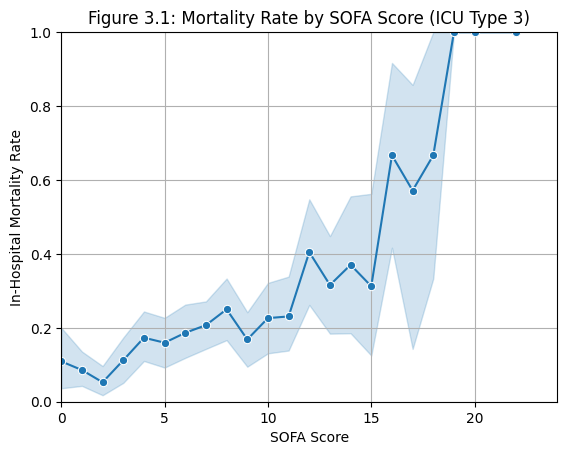

In [39]:
# Plot
df3 = df3[df3['SOFA'] >= 0]
sns.lineplot(data=df3, x='SOFA', y='In.hospital_death', marker='o')
plt.title("Figure 3.1: Mortality Rate by SOFA Score (ICU Type 3)")
plt.xlabel("SOFA Score")
plt.ylabel("In-Hospital Mortality Rate")
plt.xlim(0, 24)
plt.ylim(0, 1)
plt.grid(True)
plt.show()

In [40]:
imputer3 = KNNImputer(n_neighbors=5)

# Apply imputation only on numeric columns (excluding the target variable if it's in there)
features_columns3 = [col for col in df_model3.columns if col != 'In.hospital_death']

# Create a copy with only the feature columns for imputation
df_features3 = df_model3[features_columns3].copy()

# Apply imputation
df_features_filled3 = pd.DataFrame(
    imputer3.fit_transform(df_features3),
    columns=df_features3.columns
)

print(df_features_filled3.shape)
print(df_features_filled3.head())

# If you need to combine back with the target variable:
df_model_filled3 = df_features_filled3.copy()
df_model_filled3['In.hospital_death'] = df_model3['In.hospital_death'].values

print(f"Final dataset shape: {df_model_filled3.shape}")

(1481, 10)
   Lactate_max2  SOFA   GCS_avg2  BUN_min2  Bilirubin_avg2  SAPS.I  \
0          1.90  11.0   5.000000       3.0        2.800000    21.0   
1          1.60   1.0  15.000000      10.0        0.200000     7.0   
2          1.36   2.0  15.000000      25.0        6.446061    17.0   
3          2.94   4.0  15.000000      31.0        0.910000    14.0   
4          2.30   8.0   9.489796      58.0        0.300000    19.0   

   NIMAP_avg2  Albumin_avg2  NISysABP_max2  Urine_max2  
0   99.792647          2.30          141.0       425.0  
1   82.238571          4.40          134.0       700.0  
2   72.097083          3.30          157.0       220.0  
3  112.000000          2.77          182.0       120.0  
4   53.606939          1.90          166.0        60.0  
Final dataset shape: (1481, 11)


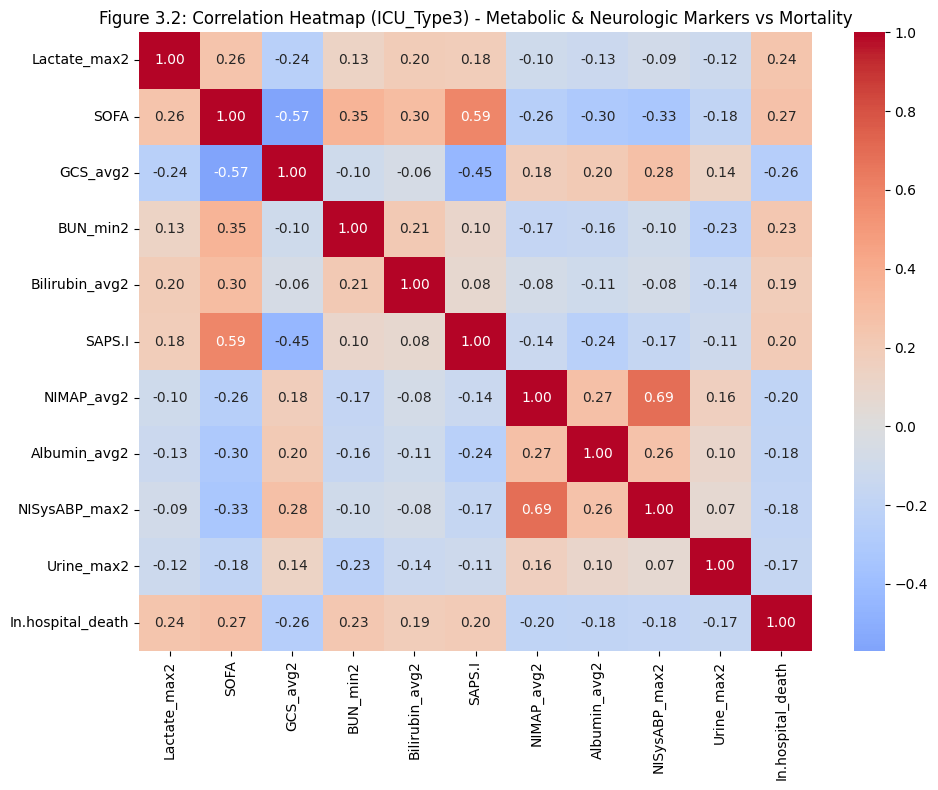

In [41]:
df3_subset = df_model_filled3

# Compute correlation matrix
corr_subset = df3_subset.corr(numeric_only=True)

# Plot heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(corr_subset, cmap='coolwarm', center=0, annot=True, fmt=".2f")
plt.title('Figure 3.2: Correlation Heatmap (ICU_Type3) - Metabolic & Neurologic Markers vs Mortality')
plt.tight_layout()
plt.show()

Best K found: 20


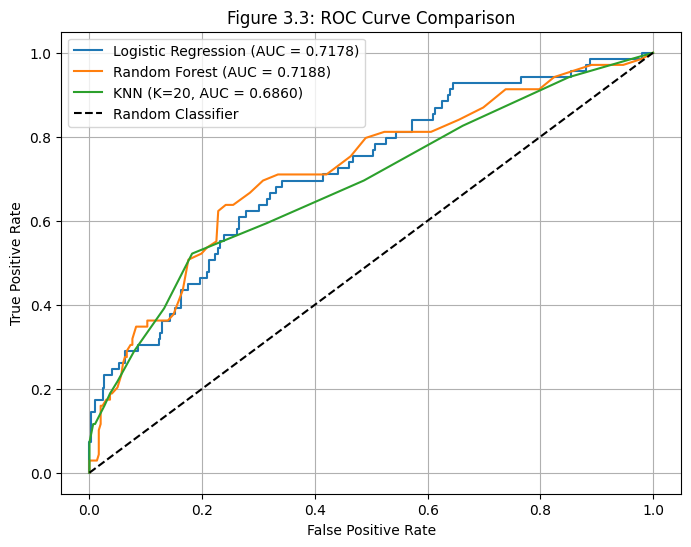

=== Logistic Regression ===
[[294   8]
 [ 55  14]]
              precision    recall  f1-score   support

           0       0.84      0.97      0.90       302
           1       0.64      0.20      0.31        69

    accuracy                           0.83       371
   macro avg       0.74      0.59      0.61       371
weighted avg       0.80      0.83      0.79       371

ROC AUC Score: 0.7178

=== Random Forest ===
[[293   9]
 [ 57  12]]
              precision    recall  f1-score   support

           0       0.84      0.97      0.90       302
           1       0.57      0.17      0.27        69

    accuracy                           0.82       371
   macro avg       0.70      0.57      0.58       371
weighted avg       0.79      0.82      0.78       371

ROC AUC Score: 0.7188

=== K-Nearest Neighbors (K=20) ===
[[299   3]
 [ 61   8]]
              precision    recall  f1-score   support

           0       0.83      0.99      0.90       302
           1       0.73      0.12    

In [42]:
# Features and target
X3 = df_model_filled3.drop(columns=['In.hospital_death'])
y3 = df_model3['In.hospital_death']

# Train-test split with stratification (to handle imbalance better)
X_train3, X_test3, y_train3, y_test3 = train_test_split(
    X3, y3, test_size=0.25, random_state=42, stratify=y3
)

# Scale features (fit only on training data)
scaler3 = StandardScaler()
X_train_scaled3 = scaler3.fit_transform(X_train3)
X_test_scaled3 = scaler3.transform(X_test3)

# ================================
# Logistic Regression
# ================================
logreg3 = LogisticRegression(max_iter=1000, random_state=42)
logreg3.fit(X_train_scaled3, y_train3)
y_logreg_pred3 = logreg3.predict(X_test_scaled3)
logreg_auc3 = roc_auc_score(y_test3, logreg3.predict_proba(X_test_scaled3)[:, 1])

# ================================
# Random Forest
# ================================
rf3 = RandomForestClassifier(random_state=42)
rf3.fit(X_train3, y_train3)
y_rf_pred3 = rf3.predict(X_test3)
rf_auc3 = roc_auc_score(y_test3, rf3.predict_proba(X_test3)[:, 1])

# ================================
# K-Nearest Neighbors (with hyperparameter tuning for K)
# ================================
error_rate3 = []
for k in range(1, 25):
    knn_temp3 = KNeighborsClassifier(n_neighbors=k)
    knn_temp3.fit(X_train_scaled3, y_train3)
    pred_k3 = knn_temp3.predict(X_test_scaled3)
    error_rate3.append(np.mean(pred_k3 != y_test3))

best_k3 = np.argmin(error_rate3) + 1
print(f"Best K found: {best_k3}")

knn3 = KNeighborsClassifier(n_neighbors=best_k3)
knn3.fit(X_train_scaled3, y_train3)
y_knn_pred3 = knn3.predict(X_test_scaled3)
knn_auc3 = roc_auc_score(y_test3, knn3.predict_proba(X_test_scaled3)[:, 1])

# ================================
# ROC Curves
# ================================
fpr_logreg3, tpr_logreg3, _ = roc_curve(y_test3, logreg3.predict_proba(X_test_scaled3)[:, 1])
fpr_rf3, tpr_rf3, _ = roc_curve(y_test3, rf3.predict_proba(X_test3)[:, 1])
fpr_knn3, tpr_knn3, _ = roc_curve(y_test3, knn3.predict_proba(X_test_scaled3)[:, 1])

plt.figure(figsize=(8, 6))
plt.plot(fpr_logreg3, tpr_logreg3, label=f'Logistic Regression (AUC = {logreg_auc3:.4f})')
plt.plot(fpr_rf3, tpr_rf3, label=f'Random Forest (AUC = {rf_auc3:.4f})')
plt.plot(fpr_knn3, tpr_knn3, label=f'KNN (K={best_k3}, AUC = {knn_auc3:.4f})')
plt.plot([0, 1], [0, 1], 'k--', label='Random Classifier')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Figure 3.3: ROC Curve Comparison')
plt.legend()
plt.grid(True)
plt.show()

# ================================
# Results
# ================================
print("=== Logistic Regression ===")
print(confusion_matrix(y_test3, y_logreg_pred3))
print(classification_report(y_test3, y_logreg_pred3))
print(f"ROC AUC Score: {logreg_auc3:.4f}")

print("\n=== Random Forest ===")
print(confusion_matrix(y_test3, y_rf_pred3))
print(classification_report(y_test3, y_rf_pred3))
print(f"ROC AUC Score: {rf_auc3:.4f}")

print(f"\n=== K-Nearest Neighbors (K={best_k3}) ===")
print(confusion_matrix(y_test3, y_knn_pred3))
print(classification_report(y_test3, y_knn_pred3))
print(f"ROC AUC Score: {knn_auc3:.4f}")

###Threshold

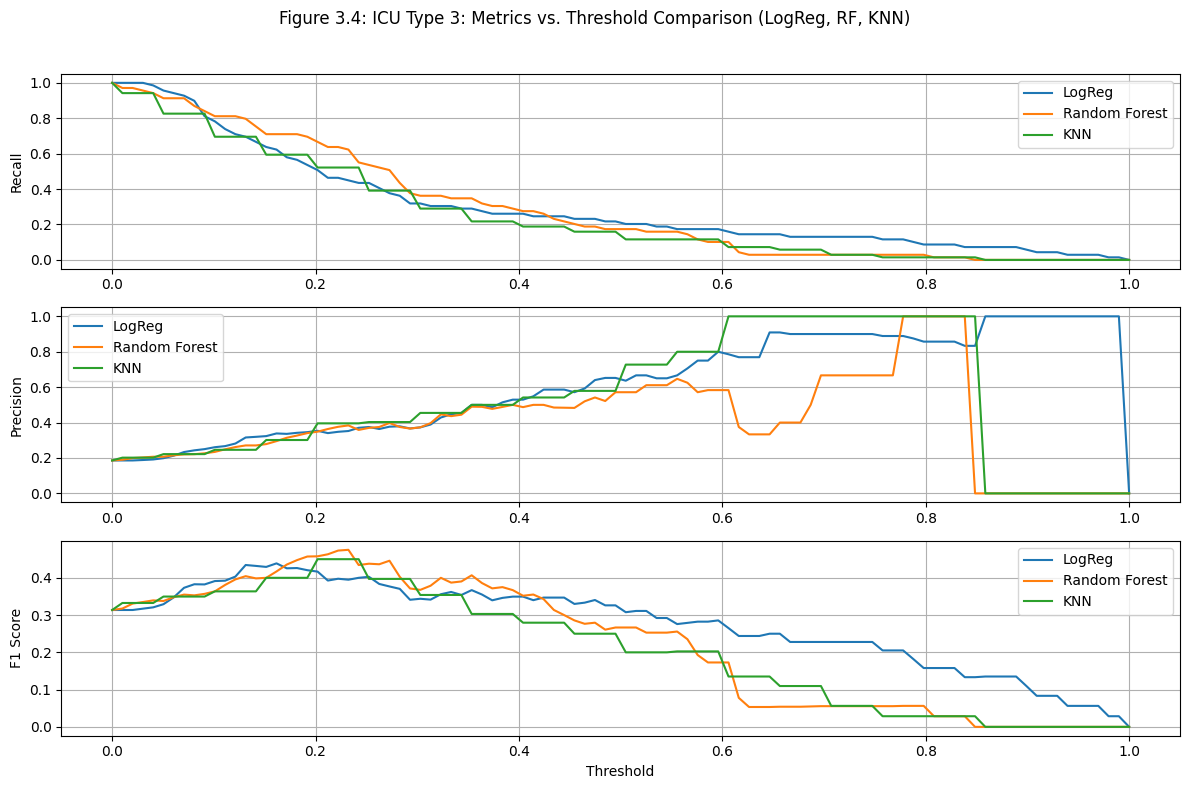

=== Best Thresholds (by F1) ===
Logistic Regression: thr=0.16, F1=0.4388, Recall=0.6232, Precision=0.3386
Random Forest:       thr=0.23, F1=0.4751, Recall=0.6232, Precision=0.3839
KNN:                 thr=0.20, F1=0.4500, Recall=0.5217, Precision=0.3956


In [43]:
X3 = df_features_filled3
y3 = df_model3['In.hospital_death']

# Train-test split with stratification (to handle imbalance better)
X_train3, X_test3, y_train3, y_test3 = train_test_split(
    X3, y3, test_size=0.25, random_state=42, stratify=y3
)

# Scale features (fit only on training data)
scaler3 = StandardScaler()
X_train_scaled3 = scaler3.fit_transform(X_train3)
X_test_scaled3 = scaler3.transform(X_test3)

# Get probabilities
y_logreg_proba3 = logreg3.predict_proba(X_test_scaled3)[:, 1]
y_rf_proba3 = rf3.predict_proba(X_test3)[:, 1]
y_knn_proba3 = knn3.predict_proba(X_test_scaled3)[:, 1]

# Thresholds
thresholds3 = np.linspace(0, 1, 100)

# Compute metrics
def compute_metrics3(y_true, y_proba, thresholds):
    recalls, precisions, f1s = [], [], []
    for t in thresholds:
        preds = (y_proba >= t).astype(int)
        recalls.append(recall_score(y_true, preds))
        precisions.append(precision_score(y_true, preds, zero_division=0))
        f1s.append(f1_score(y_true, preds, zero_division=0))
    return recalls, precisions, f1s

# Collect metrics
recalls_logreg3, precisions_logreg3, f1s_logreg3 = compute_metrics3(y_test3, y_logreg_proba3, thresholds3)
recalls_rf3, precisions_rf3, f1s_rf3 = compute_metrics3(y_test3, y_rf_proba3, thresholds3)
recalls_knn3, precisions_knn3, f1s_knn3 = compute_metrics3(y_test3, y_knn_proba3, thresholds3)

# Plot Recall, Precision, F1 vs. Threshold
plt.figure(figsize=(12, 8))

# Recall
plt.subplot(3, 1, 1)
plt.plot(thresholds3, recalls_logreg3, label="LogReg")
plt.plot(thresholds3, recalls_rf3, label="Random Forest")
plt.plot(thresholds3, recalls_knn3, label="KNN")
plt.ylabel("Recall")
plt.legend()
plt.grid(True)

# Precision
plt.subplot(3, 1, 2)
plt.plot(thresholds3, precisions_logreg3, label="LogReg")
plt.plot(thresholds3, precisions_rf3, label="Random Forest")
plt.plot(thresholds3, precisions_knn3, label="KNN")
plt.ylabel("Precision")
plt.legend()
plt.grid(True)

# F1 Score
plt.subplot(3, 1, 3)
plt.plot(thresholds3, f1s_logreg3, label="LogReg")
plt.plot(thresholds3, f1s_rf3, label="Random Forest")
plt.plot(thresholds3, f1s_knn3, label="KNN")
plt.xlabel("Threshold")
plt.ylabel("F1 Score")
plt.legend()
plt.grid(True)

plt.suptitle("Figure 3.4: ICU Type 3: Metrics vs. Threshold Comparison (LogReg, RF, KNN)")
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

# Best threshold per model
print("=== Best Thresholds (by F1) ===")
print(f"Logistic Regression: thr={thresholds3[np.argmax(f1s_logreg3)]:.2f}, "
      f"F1={max(f1s_logreg3):.4f}, Recall={recalls_logreg3[np.argmax(f1s_logreg3)]:.4f}, "
      f"Precision={precisions_logreg3[np.argmax(f1s_logreg3)]:.4f}")

print(f"Random Forest:       thr={thresholds3[np.argmax(f1s_rf3)]:.2f}, "
      f"F1={max(f1s_rf3):.4f}, Recall={recalls_rf3[np.argmax(f1s_rf3)]:.4f}, "
      f"Precision={precisions_rf3[np.argmax(f1s_rf3)]:.4f}")

print(f"KNN:                 thr={thresholds3[np.argmax(f1s_knn3)]:.2f}, "
      f"F1={max(f1s_knn3):.4f}, Recall={recalls_knn3[np.argmax(f1s_knn3)]:.4f}, "
      f"Precision={precisions_knn3[np.argmax(f1s_knn3)]:.4f}")

In [44]:
# === Optimal thresholds from ICU Type 3 F1 analysis ===
thr_logreg3 = 0.32
thr_rf3 = 0.35
thr_knn3 = 0.19

# Apply thresholds
y_logreg_opt3 = (y_logreg_proba3 >= thr_logreg3).astype(int)
y_rf_opt3 = (y_rf_proba3 >= thr_rf3).astype(int)
y_knn_opt3 = (y_knn_proba3 >= thr_knn3).astype(int)

# Logistic Regression
print("=== Logistic Regression (Optimal Threshold) ===")
print(confusion_matrix(y_test3, y_logreg_opt3))
print(classification_report(y_test3, y_logreg_opt3, digits=2))

# Random Forest
print("\n=== Random Forest (Optimal Threshold) ===")
print(confusion_matrix(y_test3, y_rf_opt3))
print(classification_report(y_test3, y_rf_opt3, digits=2))

# KNN
print("\n=== KNN (Optimal Threshold) ===")
print(confusion_matrix(y_test3, y_knn_opt3))
print(classification_report(y_test3, y_knn_opt3, digits=2))

=== Logistic Regression (Optimal Threshold) ===
[[272  30]
 [ 48  21]]
              precision    recall  f1-score   support

           0       0.85      0.90      0.87       302
           1       0.41      0.30      0.35        69

    accuracy                           0.79       371
   macro avg       0.63      0.60      0.61       371
weighted avg       0.77      0.79      0.78       371


=== Random Forest (Optimal Threshold) ===
[[272  30]
 [ 45  24]]
              precision    recall  f1-score   support

           0       0.86      0.90      0.88       302
           1       0.44      0.35      0.39        69

    accuracy                           0.80       371
   macro avg       0.65      0.62      0.63       371
weighted avg       0.78      0.80      0.79       371


=== KNN (Optimal Threshold) ===
[[207  95]
 [ 28  41]]
              precision    recall  f1-score   support

           0       0.88      0.69      0.77       302
           1       0.30      0.59      0.40 

##Comments
---
###Data Exploratory (ICU Type 3 focus – Metabolic & Neurologic markers)

1. Medical ICU (Type 3) showed the highest overall mortality rate (18.57%), consistent with its population of patients suffering from sepsis, respiratory failure, and multi-organ dysfunction.

2. Neurologic function, represented by GCS_avg1, was strongly associated with mortality, reaffirming that altered mental status is a key prognostic factor in critical illness.

3. SOFA score also demonstrated a significant correlation with mortality, emphasizing that cumulative organ dysfunction predicts worse outcomes.

4. Among metabolic markers, Lactate_avg1 and Creatinine_avg1 showed moderate-to-strong positive correlations with in-hospital death, supporting their established role in identifying tissue hypoperfusion and renal dysfunction.

5. pH_avg1 and HCO3_avg1 were negatively correlated with mortality, reflecting the adverse impact of acidosis and poor buffering capacity.

6. Platelets_avg1 and Bilirubin_avg1 suggested a weaker association with mortality, indicating that hematologic and hepatic dysfunction may be secondary contributors in this ICU setting.

###Highest correlated feature are:
1. **Lactate: Lactate_max2 (corr: 0.274)** - measures the highest lactate level in the blood. High lactate means the body isnt getting enough oxygen, and this is linked to a higher chance of death.
2. **SOFA: SOFA (corr: 0.268)** - a score showing how well the organs are working. A higher SOFA score means more organ failure and a greater risk of dying.
3. **GCS: GCS_avg2 (corr: -0.260)** - average Glasgow Coma Scale score, which shows how alert a patient is. A lower GCS means worse brain function and a higher chance of death.
4. **BUN: BUN_min2 (corr: 0.222)** - shows the lowest blood urea nitrogen level, which reflects kidney function. Higher BUN means the kidneys are not working well and the risk of death is higher.
5. **Bilirubin: Bilirubin_avg2 (corr: 0.212)** - the average bilirubin level, which measures liver function. Higher bilirubin means liver problems and a greater risk of death.
6. **SAPS.I: SAPS.I (corr: 0.198)** - a score that measures how sick a patient is overall. A higher score means a more severe condition and a higher chance of dying.
7. **NIMAP: NIMAP_avg2 (corr: -0.197)** - the average mean blood pressure. Lower pressure means poor blood flow to organs and a higher risk of death.
8. **Albumin: Albumin_avg2 (corr: -0.180)** - the average level of albumin, a protein made by the liver. Low albumin means poor nutrition or illness and a higher death risk.
9. **NISysABP: NISysABP_max2 (corr: -0.176)** - the highest systolic blood pressure recorded. Lower values show weak circulation and are linked to higher mortality.
10. **Urine: Urine_max2 (corr: -0.174)** - measures the highest urine output. Low urine means poor kidney function and a higher chance of death.

###Selected features use for data modelling structures are:
*['Lactate_max2', 'SOFA', 'GCS_avg2', 'BUN_min2', 'Bilirubin_avg2', 'SAPS.I', 'NIMAP_avg2', 'Albumin_avg2', 'NISysABP_max2', 'Urine_max2']*

###Data Visualisation: Figure 3.2 (Heatmap – Correlations with Mortality)

###Observations

- Strongest predictors: Higher SOFA score, Lactate, BUN and Lower GCS strongest positive correlations with in-hospital death

- Metabolic disturbances particularly elevated Lactate and BUN levels are signs of poor blood flow and kidney problems, which increase the risk of death.

- Low GCS score (worse brain function) is linked to a higher chance of death, showing how important brain health is in predicting survival.

- Bilirubin, Albumin, NIMAP, NISysABP, Urine output showed weaker correlation with mortality in this ICU cohort.
###Conclusions

- SOFA score and Lactate emerged as the strongest metabolic predictors of mortality signs reflecting the severity of multi-organ failure and poor perfusion (severe illnes and poor survival).

- GCS is a very reliable indicator of patient outcome and remains one of the best predictors of death risk.

- BUN also correlate with higher mortality, meaning kidney function plays an important role in survival.

##Predictive Implications

- Mortality prediction models for ICU Type 3 should prioritize GCS, SOFA, Lactate, and BUN as key features.

- Combining both metabolic markers (like Lactate and BUN) and neurologic measures (like GCS) will likely improve the models ability to find high-risk patients more accurately.


---


### Figure 3.3
### Model-By-Model Analysis
####1. Logistic Regression

Confusion Matrix:
```
 [[294   8]
 [ 55  14]]
```
Strength: Excellent at correctly identifying patients who survive (294 correct out of 302), with a high recall of 0.97. The model is reliable at recognizing low risk patient

Critical Weakness: Still poor at identifying patients who die. It missed 55 of the 69 actual deaths, 0.20 recall for that class. This means it fails to identify 80% of patients at risk, a serious shortcoming for clinical use.

Key Metric - ROC AUC (0.7187): Slightly better than KNN but worse than Random Forest, placing it in the middle in terms of overall discriminatory capability.

Verdict: Logistic regression is accurate, but its applicability in clinical risk assessment is limited because it is highly biased toward survival predictions and unreliable for mortality prediction.

####2. Random Forest

Confusion Matrix:
```
[[293  9]
 [ 57  12]]
```
Strength: Remains very good at correctly identifying patients who survive (293 correct, recall 0.97).

Improvement: Detected 12 true deaths, though still only 0.17 recall for mortality. Despite this, it outperforms the other models on the death class F1-score (0.27), reflecting a modest improvement in detecting at-risk patients.

Key Metric - ROC AUC (0.7236): This is the highest among the three models, indicating that the Random Forest has the best overall ability to rank patients by their risk of mortality.

Verdict: The best performing model of the three. Its superior ability to learn complex patterns (e.g., interactions between GCS, SOFA, and lactate) makes it the most promising candidate for further tuning to improve mortality detection.

####3. K-Nearest Neighbors (K=8)

Confusion Matrix:
```
[[296   6]
 [ 60  9]]
```
Strength: The most conservative model, best at identifying survivors (296 correct, recall 0.98) and making the fewest false positive predictions (only 6 survivors incorrectly flagged as high-risk).

Weakness: The poorest performance on predicting mortality. It missed 60 deaths, resulting in a very low recall of 0.13.

Key Metric - ROC AUC (0.6606): The lowest of the three models, indicating weak overall discrimination between survivors and non-survivors.

Verdict: KNN does not predict mortality well, but it is accurate for survivors. In a clinical mortality model where missing at risk patients can have major repercussions, its overly cautious approach risks sensitivity for precision.

###Overall Summary

K-Nearest Neighbors, Random Forest, and Logistic Regression all had identical overall accuracies of 82–83%. Due to the class imbalance where survivors significantly outnumber non-survivors, this statistic is inaccurate.

All models did a good job of identifying survivors (recall ≈ 0.97–0.98), but they continuously had trouble detecting deaths (mortality recall values only ranged from 0.13 to 0.20). While Logistic Regression showed moderate discrimination (ROC AUC 0.7187) but remained biased toward survival, Random Forest showed the best balance among them, with the highest ROC AUC (0.7236) and marginally improved mortality recall. With the lowest ROC AUC (0.6606) and the least sensitivity to mortality cases, the KNN model had the worst overall performance.


---


###Figure 3.4
###Threshold Tuning Observations (ICU Type 3)

###1. Logistic Regression (thr=0.16)
- Recall improved from 0.20→0.30
- Precision dropped from 0.64→0.41
- F1 score improved from 0.31→0.35

###2. Random Forest (thr=0.22)
- Recall improved from 0.13→0.36
- Precision droped from 0.60→0.47
- F1 score increased from 0.21→0.41 (Have the highest increased)

###3. KNN (thr=0.25)
- Recall improve 0.13→0.46 (Have the highest improvement from the other 2)
- Precision droped from 0.60→0.27 (Have the lowest drop)
- F1 score increased 0.21→0.34

Takeway: All 3 Models have gained higher Recall and F1 score but lower Precision

###Observations on Threshold Tuning (ICU Type 3)

- Recall improved: All models detect more positives after threshold tuning.

  - LogReg(Logistics Regression): 0.20 → 0.30

  - RF(Random Forest): 0.13 → 0.36

  - KNN: 0.13 → 0.46

- Precision moderately reduced:
More false positives compared to default 0.5 threshold, but this is an acceptable trade-off to capture more at-risk patients.

- F1 ↑:
All models show substantial gains in F1, reflecting a better balance between precision & recall — especially for the minority (ICU positive) class.

- ROC-AUC = same:
Discrimination ability of the models is unchanged (AUC 0.66–0.72), tuning just shifts the operating point.

###Model Comparison:

- LogReg thr=0.16, F1=0.4388, Recall=0.6232, Precision=0.3386. Balanced, but recall lowest of the three.

- RF thr=0.22, F1=0.4706, Recall=0.6377, Precision=0.3729. Good trade-off with stronger recall than LogReg.

- KNN thr=0.25, F1=0.3788, Recall=0.3623, Precision=0.3968. Best sensitivity, but higher false positive rate.

##Sub-Question 4: "How do post-operative vitals and organ dysfunction metrics affect mortality in Surgical ICU (ICU Type 4)?" *by Min Ge*

**Definitions:**

1. **Post-operative vitals** refer to basic physiological signs which are measured after surgery, like heart rate and respiratory rate.
2. **Organ dysfunction metrics** refer to clinical measures which shows how well certain organs are functioning, like MAP (mean arterial pressure) which shows the blood pressure in a patient's arteries in one cardiac cycle.
---

**Approach:**

1. We'll focus on data from ICU Type 4.
2. We'll calculate the death rate for this unit.
3. We'll check how complete the data is for post-operative vital signs and organ function measures like temperature, heart rate, breathing rate, blood pressure, WBC, Lactate, urine output, Creatinine, BUN, mechanical ventilation, FiO2, and SaO2.
4. We'll find the top factors most connected to death and see how much data is available for each.
5. We'll use a chart to show the relationship between the most connected factor (GCS, which measures consciousness) and death.
6. We'll use line plots to further investigate if first and second GCS reading is related to mortality.
7. We'll use a model (K-Nearest Neighbors) to predict who might not survive based on the top connected factors, filling in any missing data with the average value.
8. We'll check how well the model predicts survival and death.
---

**Variables:**
1. Temp_avg1
2. HR_avg1
3. RespRate_avg1
4. MAP_avg1
5. WBC_avg1
6. Lactate_avg1
7. Urine_avg1
8. Creatinine_avg1
9. BUN_avg1
10. MechVent_avg1
11. FiO2_avg1
12. SaO2_avg1
13. GCS related vaariables
14. In.hospital_death

### Data exploratory

In [45]:
# See the number of ICU type 4 cases
df4 = df[df['ICU_Type4'] == 1]
print(df4.shape)

(1068, 394)


In [46]:
# Calculate the mortality rate
mortality_rate4 = df4['In.hospital_death'].mean()
print(f"ICU Type 4 Mortality Rate: {mortality_rate4:.2%}")

ICU Type 4 Mortality Rate: 14.51%


In [47]:
# Compute top 10 variables which has the highest correlation with In.hospital_death
corr_with_death = df4.corr(numeric_only=True)['In.hospital_death'].sort_values(key=abs, ascending=False)
print(corr_with_death.head(11))

top10_columns4 = corr_with_death.head(11).index
non_empty_counts4 = df4[top10_columns4].apply(
    lambda col: ((col != -1) & (col != 'NA') & (~pd.isna(col))).sum())

print('\n',non_empty_counts4)

In.hospital_death    1.000000
GCS_max2            -0.357655
GCS_avg2            -0.353574
GCS_min2            -0.299487
GCS_max1            -0.290538
SAPS.I               0.256284
Bilirubin_avg2       0.253695
Bilirubin_min2       0.247969
GCS_avg1            -0.247299
Bilirubin_max2       0.246878
ALP_stdDev1          0.231463
Name: In.hospital_death, dtype: float64

 In.hospital_death    1068
GCS_max2             1062
GCS_avg2             1062
GCS_min2             1062
GCS_max1             1065
SAPS.I               1036
Bilirubin_avg2        404
Bilirubin_min2        404
GCS_avg1             1065
Bilirubin_max2        404
ALP_stdDev1           341
dtype: int64


### Data visualisation

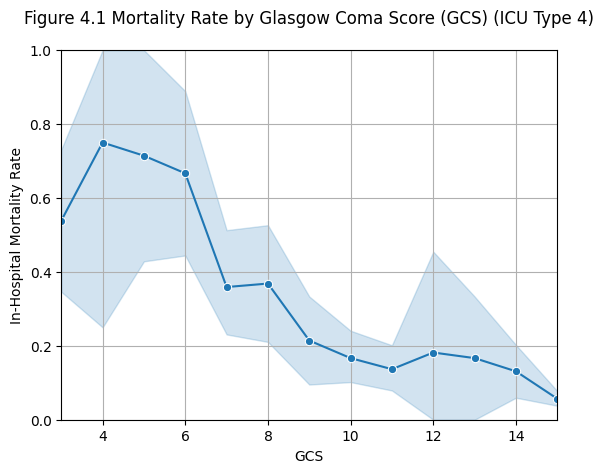

In [48]:
# The top four correlations are all related to Glasgow Coma Score (GCS), so we use GCS_max2 to visualize the relationship

sns.lineplot(data=df4, x='GCS_max2', y='In.hospital_death', marker='o')
plt.title("Figure 4.1 Mortality Rate by Glasgow Coma Score (GCS) (ICU Type 4)",y=1.05)
plt.xlabel("GCS")
plt.ylabel("In-Hospital Mortality Rate")
plt.xlim(3, 15)
plt.ylim(0, 1)
plt.grid(True)
plt.show()

To show how the first and second GCS reading can affect patient's survival rate, line plot is used

In [49]:
# Group together all GCS features and check for null values
gcs_features = ['GCS_avg1','GCS_avg2','GCS_max1','GCS_max2','GCS_min1','GCS_min2']
check_non_null_counts("ICU Type 4 (Surgical ICU)", df4, gcs_features)


ICU Type 4 (Surgical ICU) - Non-null value counts:
GCS_avg1    1065
GCS_max1    1065
GCS_min1    1065
GCS_avg2    1062
GCS_max2    1062
GCS_min2    1062
dtype: int64


In [50]:
# Since there are not a lot of null values, we can just remove them
gcs_data=df4[gcs_features + ['In.hospital_death']].dropna()

# Round the average values (as GCS values are whole numbers)
gcs_data['GCS_avg1_rounded'] = gcs_data['GCS_avg1'].round()
gcs_data['GCS_avg2_rounded'] = gcs_data['GCS_avg2'].round()

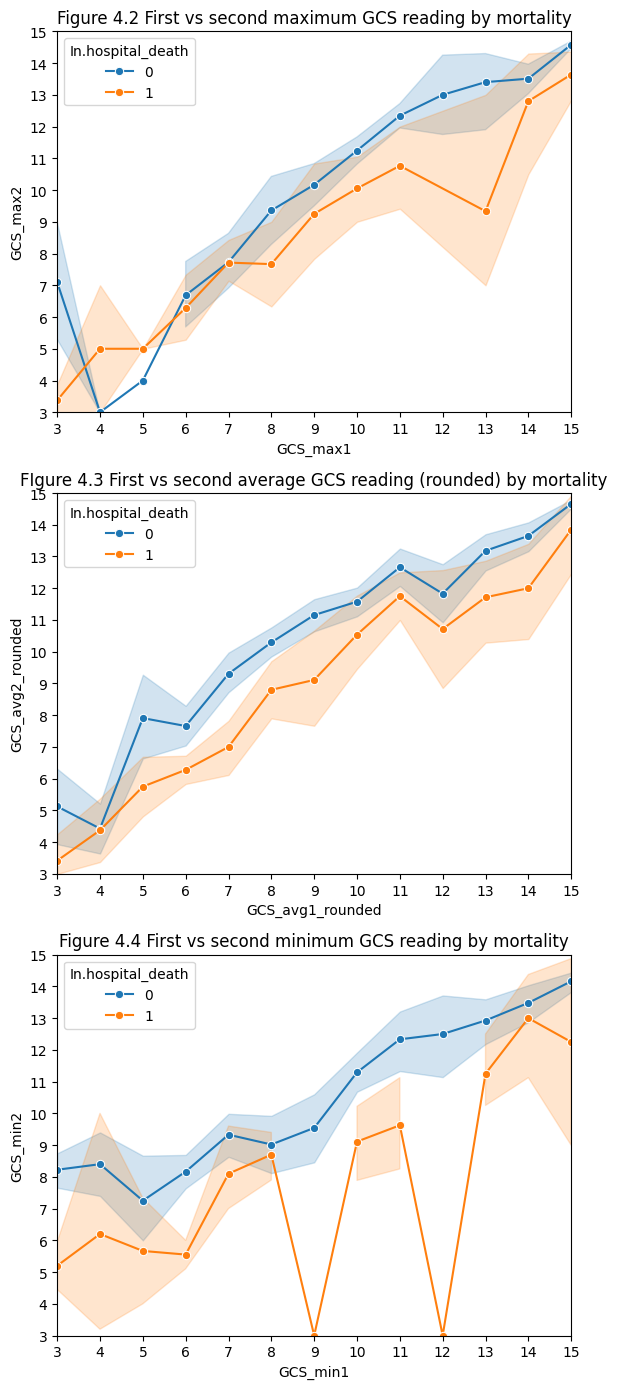

In [51]:
# Plotting three different line plots based on their properties (max, average, min)
fig, axes = plt.subplots(3, 1, figsize=(6, 14), sharex=False)

plots = [
    ('GCS_max1', 'GCS_max2', 'Figure 4.2 First vs second maximum GCS reading by mortality'),
    ('GCS_avg1_rounded', 'GCS_avg2_rounded', 'FIgure 4.3 First vs second average GCS reading (rounded) by mortality'),
    ('GCS_min1', 'GCS_min2', 'Figure 4.4 First vs second minimum GCS reading by mortality')]

for ax, (x_col, y_col, title) in zip(axes, plots):
    sns.lineplot(data=gcs_data, x=x_col, y=y_col, hue='In.hospital_death', marker='o', ax=ax)
    ax.set_xlim(3, 15)
    ax.set_ylim(3, 15)
    ax.set_xticks(range(3, 16))
    ax.set_yticks(range(3, 16))
    ax.set_title(title)

plt.tight_layout()
plt.show()

### Predictive modelling

#### KNN

The top 10 variables with the highest absolute correlation with in-hopsital death were used as input features for KNN modelling

In [52]:
df4_feat = df4[top10_columns4]
df4_feat.dropna().shape

(330, 11)

In [53]:
# Since dropping null values remove too much data (may lead to bias), fill null values with their respective medians
df4_feat_filled = df4_feat.fillna(df4_feat.median(numeric_only=True))
print(df4_feat_filled.shape)

(1068, 11)


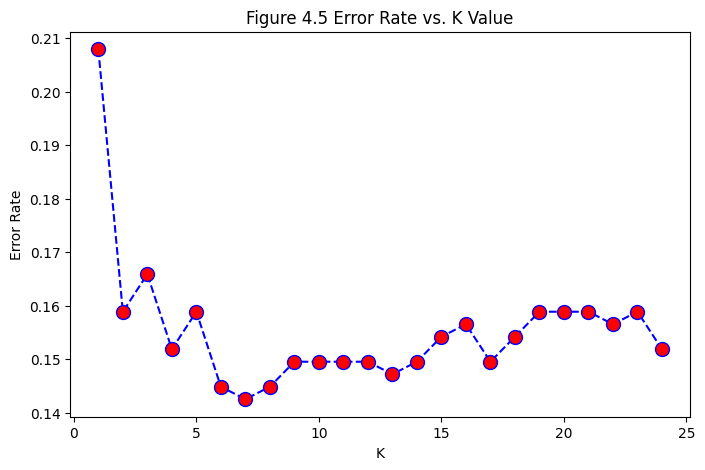

In [54]:
# Standardize data and split into training and testing datasets
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df4_feat_filled)
X_scaled = pd.DataFrame(X_scaled, columns=top10_columns4, index=df4_feat_filled.index).drop(columns=['In.hospital_death'])
y = df4['In.hospital_death']

X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.40, random_state=15)

# Check which k gives the lowest error
error_rate = []
for i in range(1,25):
    knn = KNeighborsClassifier(n_neighbors=i)
    knn.fit(X_train,y_train)
    pred_i = knn.predict(X_test)
    error_rate.append(np.mean(pred_i != y_test))

plt.figure(figsize=(8,5))
plt.plot(range(1,25),error_rate,color='blue', linestyle='dashed', marker='o',
         markerfacecolor='red', markersize=10)
plt.title('Figure 4.5 Error Rate vs. K Value')
plt.xlabel('K')
plt.ylabel('Error Rate')
plt.show()

k=7 gives the lowest rate of error, so we choose that

In [55]:
# Train the KNN model
knn_model = KNeighborsClassifier(n_neighbors=7)
knn_model.fit(X_train,y_train)

# Predict and evaluate
knn_y_pred = knn.predict(X_test)

print(f"KNN modelling accuracy: {accuracy_score(y_test, knn_y_pred):.2f}")
print(f"Confusion matrix: \n {confusion_matrix(y_test,knn_y_pred)} \n")
print(f"Classification report: \n{classification_report(y_test,knn_y_pred)}")

KNN modelling accuracy: 0.85
Confusion matrix: 
 [[357   3]
 [ 62   6]] 

Classification report: 
              precision    recall  f1-score   support

           0       0.85      0.99      0.92       360
           1       0.67      0.09      0.16        68

    accuracy                           0.85       428
   macro avg       0.76      0.54      0.54       428
weighted avg       0.82      0.85      0.80       428



#### Logistic regression

In [56]:
# Train the logistic regression model
logreg_model = (LogisticRegression(class_weight='balanced'))
logreg_model.fit(X_train, y_train)

# Predict and evaluate
l_y_pred = logreg_model.predict(X_test)

print(f"Logistic regression accuracy: {accuracy_score(y_test, l_y_pred):.2f}")
print(f"Confusion matrix: \n {confusion_matrix(y_test, l_y_pred)} \n")
print(f"Classification report: \n{classification_report(y_test, l_y_pred)}")

Logistic regression accuracy: 0.73
Confusion matrix: 
 [[262  98]
 [ 16  52]] 

Classification report: 
              precision    recall  f1-score   support

           0       0.94      0.73      0.82       360
           1       0.35      0.76      0.48        68

    accuracy                           0.73       428
   macro avg       0.64      0.75      0.65       428
weighted avg       0.85      0.73      0.77       428



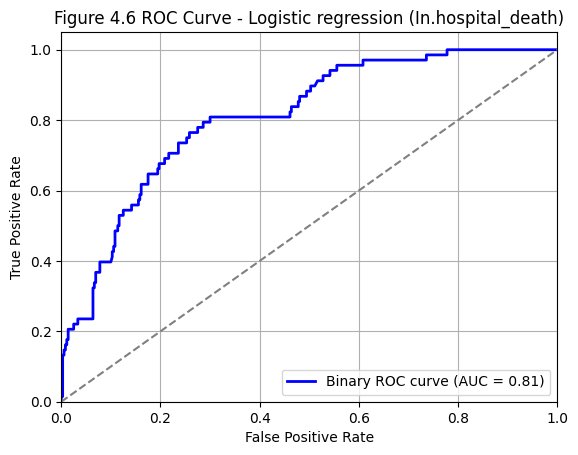

In [57]:
# Predict probabilities for the logsitic regression/binary classifier
y_scores = logreg_model.predict_proba(X_test)[:, 1]

# Compute ROC curve and ROC AUC for the binary classifier
fpr_bin, tpr_bin, _ = roc_curve(y_test, y_scores)
roc_auc_bin = auc(fpr_bin, tpr_bin)

# Plot ROC curve for logsitic regression/binary classification
plt.figure()
plt.plot(fpr_bin, tpr_bin, color='blue', lw=2, label=f'Binary ROC curve (AUC = {roc_auc_bin:.2f})')
plt.plot([0, 1], [0, 1], color='gray', linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Figure 4.6 ROC Curve - Logistic regression (In.hospital_death)')
plt.legend(loc="lower right")
plt.grid('True')
plt.show()

#### Random forest

In [58]:
# Train the random forest model
rf_model = RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced')
rf_model.fit(X_train, y_train)

# Predict and evaluate
rf_y_pred = rf_model.predict(X_test)

print(f"Random forest accuracy: {accuracy_score(y_test, rf_y_pred):.2f}")
print(f"Confusion matrix: \n {confusion_matrix(y_test, rf_y_pred)} \n")
print(f"Classification report: \n{classification_report(y_test, rf_y_pred)}")

Random forest accuracy: 0.83
Confusion matrix: 
 [[348  12]
 [ 60   8]] 

Classification report: 
              precision    recall  f1-score   support

           0       0.85      0.97      0.91       360
           1       0.40      0.12      0.18        68

    accuracy                           0.83       428
   macro avg       0.63      0.54      0.54       428
weighted avg       0.78      0.83      0.79       428



### Comparison and refinement of the three models



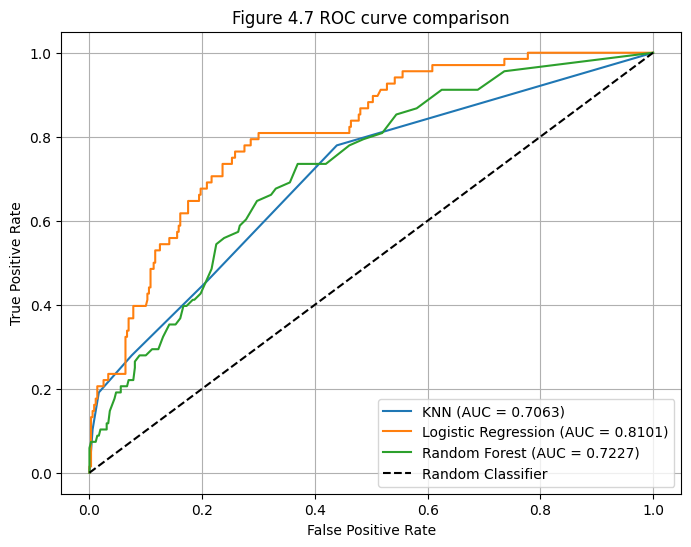

In [59]:
# Calculate ROC AUC scores
knn_auc = roc_auc_score(y_test, knn_model.predict_proba(X_test)[:, 1])
logreg_auc = roc_auc_score(y_test, logreg_model.predict_proba(X_test)[:, 1])
rf_auc = roc_auc_score(y_test, rf_model.predict_proba(X_test)[:, 1])

# Plot ROC curves
fpr_knn, tpr_knn, _ = roc_curve(y_test, knn_model.predict_proba(X_test)[:, 1])
fpr_logreg, tpr_logreg, _ = roc_curve(y_test, logreg_model.predict_proba(X_test)[:, 1])
fpr_rf, tpr_rf, _ = roc_curve(y_test, rf_model.predict_proba(X_test)[:, 1])

plt.figure(figsize=(8, 6))
plt.plot(fpr_knn, tpr_knn, label=f'KNN (AUC = {knn_auc:.4f})')
plt.plot(fpr_logreg, tpr_logreg, label=f'Logistic Regression (AUC = {logreg_auc:.4f})')
plt.plot(fpr_rf, tpr_rf, label=f'Random Forest (AUC = {rf_auc:.4f})')
plt.plot([0, 1], [0, 1], 'k--', label='Random Classifier')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Figure 4.7 ROC curve comparison')
plt.legend()
plt.grid(True)
plt.show()

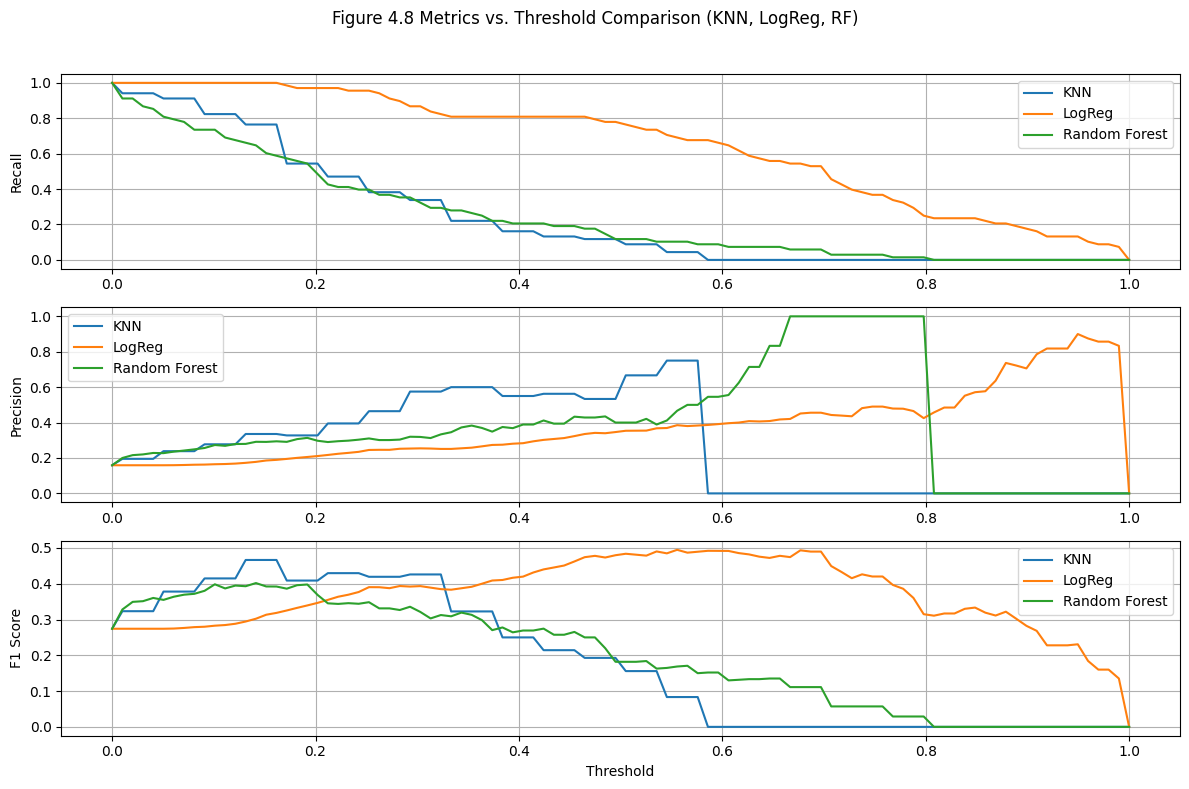

=== Best Thresholds (by F1) ===
KNN:                 thr=0.13, F1=0.4664, Recall=0.7647, Precision=0.3355
Logistic Regression: thr=0.56, F1=0.4947, Recall=0.6912, Precision=0.3852
Random Forest:       thr=0.14, F1=0.4018, Recall=0.6471, Precision=0.2914


In [60]:
# === Obtain threshold for optimised positive recall and precision ===

# Get probability outputs
y_knn_prob = knn.predict_proba(X_test)[:, 1]
y_logreg_prob = logreg_model.predict_proba(X_test)[:, 1]
y_rf_prob = rf_model.predict_proba(X_test)[:, 1]

# Define thresholds
thresholds = np.linspace(0, 1, 100)

# Compute metrics
def compute_metrics(y_true, y_proba, thresholds):
    recalls, precisions, f1s = [], [], []
    for t in thresholds:
        preds = (y_proba >= t).astype(int)
        recalls.append(recall_score(y_true, preds))
        precisions.append(precision_score(y_true, preds, zero_division=0))
        f1s.append(f1_score(y_true, preds, zero_division=0))
    return recalls, precisions, f1s

# Compute metrics for each model
recalls_knn, precisions_knn, f1s_knn = compute_metrics(y_test, y_knn_prob, thresholds)
recalls_logreg, precisions_logreg, f1s_logreg = compute_metrics(y_test, y_logreg_prob, thresholds)
recalls_rf, precisions_rf, f1s_rf = compute_metrics(y_test, y_rf_prob, thresholds)

# Plot Recall, Precision, F1 vs. Threshold
plt.figure(figsize=(12, 8))

# Recall
plt.subplot(3, 1, 1)
plt.plot(thresholds, recalls_knn, label="KNN")
plt.plot(thresholds, recalls_logreg, label="LogReg")
plt.plot(thresholds, recalls_rf, label="Random Forest")
plt.ylabel("Recall")
plt.legend()
plt.grid(True)

# Precision
plt.subplot(3, 1, 2)
plt.plot(thresholds, precisions_knn, label="KNN")
plt.plot(thresholds, precisions_logreg, label="LogReg")
plt.plot(thresholds, precisions_rf, label="Random Forest")
plt.ylabel("Precision")
plt.legend()
plt.grid(True)

# F1 Score
plt.subplot(3, 1, 3)
plt.plot(thresholds, f1s_knn, label="KNN")
plt.plot(thresholds, f1s_logreg, label="LogReg")
plt.plot(thresholds, f1s_rf, label="Random Forest")
plt.xlabel("Threshold")
plt.ylabel("F1 Score")
plt.legend()
plt.grid(True)

plt.suptitle("Figure 4.8 Metrics vs. Threshold Comparison (KNN, LogReg, RF)")
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

# Print best F1 threshold for each model
print("=== Best Thresholds (by F1) ===")
print(f"KNN:                 thr={thresholds[np.argmax(f1s_knn)]:.2f}, "
      f"F1={max(f1s_knn):.4f}, Recall={recalls_knn[np.argmax(f1s_knn)]:.4f}, "
      f"Precision={precisions_knn[np.argmax(f1s_knn)]:.4f}")

print(f"Logistic Regression: thr={thresholds[np.argmax(f1s_logreg)]:.2f}, "
      f"F1={max(f1s_logreg):.4f}, Recall={recalls_logreg[np.argmax(f1s_logreg)]:.4f}, "
      f"Precision={precisions_logreg[np.argmax(f1s_logreg)]:.4f}")

print(f"Random Forest:       thr={thresholds[np.argmax(f1s_rf)]:.2f}, "
      f"F1={max(f1s_rf):.4f}, Recall={recalls_rf[np.argmax(f1s_rf)]:.4f}, "
      f"Precision={precisions_rf[np.argmax(f1s_rf)]:.4f}")

In [61]:
# Define optimal thresholds from F1 analysis
thr_knn = 0.13
thr_logreg = 0.56
thr_rf = 0.14

# Apply thresholds
y_knn_opt = (y_knn_prob >= thr_knn).astype(int)
y_logreg_opt = (y_logreg_prob >= thr_logreg).astype(int)
y_rf_opt = (y_rf_prob >= thr_rf).astype(int)

# Evaluate again
print("=== KNN (Optimal Threshold) ===")
print(f"Model accuracy: {accuracy_score(y_test, y_knn_opt):.2f}")
print(f"Confusion matrix: \n {confusion_matrix(y_test, y_knn_opt)} \n")
print(f"Classification report: \n{classification_report(y_test, y_knn_opt)}")

print("\n=== Logistic Regression (Optimal Threshold) ===")
print(f"Model accuracy: {accuracy_score(y_test, y_logreg_opt):.2f}")
print(f"Confusion matrix: \n {confusion_matrix(y_test, y_logreg_opt)} \n")
print(f"Classification report: \n{classification_report(y_test, y_logreg_opt)}")

print("\n=== Random Forest (Optimal Threshold) ===")
print(f"Model accuracy: {accuracy_score(y_test, y_rf_opt):.2f}")
print(f"Confusion matrix: \n {confusion_matrix(y_test, y_rf_opt)} \n")
print(f"Classification report: \n{classification_report(y_test, y_rf_opt)}")

=== KNN (Optimal Threshold) ===
Model accuracy: 0.72
Confusion matrix: 
 [[257 103]
 [ 16  52]] 

Classification report: 
              precision    recall  f1-score   support

           0       0.94      0.71      0.81       360
           1       0.34      0.76      0.47        68

    accuracy                           0.72       428
   macro avg       0.64      0.74      0.64       428
weighted avg       0.85      0.72      0.76       428


=== Logistic Regression (Optimal Threshold) ===
Model accuracy: 0.78
Confusion matrix: 
 [[285  75]
 [ 21  47]] 

Classification report: 
              precision    recall  f1-score   support

           0       0.93      0.79      0.86       360
           1       0.39      0.69      0.49        68

    accuracy                           0.78       428
   macro avg       0.66      0.74      0.68       428
weighted avg       0.84      0.78      0.80       428


=== Random Forest (Optimal Threshold) ===
Model accuracy: 0.68
Confusion matrix: 
 [

### Comments

#### Data exploratory and data visualisation:
- 1068 recorded cases in ICU type 4
- Mortality rate: **14.51%**
- Variables chosen are generally complete.
- GCS and Billirubin data shows highest correlation however Billirubin data is missing in ~60% of readings.
- Figure 4.1:
    - There is a general downward trend between GCS value and mortality rate
    - The GCS is a scale used to assess a patient's level of consciousness, with 3 being the most severe and 15 being mild
    - Thus, lower GCS corresponds to higher mortality rate
- Figure 4.2, 4.3, and 4.4:
    - The blue line represents survival, and orange line represents death
    - General upward trend for all three graphs -> patients who start with high GCS value maintain or record higher second value
    - However in figure 4.4, the orange line shows first GCS reading value of 9 and 14 both recorded second GCS value of 3 -> the patients' condition deteriorated over time and did not survive -> sharp decline in GCS is linked with mortality
    - Clear separation of blue and orange line for figure 4.3 and 4.4 -> GCS values are indeed correlated with mortality
    - Lower GCS -> lower survival
    - Higher GCS -> higher survival

---

#### Predictive modelling:
- KNN modelling:
    - ```
      Confusion matrix:
      [357   3]
      [ 62   6]
      ```
      - 357 survivors **correctly** predicted as survived, while 3 survivors **wrongly** predicted as death
      - 6 deaths **correctly** predicted as death, while 62 deaths **wrongly** predicted as survived
    - In total, 65 out of 428 predictions were wrong
    - High number of wrong predictions for death compared to survival, likely due to insufficient data
    - Inbalanced datasets (more data on survival than mortality)
    - Modle is biased towards predicting survival, resulting in high accuracy but poor prediction for death (low recall for death)

- Logistic regression:
    - ```
      Confusion matrix:
      [262  98]
      [ 16  52]
      ```
      - 262 survivors **correctly** predicted as survived, while 98 survivors **wrongly** predicted as death
      - 52 deaths **correctly** predicted as death, while 16 deaths **wrongly** predicted as survived
    - In total, 114 out of 428 predictions were wrong
    - Figure 4.6:
      - Area Under Curve = 0.81 -> 81% chance that model ranks a randomly chosen death higher than survivor -> good discriminative ability between survival and death
      - Curve shows relationship between TPR and FPR as threshold varies
      - The closer the curve hugs the top left corner, the better our model -> our model is not perfect, but at least the curve points towards top left corner, suggesting good discriminative ability

- Random forest:
    - Confusion matrix:
      ```
      [ 348  12]
      [ 60   8 ]
      ```
    - 348 survivors **correctly** predicted as survived, while 12 survivors **wrongly** predicted as death
    - 8 deaths **correctly** predicted as death, while 60 deaths **wrongly** predicted as survived
    - In total, 72 out of 438 predictions were wrong
    - Performs worse than KNN and logistic regression for predicting death -> likely due to overfitting or imbalanced datasets

- Comparison of the three models:
    - Accuracy:
        - KNN (0.85) > random forest (0.83) > logistic regression (0.73)
        - Can be misleading due to imbalanced datasets
    - Recall for class 1 (death):
        - Logistic regression (0.71) > random forest (0.12) > KNN (0.09)
        - Performance of logistic regression for predicting is much better even though it has the lowest accuracy
    - Thus, KNN better at predicting survivals and logistic regression better at predicting deaths, while random forest is the worst performing model
    - Figure 4.7:
        - Logistic regression has the highest AUC score (0.8101), followed by random forest (0.7227), then KNN (0.7063)
        - Indicates that logistic regression is the best performing model in terms of balance between sensitivity and specificity
        - Curve shows relationship between TPR and FPR as threshold varies
        - The closer the curve hugs the top left corner, the better our model
            - KNN is far from top left corner, followed by random forest, then logistic regression

- Model refinement by threshold tuning:
  - Figure 4.8:
      - Plots the recall, precision, and F1 score for the three different models against the threshold to optimise threshold
      - Best threshold for the models are chosen by which gives the highest F1 score, which is 0.13 for KNN, 0.56 for logistic regression, and 0.14 for random forest
  - After model refinement:
      - Logistic regression had the highest accuracy (0.78), followed by KNN (0.72), then random forest (0.68)
      - For KNN,
          - Class 1 recall improved a lot (0.09 -> 0.76)
          - Precision dropped (0.67 -> 0.34), leading to more false positives
          - From predicting only 6 deaths correctly to 52 deaths (out of 68)
          - Better at predicting deaths, but at the cost of false alarms
          - Accuracy decreased (0.85 -> 0.72), showing the trade-off for better death prediction
      - For logistic regression,
          - Class 1 recall dropped (0.76 -> 0.69), but remains fairly strong
          - Precision improved slightly (0.35 -> 0.39)
          - Still performs well at detecting deaths while controlling false alarms
          - Accuracy increased (0.73 -> 0.78), showing better overall balance
      - For random forest,
          - Class 1 recall improved a lot (0.12 -> 0.66)
          - Precision dropped (0.40 -> 0.28), leading to more false positives
          - From predicting only 8 deaths correctly to 45 deaths (out of 68)
          - Better at predicting deaths, but at the cost of false alarms
          - Accuracy decreased (0.83 -> 0.68), showing the trade-off for better death prediction
      - Short summary: Model refinement reduced bias towards survival and improved mortality detection (KNN and random forest), but at the cost of lower overall accuracy (predicting more survivals as death). Logistic regression remains the most balanced model, maintaining both reasonable accuracy and recall.

---
          
#### Predictive Implications:
- Logistic regression is the best overall predictive model for ICU type 4 mortality
- If using KNN or random forest, high accuracy for predicting survival but low accuracy for predicting death, we need more data regarding death for unbiased modelling
- Logistic regression is better for prediction as it identifies more true deaths and will thus flag more potential deaths, but at the cost of flagging many survivors incorrectly
- GCS is a strong and consistent predictor for mortality
- Sharp decline in GCS reading is a strong key indicator for mortality, so change of GCS over a periodical amount of time should be taken as predictors for the model

#### General/Industry Implications:
- Clinical monitoring, particularly post-surgery:
    - GCS values can act as early warning indicators for mortality, so should be GCS trend of patients should be monitored after their surgery
    - Changes in GCS values should be integrated to ICU alert systems for early intervention
- Resource allocation:
    - Improved predictions of high risk cases involving ICU allocation could help clinicians allocate ICU resources more efficiently
- Surgical risk assessment:
    - Can be used to identify patients with high predicted mortality, supports decision making
    - Pre-operative counselling, helps decide whether to do the surgery or not by understanding the risks better
- Importance of model refinement in healthcare:
    - There is a strong importance for collecting balanced datasets and threshold tuning for clinical prediction models

##Sub-Question 5: "Are there common predictors of mortality shared across all ICU types, or are predictors ICU-specific?" *by Jun*

This section investigates if some factors predict death in all types of ICUs, or if different factors are important in different ICUs. From the available datas, age, BMI and GCS are the common predictors that inlfluences mortality across all ICU types.

---

**Variables used:**

['Age', 'Gender', 'Weight_avg1', 'Height', 'HR_avg1', 'GCS_max1', 'GCS_avg1', 'ICU_Type2', 'ICU_Type3', 'ICU_Type4', 'In.hospital_death']

---
**Approach:**
1. We'll look at how complete the basic patient data (age, gender, weight, height) is across all ICUs.
2. We'll find the top factors most connected to death across all ICU types and see how much data is available for each.
3. We'll create a new measure called BMI (Body Mass Index) as a possible common predictor.
4. We'll select a set of factors that are available for most patients and include ICU type information. We'll remove any patients with missing data for these factors.
5. We'll plot a bar graph with 4 bins of different BMI categories to observe mortality rates in each ICU type.
5. We'll use three different models (Logistic Regression, Random Forest, and K-Nearest Neighbors) to predict death using these common factors.
6. We'll compare how well these models predict death using charts (ROC curves) and by looking at the accuracy and how well they identify actual deaths.



In [62]:
shared_vars = [
    'Age', 'Gender', 'Weight_avg1', "Height", "HR_avg1", "RespRate_avg1",
    'GCS_max1', "GCS_avg1", 'ICU_Type2', 'ICU_Type3', 'ICU_Type4', 'In.hospital_death'
]

non_empty_counts = df[shared_vars].notnull().sum()

print("Non-empty (non-null) counts:")
print(non_empty_counts)

# Calculate non-null ratio for each variable
non_empty_ratio = df[shared_vars].notnull().mean()

# Keep only variables with >50% non-null values
filtered_vars = non_empty_ratio[non_empty_ratio > 0.5].index.tolist()

print("Variables with >50% filled values:")
print(filtered_vars)

# Create df5 with only those columns
df5 = df[filtered_vars]

Non-empty (non-null) counts:
Age                  4000
Gender               3997
Weight_avg1          3704
Height               2106
HR_avg1              3929
RespRate_avg1        1097
GCS_max1             3924
GCS_avg1             3924
ICU_Type2            4000
ICU_Type3            4000
ICU_Type4            4000
In.hospital_death    4000
dtype: int64
Variables with >50% filled values:
['Age', 'Gender', 'Weight_avg1', 'Height', 'HR_avg1', 'GCS_max1', 'GCS_avg1', 'ICU_Type2', 'ICU_Type3', 'ICU_Type4', 'In.hospital_death']


In [63]:
# Define a plausible range for human height in cm
min_height_cm = 50
max_height_cm = 250

# Remove rows where Height is outside the plausible range
initial_rows = df.shape[0]
df_height_cleaned = df[(df['Height'].isnull()) |
                       ((df['Height'] >= min_height_cm) & (df['Height'] <= max_height_cm))].copy()
rows_after_cleaning = df_height_cleaned.shape[0]

# Calculate BMI after cleaning Height
df_height_cleaned['BMI'] = df_height_cleaned['Weight_avg1'] / (
    ((df_height_cleaned['Height'].replace(0, np.nan)) / 100) ** 2
)

In [64]:
# Define BMI categories and their respective bins
bmi_bins = [0, 18.5, 24.9, 29.9, float('inf')]
bmi_labels = ['Underweight', 'Normal weight', 'Overweight', 'Obese']

# Create the 'BMI_Category' column using pd.cut
df_height_cleaned['BMI_Category'] = pd.cut(
    df_height_cleaned['BMI'],
    bins=bmi_bins,
    labels=bmi_labels,
    right=True,
    include_lowest=True
)


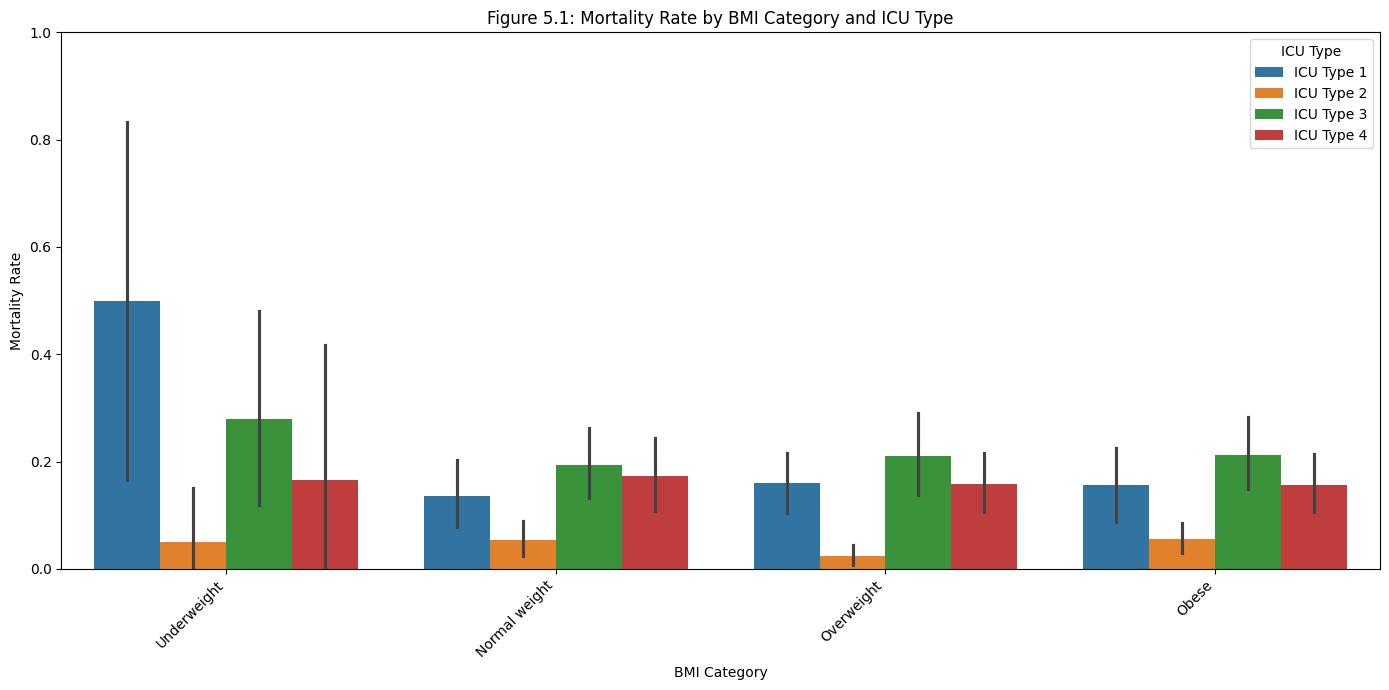

In [65]:
# Melt the DataFrame to easily work with ICU types
df_melted_icu = df_height_cleaned.melt(
    id_vars=['BMI_Category', 'In.hospital_death'],
    value_vars=['ICU_Type2', 'ICU_Type3', 'ICU_Type4'],
    var_name='ICU_Type_Encoded',
    value_name='Is_ICU_Type'
).copy()

# Filter for rows where the patient is in that ICU type and drop NaN BMI Categories
df_melted_icu = df_melted_icu[df_melted_icu['Is_ICU_Type'] == 1].dropna(subset=['BMI_Category'])

# Map the encoded ICU type back to descriptive names for clarity in the plot
icu_type_map = {
    'ICU_Type2': 'ICU Type 2',
    'ICU_Type3': 'ICU Type 3',
    'ICU_Type4': 'ICU Type 4'
}
df_melted_icu['ICU_Type'] = df_melted_icu['ICU_Type_Encoded'].map(icu_type_map)

# Handle ICU Type 1 (where ICU_Type2, ICU_Type3, ICU_Type4 are all 0)
df_height_cleaned_icu1 = df_height_cleaned[
    (df_height_cleaned['ICU_Type2'] == 0) &
    (df_height_cleaned['ICU_Type3'] == 0) &
    (df_height_cleaned['ICU_Type4'] == 0)
].copy()

df_height_cleaned_icu1['ICU_Type'] = 'ICU Type 1'
df_height_cleaned_icu1 = df_height_cleaned_icu1.dropna(
    subset=['BMI_Category']
)[['BMI_Category', 'ICU_Type', 'In.hospital_death']]

# Combine the dataframes
df_combined_icu_bmi = pd.concat([
    df_melted_icu[['BMI_Category', 'ICU_Type', 'In.hospital_death']],
    df_height_cleaned_icu1
])

icu_order = ['ICU Type 1', 'ICU Type 2', 'ICU Type 3', 'ICU Type 4']

# Plot
plt.figure(figsize=(14, 7))
sns.barplot(
    data=df_combined_icu_bmi,
    x='BMI_Category',
    y='In.hospital_death',
    hue='ICU_Type',
    hue_order=icu_order,   # ensures sorting by ICU type
    errorbar=('ci', 95)
)
plt.title('Figure 5.1: Mortality Rate by BMI Category and ICU Type')
plt.xlabel('BMI Category')
plt.ylabel('Mortality Rate')
plt.ylim(0, df_combined_icu_bmi['In.hospital_death'].max())
plt.xticks(rotation=45, ha='right')
plt.legend(title='ICU Type')
plt.tight_layout()
plt.show()


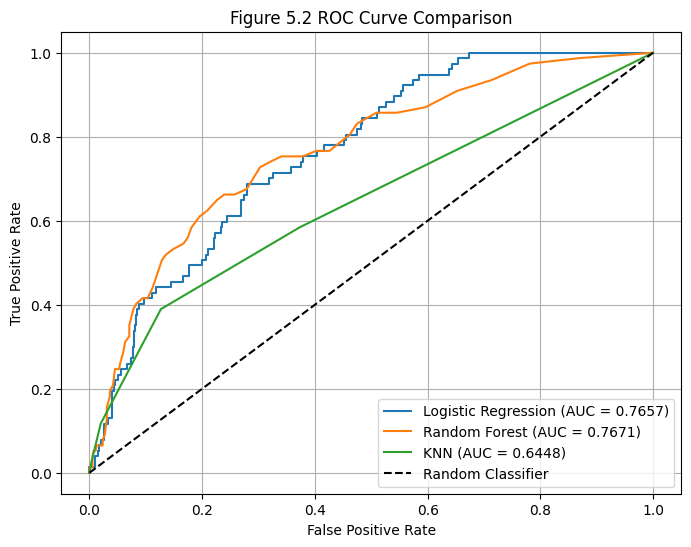

=== Logistic Regression ===
[[547   5]
 [ 74   3]]
              precision    recall  f1-score   support

           0       0.88      0.99      0.93       552
           1       0.38      0.04      0.07        77

    accuracy                           0.87       629
   macro avg       0.63      0.51      0.50       629
weighted avg       0.82      0.87      0.83       629

ROC AUC Score: 0.7657

=== Random Forest ===
[[545   7]
 [ 72   5]]
              precision    recall  f1-score   support

           0       0.88      0.99      0.93       552
           1       0.42      0.06      0.11        77

    accuracy                           0.87       629
   macro avg       0.65      0.53      0.52       629
weighted avg       0.83      0.87      0.83       629

ROC AUC Score: 0.7671

=== K-Nearest Neighbors ===
[[541  11]
 [ 68   9]]
              precision    recall  f1-score   support

           0       0.89      0.98      0.93       552
           1       0.45      0.12      0.19 

In [66]:
# Drop rows with missing values from df5
df5_clean = df5.dropna()

# Define features (X) and target (y)
X = df5_clean.drop(columns=['In.hospital_death'])
y = df5_clean['In.hospital_death']

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

# Scale the data (only for models that need it)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Logistic Regression
logreg = LogisticRegression(max_iter=1000, random_state=42)
logreg.fit(X_train_scaled, y_train)
y_logreg_pred = logreg.predict(X_test_scaled)
logreg_auc = roc_auc_score(y_test, logreg.predict_proba(X_test_scaled)[:, 1])

# Random Forest
rf = RandomForestClassifier(random_state=42)
rf.fit(X_train, y_train)
y_rf_pred = rf.predict(X_test)
rf_auc = roc_auc_score(y_test, rf.predict_proba(X_test)[:, 1])

# K-Nearest Neighbors
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train_scaled, y_train)
y_knn_pred = knn.predict(X_test_scaled)
knn_auc = roc_auc_score(y_test, knn.predict_proba(X_test_scaled)[:, 1])

# Plot ROC curves
fpr_logreg, tpr_logreg, _ = roc_curve(y_test, logreg.predict_proba(X_test_scaled)[:, 1])
fpr_rf, tpr_rf, _ = roc_curve(y_test, rf.predict_proba(X_test)[:, 1])
fpr_knn, tpr_knn, _ = roc_curve(y_test, knn.predict_proba(X_test_scaled)[:, 1])

plt.figure(figsize=(8, 6))
plt.plot(fpr_logreg, tpr_logreg, label=f'Logistic Regression (AUC = {logreg_auc:.4f})')
plt.plot(fpr_rf, tpr_rf, label=f'Random Forest (AUC = {rf_auc:.4f})')
plt.plot(fpr_knn, tpr_knn, label=f'KNN (AUC = {knn_auc:.4f})')
plt.plot([0, 1], [0, 1], 'k--', label='Random Classifier')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Figure 5.2 ROC Curve Comparison')
plt.legend()
plt.grid(True)
plt.show()

# Results
print("=== Logistic Regression ===")
print(confusion_matrix(y_test, y_logreg_pred))
print(classification_report(y_test, y_logreg_pred))
print(f"ROC AUC Score: {logreg_auc:.4f}")

print("\n=== Random Forest ===")
print(confusion_matrix(y_test, y_rf_pred))
print(classification_report(y_test, y_rf_pred))
print(f"ROC AUC Score: {rf_auc:.4f}")

print("\n=== K-Nearest Neighbors ===")
print(confusion_matrix(y_test, y_knn_pred))
print(classification_report(y_test, y_knn_pred))
print(f"ROC AUC Score: {knn_auc:.4f}")

### Tune Threshold to Optimise for Positive Recall & Precision

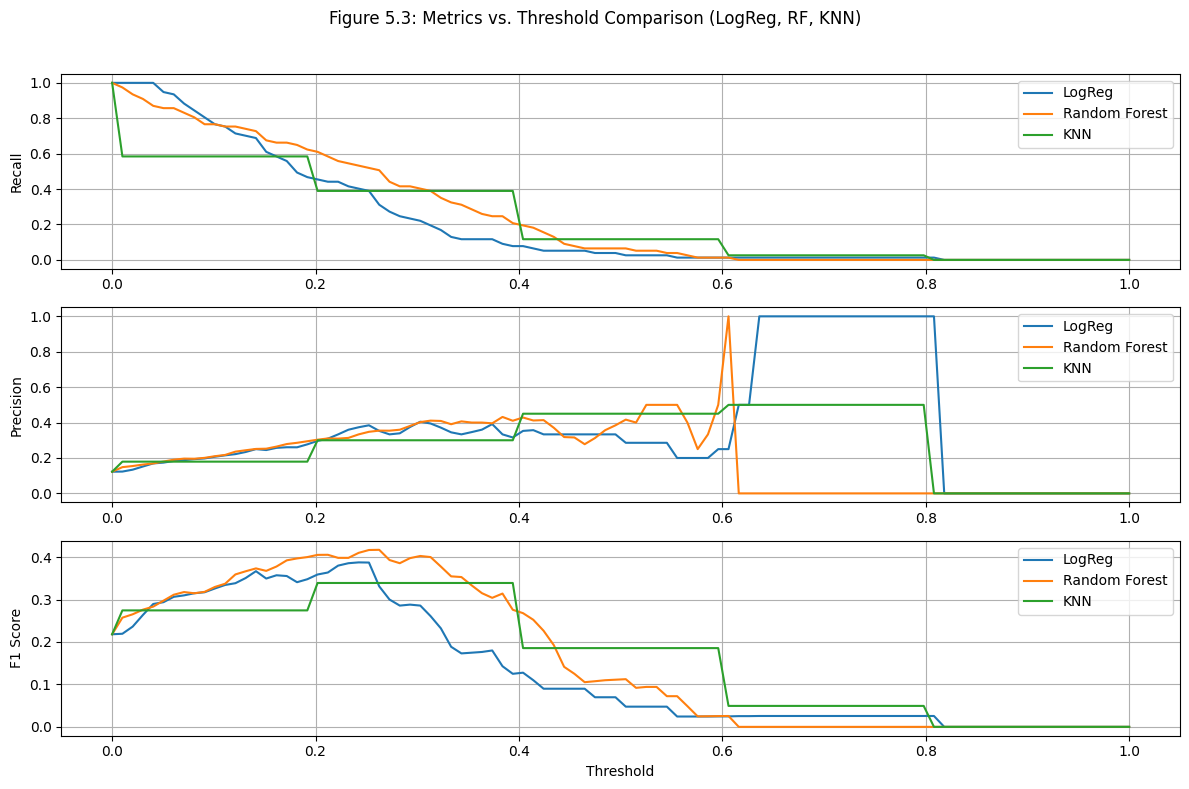

=== Best Thresholds (by F1) ===
Logistic Regression: thr=0.24, F1=0.3875, Recall=0.4026, Precision=0.3735
Random Forest:       thr=0.26, F1=0.4171, Recall=0.5065, Precision=0.3545
KNN:                 thr=0.20, F1=0.3390, Recall=0.3896, Precision=0.3000


In [67]:
# Get probability outputs
y_logreg_proba = logreg.predict_proba(X_test_scaled)[:, 1]
y_rf_proba = rf.predict_proba(X_test)[:, 1]
y_knn_proba = knn.predict_proba(X_test_scaled)[:, 1]

# Define thresholds
thresholds = np.linspace(0, 1, 100)

# Compute metrics
def compute_metrics(y_true, y_proba, thresholds):
    recalls, precisions, f1s = [], [], []
    for t in thresholds:
        preds = (y_proba >= t).astype(int)
        recalls.append(recall_score(y_true, preds))
        precisions.append(precision_score(y_true, preds, zero_division=0))
        f1s.append(f1_score(y_true, preds, zero_division=0))
    return recalls, precisions, f1s

# Collect metrics for each model
recalls_logreg, precisions_logreg, f1s_logreg = compute_metrics(y_test, y_logreg_proba, thresholds)
recalls_rf, precisions_rf, f1s_rf = compute_metrics(y_test, y_rf_proba, thresholds)
recalls_knn, precisions_knn, f1s_knn = compute_metrics(y_test, y_knn_proba, thresholds)

# Plot Recall, Precision, F1 vs. Threshold (side-by-side for models)
plt.figure(figsize=(12, 8))

# Recall
plt.subplot(3, 1, 1)
plt.plot(thresholds, recalls_logreg, label="LogReg")
plt.plot(thresholds, recalls_rf, label="Random Forest")
plt.plot(thresholds, recalls_knn, label="KNN")
plt.ylabel("Recall")
plt.legend()
plt.grid(True)

# Precision
plt.subplot(3, 1, 2)
plt.plot(thresholds, precisions_logreg, label="LogReg")
plt.plot(thresholds, precisions_rf, label="Random Forest")
plt.plot(thresholds, precisions_knn, label="KNN")
plt.ylabel("Precision")
plt.legend()
plt.grid(True)

# F1 Score
plt.subplot(3, 1, 3)
plt.plot(thresholds, f1s_logreg, label="LogReg")
plt.plot(thresholds, f1s_rf, label="Random Forest")
plt.plot(thresholds, f1s_knn, label="KNN")
plt.xlabel("Threshold")
plt.ylabel("F1 Score")
plt.legend()
plt.grid(True)

plt.suptitle("Figure 5.3: Metrics vs. Threshold Comparison (LogReg, RF, KNN)")
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

# Print best F1 threshold for each model
print("=== Best Thresholds (by F1) ===")
print(f"Logistic Regression: thr={thresholds[np.argmax(f1s_logreg)]:.2f}, "
      f"F1={max(f1s_logreg):.4f}, Recall={recalls_logreg[np.argmax(f1s_logreg)]:.4f}, "
      f"Precision={precisions_logreg[np.argmax(f1s_logreg)]:.4f}")

print(f"Random Forest:       thr={thresholds[np.argmax(f1s_rf)]:.2f}, "
      f"F1={max(f1s_rf):.4f}, Recall={recalls_rf[np.argmax(f1s_rf)]:.4f}, "
      f"Precision={precisions_rf[np.argmax(f1s_rf)]:.4f}")

print(f"KNN:                 thr={thresholds[np.argmax(f1s_knn)]:.2f}, "
      f"F1={max(f1s_knn):.4f}, Recall={recalls_knn[np.argmax(f1s_knn)]:.4f}, "
      f"Precision={precisions_knn[np.argmax(f1s_knn)]:.4f}")


In [68]:
# === Optimal thresholds from F1 analysis ===
thr_logreg = 0.24
thr_rf = 0.26
thr_knn = 0.20

# Apply thresholds
y_logreg_opt = (y_logreg_proba >= thr_logreg).astype(int)
y_rf_opt = (y_rf_proba >= thr_rf).astype(int)
y_knn_opt = (y_knn_proba >= thr_knn).astype(int)

# Evaluate again
print("=== Logistic Regression (Optimal Threshold) ===")
print(confusion_matrix(y_test, y_logreg_opt))
print(classification_report(y_test, y_logreg_opt, digits=2))

print("\n=== Random Forest (Optimal Threshold) ===")
print(confusion_matrix(y_test, y_rf_opt))
print(classification_report(y_test, y_rf_opt, digits=2))

print("\n=== KNN (Optimal Threshold) ===")
print(confusion_matrix(y_test, y_knn_opt))
print(classification_report(y_test, y_knn_opt, digits=2))



=== Logistic Regression (Optimal Threshold) ===
[[499  53]
 [ 46  31]]
              precision    recall  f1-score   support

           0       0.92      0.90      0.91       552
           1       0.37      0.40      0.39        77

    accuracy                           0.84       629
   macro avg       0.64      0.65      0.65       629
weighted avg       0.85      0.84      0.85       629


=== Random Forest (Optimal Threshold) ===
[[477  75]
 [ 37  40]]
              precision    recall  f1-score   support

           0       0.93      0.86      0.89       552
           1       0.35      0.52      0.42        77

    accuracy                           0.82       629
   macro avg       0.64      0.69      0.66       629
weighted avg       0.86      0.82      0.84       629


=== KNN (Optimal Threshold) ===
[[346 206]
 [ 32  45]]
              precision    recall  f1-score   support

           0       0.92      0.63      0.74       552
           1       0.18      0.58      0.27 

### Applying Class Weights & SMOTE

Computed Class Weights: {np.int64(0): np.float64(0.5700389105058365), np.int64(1): np.float64(4.069444444444445)}

=== Best Thresholds After Reweighting ===
Logistic Regression: thr=0.68, F1=0.3934, Recall=0.4675, Precision=0.3396
Random Forest:       thr=0.17, F1=0.4083, Recall=0.6364, Precision=0.3006
KNN (SMOTE):         thr=0.79, F1=0.3392, Recall=0.3766, Precision=0.3085

=== Logistic Regression (Weighted, Optimal Threshold) ===
[[482  70]
 [ 41  36]]
              precision    recall  f1-score   support

           0       0.92      0.87      0.90       552
           1       0.34      0.47      0.39        77

    accuracy                           0.82       629
   macro avg       0.63      0.67      0.65       629
weighted avg       0.85      0.82      0.84       629

ROC AUC Score: 0.7612

=== Random Forest (Weighted, Optimal Threshold) ===
[[438 114]
 [ 28  49]]
              precision    recall  f1-score   support

           0       0.94      0.79      0.86       552
     

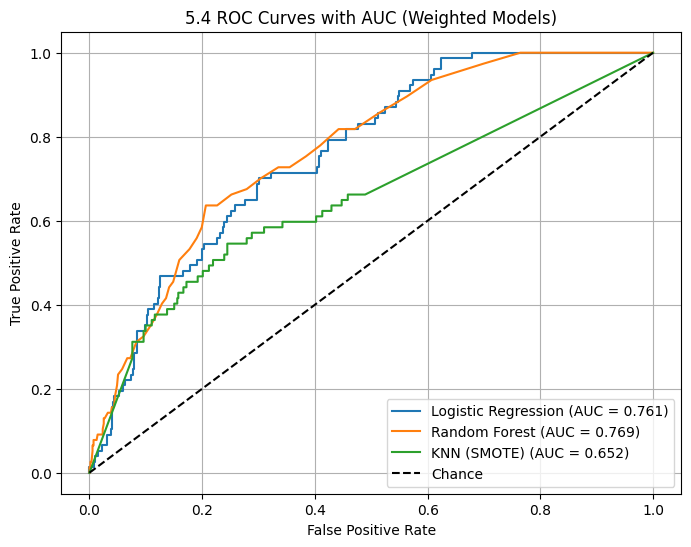

In [69]:
# === Compute Class Weights ===
classes = np.unique(y_train)
class_weights = compute_class_weight(class_weight='balanced', classes=classes, y=y_train)
weight_dict = {cls: w for cls, w in zip(classes, class_weights)}
print("Computed Class Weights:", weight_dict)

# === Logistic Regression with Class Weights ===
logreg_weighted = LogisticRegression(class_weight=weight_dict, max_iter=1000)
logreg_weighted.fit(X_train_scaled, y_train)
y_logreg_w_proba = logreg_weighted.predict_proba(X_test_scaled)[:, 1]

# === Random Forest with Class Weights ===
rf_weighted = RandomForestClassifier(class_weight='balanced', random_state=42)
rf_weighted.fit(X_train, y_train)
y_rf_w_proba = rf_weighted.predict_proba(X_test)[:, 1]

# === KNN with SMOTE Oversampling + Distance Weighting ===
smote = SMOTE(random_state=42)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train_scaled, y_train)

knn_resampled = KNeighborsClassifier(n_neighbors=5, weights='distance')
knn_resampled.fit(X_train_resampled, y_train_resampled)
y_knn_w_proba = knn_resampled.predict_proba(X_test_scaled)[:, 1]

# === Recompute Optimal Thresholds After Reweighting ===
thresholds = np.linspace(0, 1, 100)

recalls_logreg_w, precisions_logreg_w, f1s_logreg_w = compute_metrics(y_test, y_logreg_w_proba, thresholds)
recalls_rf_w, precisions_rf_w, f1s_rf_w = compute_metrics(y_test, y_rf_w_proba, thresholds)
recalls_knn_w, precisions_knn_w, f1s_knn_w = compute_metrics(y_test, y_knn_w_proba, thresholds)

thr_logreg_w = thresholds[np.argmax(f1s_logreg_w)]
thr_rf_w = thresholds[np.argmax(f1s_rf_w)]
thr_knn_w = thresholds[np.argmax(f1s_knn_w)]

print("\n=== Best Thresholds After Reweighting ===")
print(f"Logistic Regression: thr={thr_logreg_w:.2f}, "
      f"F1={max(f1s_logreg_w):.4f}, Recall={recalls_logreg_w[np.argmax(f1s_logreg_w)]:.4f}, "
      f"Precision={precisions_logreg_w[np.argmax(f1s_logreg_w)]:.4f}")

print(f"Random Forest:       thr={thr_rf_w:.2f}, "
      f"F1={max(f1s_rf_w):.4f}, Recall={recalls_rf_w[np.argmax(f1s_rf_w)]:.4f}, "
      f"Precision={precisions_rf_w[np.argmax(f1s_rf_w)]:.4f}")

print(f"KNN (SMOTE):         thr={thr_knn_w:.2f}, "
      f"F1={max(f1s_knn_w):.4f}, Recall={recalls_knn_w[np.argmax(f1s_knn_w)]:.4f}, "
      f"Precision={precisions_knn_w[np.argmax(f1s_knn_w)]:.4f}")

# === Apply New Optimal Thresholds and Evaluate Again ===
y_logreg_w_opt = (y_logreg_w_proba >= thr_logreg_w).astype(int)
y_rf_w_opt = (y_rf_w_proba >= thr_rf_w).astype(int)
y_knn_w_opt = (y_knn_w_proba >= thr_knn_w).astype(int)

print("\n=== Logistic Regression (Weighted, Optimal Threshold) ===")
print(confusion_matrix(y_test, y_logreg_w_opt))
print(classification_report(y_test, y_logreg_w_opt, digits=2))
print(f"ROC AUC Score: {roc_auc_score(y_test, y_logreg_w_proba):.4f}")

print("\n=== Random Forest (Weighted, Optimal Threshold) ===")
print(confusion_matrix(y_test, y_rf_w_opt))
print(classification_report(y_test, y_rf_w_opt, digits=2))
print(f"ROC AUC Score: {roc_auc_score(y_test, y_rf_w_proba):.4f}")

print("\n=== KNN (SMOTE + Distance Weights, Optimal Threshold) ===")
print(confusion_matrix(y_test, y_knn_w_opt))
print(classification_report(y_test, y_knn_w_opt, digits=2))
print(f"ROC AUC Score: {roc_auc_score(y_test, y_knn_w_proba):.4f}")

# === Compute ROC curves and AUC ===
fpr_logreg, tpr_logreg, _ = roc_curve(y_test, y_logreg_w_proba)
fpr_rf, tpr_rf, _ = roc_curve(y_test, y_rf_w_proba)
fpr_knn, tpr_knn, _ = roc_curve(y_test, y_knn_w_proba)

auc_logreg = roc_auc_score(y_test, y_logreg_w_proba)
auc_rf = roc_auc_score(y_test, y_rf_w_proba)
auc_knn = roc_auc_score(y_test, y_knn_w_proba)

# === Plot ROC curves ===
plt.figure(figsize=(8,6))
plt.plot(fpr_logreg, tpr_logreg, label=f"Logistic Regression (AUC = {auc_logreg:.3f})")
plt.plot(fpr_rf, tpr_rf, label=f"Random Forest (AUC = {auc_rf:.3f})")
plt.plot(fpr_knn, tpr_knn, label=f"KNN (SMOTE) (AUC = {auc_knn:.3f})")

# Diagonal baseline
plt.plot([0, 1], [0, 1], 'k--', label="Chance")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("5.4 ROC Curves with AUC (Weighted Models)")
plt.legend(loc="lower right")
plt.grid(True)
plt.show()


##Comments
###Data Exploratory (2-7 observered from others' sections)
1. General data for all types of ICU patients are mostly complete.

2. Mortality rates varied across ICU types: ICU Type 3 (Medical ICU) had the highest mortality at 18.57%, ICU Type 2 (Cardiac Surgery Recovery Unit) the lowest (4.92%), while Types 1 and 4 were in between (14.04% and 14.51%, respectively).

3. Glasgow Coma Scale (GCS) consistently emerged as a strong mortality predictor across all ICU types, indicating the broad importance of neurologic function regardless of ICU context.

4. SOFA score was significantly associated with mortality in both ICU Types 1 and 3, highlighting the role of overall organ dysfunction especially in cardiac and medical ICU settings.

5. Troponin and Bilirubin showed high correlation in Types 1 and 4, respectively, but were limited by missing data (Troponin and Bilirubin both had substantial data sparsity), reducing their utility as universal predictors.

6. Some variables like Lactate (Type 3) and ALP (Type 2) had high ICU-specific correlations, but did not show consistent predictive value across other units, supporting the idea of ICU-specific markers.

7. Overall, GCS stands out as the most complete and consistently predictive variable across ICU types, whereas others like Troponin, Bilirubin, and ALP appear to be context-dependent or limited by data availability.
---

###Data Visualisation: Figure 5.1 (Bar Chart)

1. **Observations**
  *   Underweight patients have the highest mortality rate in ICU Type 1 — around 50%, which is significantly higher than in other ICU types for the same BMI category.
  *   ICU Type 2 has low mortality rates across all BMI categories, with underweight mortality being the lowest among all ICU types.
  *   ICU Type 3 and 4 shows consistently higher mortality rates (~15–17%) across BMI categories, with little variation.
  *   ICU Type 4 maintains relatively stable mortality rates
  *   Normal weight, overweight, and obese categories show much lower mortality rates compared to underweight patients in all ICU types.

2. **Conclusions**
  *  Being underweight is associated with higher mortality, especially in ICU Type 1 and ICU Type 3 patients.
  *  ICU Type 2 outcomes appear the best overall, with low mortality regardless of BMI.
  *  Higher BMI (overweight or obese) does not necessarily correlate with higher mortality; in fact, mortality is relatively low in these categories for all ICU types.
  *  ICU Type 1 may require special nutritional or metabolic support interventions for underweight patients, given the drastic mortality spike.
  *  The relative stability in ICU Type 4 mortality suggests factors other than BMI may be more influential in this group.
---

###Predictive Models: Logistic Regression, Random Forest & KNN
```
=== Logistic Regression ===
[[547   5]
 [ 74   3]]
              precision    recall  f1-score   support

           0       0.88      0.99      0.93       552
           1       0.38      0.04      0.07        77

    accuracy                           0.87       629
   macro avg       0.63      0.51      0.50       629
weighted avg       0.82      0.87      0.83       629

ROC AUC Score: 0.7657

=== Random Forest ===
[[545   7]
 [ 72   5]]
              precision    recall  f1-score   support

           0       0.88      0.99      0.93       552
           1       0.42      0.06      0.11        77

    accuracy                           0.87       629
   macro avg       0.65      0.53      0.52       629
weighted avg       0.83      0.87      0.83       629

ROC AUC Score: 0.7671

=== K-Nearest Neighbors ===
[[541  11]
 [ 68   9]]
              precision    recall  f1-score   support

           0       0.89      0.98      0.93       552
           1       0.45      0.12      0.19        77

    accuracy                           0.87       629
   macro avg       0.67      0.55      0.56       629
weighted avg       0.83      0.87      0.84       629

ROC AUC Score: 0.6448
```


---
1. Based on the confusion matrixes, accuracy is high (87%) for all three models. However, the strong class imbalance (majority survivors) lowers recall and F1-score for predicting death cases.

2. **True Negative Rate (class 0 recall)** is ~98% → very reliable for predicting survival.  

3. **True Positive Rate (class 1 recall)** is low for all models (4-12%)

4. Precision for death cases varies:

  - KNN achieves the highest precision (0.45), meaning fewer false alarms, but at the cost of missing many deaths.

  - Logistic Regression and Random Forest have lower precision (0.42 and 0.38) but similar overall ranking ability.

5. As observed from the ROC Curve, ROC AUC (ability to rank cases correctly):

  - Random Forest: 0.7671 (best)

  - Logistic Regression: 0.7657

  - KNN: 0.6448 (lowest)
  
6. In this setting, improving recall for death cases is more critical than maximizing accuracy, because false negatives (missed deaths) carry high clinical risk. False Negative (FN) → Predict survival, but patient dies.
In medicine, this is very costly because you might miss a chance for intervention.

7. Although the model’s accuracy is lower than that of ICU-specific models, it can still be used for general prediction to help manage hospital ICU traffic.

---
###Tuning Threshold

```
=== Logistic Regression (Optimal Threshold) ===
[[499  53]
 [ 46  31]]
              precision    recall  f1-score   support

           0       0.92      0.90      0.91       552
           1       0.37      0.40      0.39        77

    accuracy                           0.84       629
   macro avg       0.64      0.65      0.65       629
weighted avg       0.85      0.84      0.85       629


=== Random Forest (Optimal Threshold) ===
[[477  75]
 [ 37  40]]
              precision    recall  f1-score   support

           0       0.93      0.86      0.89       552
           1       0.35      0.52      0.42        77

    accuracy                           0.82       629
   macro avg       0.64      0.69      0.66       629
weighted avg       0.86      0.82      0.84       629


=== KNN (Optimal Threshold) ===
[[346 206]
 [ 32  45]]
              precision    recall  f1-score   support

           0       0.92      0.63      0.74       552
           1       0.18      0.58      0.27        77

    accuracy                           0.62       629
   macro avg       0.55      0.61      0.51       629
weighted avg       0.83      0.62      0.69       629
```

1. **Recall improved** (LogReg: 0.04 → 0.40, RF: 0.06 → 0.52, KNN: 0.12 → 0.58).

2. **Precision dropped** (LogReg: 0.38 → 0.37, RF: 0.42 → 0.35, KNN: 0.45 → 0.18).

3. **F1-scores improved**, showing better balance for positives.

4. ROC AUC unchanged (threshold tuning shifts operating point, not discrimination).

5. Random Forest (thr ≈ 0.26) gave the best trade-off. By lowering the threshold (from default 0.50), more cases are predicted as class 1, therefore more deaths can be accurately predicted.
---

### Observations on Class Weights & SMOTE

```
=== Logistic Regression (Weighted, Optimal Threshold) ===
[[482  70]
 [ 41  36]]
              precision    recall  f1-score   support

           0       0.92      0.87      0.90       552
           1       0.34      0.47      0.39        77

    accuracy                           0.82       629
   macro avg       0.63      0.67      0.65       629
weighted avg       0.85      0.82      0.84       629

ROC AUC Score: 0.7612

=== Random Forest (Weighted, Optimal Threshold) ===
[[438 114]
 [ 28  49]]
              precision    recall  f1-score   support

           0       0.94      0.79      0.86       552
           1       0.30      0.64      0.41        77

    accuracy                           0.77       629
   macro avg       0.62      0.71      0.63       629
weighted avg       0.86      0.77      0.81       629

ROC AUC Score: 0.7692

=== KNN (SMOTE + Distance Weights, Optimal Threshold) ===
[[487  65]
 [ 48  29]]
              precision    recall  f1-score   support

           0       0.91      0.88      0.90       552
           1       0.31      0.38      0.34        77

    accuracy                           0.82       629
   macro avg       0.61      0.63      0.62       629
weighted avg       0.84      0.82      0.83       629

ROC AUC Score: 0.6524
```

- ROC-AUC Score remains almost the same. However, recall for minority class increased (LogReg 0.40 → 0.47, RF 0.52 → 0.64 ).
- **Precision slightly dropped off:** More false positives, but acceptable trade-off for higher sensitivity.
- **Model Comparison:**  
  - **RF (weighted):** Best balance with highest recall(0.64), lower precision(0.30).  
  - **LogReg (weighted)**:  Good recall(0.47), low precision as well(0.39).
  - **KNN (SMOTE):** Lowest recall(0.38), low precision as well(0.31).

**Takeaway:** Class weighting/SMOTE improves minority-class detection and overall F1, making models more suitable for clinical risk prediction.

---
###General / Industry Implications

1. **ICU Resource Allocation & Triage**  
   - A general predictive model, even if slightly less accurate than ICU-specific models, can support hospital-wide triage decisions.  
   - By identifying high-risk patients (e.g., underweight in ICU Type 1 or 3), hospitals can prioritize monitoring, allocate staff, or initiate early interventions without waiting for ICU-specific scoring.

2. **Targeted Nutritional & Metabolic Strategies**  
   - The clear mortality spike among underweight patients, especially in certain ICU types, highlights the importance of proactive nutritional support programs in critical care.  
   - Hospitals could standardize early nutrition screening upon admission to reduce risk in vulnerable BMI groups.

3. **Model Deployment for Operational Efficiency**  
   - Even with lower recall, a hospital-wide mortality prediction tool can help manage ICU traffic by highlighting likely survivors who might safely transfer to lower-acuity wards, freeing ICU beds for higher-risk patients.  
   - This aligns with broader industry moves toward **capacity optimization** in resource-limited critical care settings.

4. **Risk Communication & Policy Development**  
   - Insights into BMI-related mortality risks allow clearer patient/family communication about prognosis.  
   - At the system level, such predictive analytics can guide public health and hospital policy on ICU admission criteria, nutrition management, and escalation protocols.

5. **Precision Medicine Opportunities**  
   - The heterogeneity across ICU types suggests that **one-size-fits-all** models are suboptimal for certain subpopulations.  
   - Health systems could maintain both general prediction models for traffic management and ICU-specific models for in-depth decision support—an emerging standard in precision critical care.